# 📊 Analisis Pengaruh Diskon dan Berat Pengiriman terhadap Kuantitas Pembelian Konsumen E-Commerce Indonesia (2024–2025)

**Mata Kuliah:** Probabilitas dan Statistika
**Sumber data:** Kaggle – *Indonesia E-Commerce Sales and Shipping 2023–2025* (data sekunder, n = 500, 8 variabel)

| Variabel utama | Jenis | Skala | Satuan |
|---|---|---|---|
| `Nilai_Diskon_Rp` (X₁) | Kuantitatif kontinu | Rasio | Rupiah |
| `Berat_Pengiriman_Gram` (X₂) | Kuantitatif kontinu | Rasio | Gram |
| `Kuantitas_Pembelian_Pcs` (Y) | Kuantitatif diskrit | Rasio | Pcs |

**Rumusan masalah**
1. Bagaimana karakteristik statistika deskriptif (rata-rata, variansi, deviasi standar) dari nilai diskon, berat barang, dan kuantitas pembelian?
2. Bagaimana bentuk distribusi probabilitas dari kuantitas produk yang dibeli dalam satu transaksi?
3. Seberapa besar hubungan korelasi dan pengaruh nilai diskon serta berat barang terhadap kuantitas pembelian?


---
## TAHAP 0 — Persiapan Library dan Gaya Grafik
Sel ini memuat semua library, mengatur tampilan grafik agar seragam, dan membuat fungsi bantu untuk menyimpan gambar dengan penomoran otomatis (`Gambar_01_...png`, `Gambar_02_...png`, dst.).

In [ ]:
# ===== 0.1 Import library =====
import os, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 50)

# ===== 0.2 Gaya grafik yang konsisten =====
sns.set_theme(style="whitegrid", context="notebook")
WARNA = {"diskon": "#2E86AB", "berat": "#F18F01", "qty": "#C73E1D",
         "netral": "#5C6B73", "aksen": "#3B1F2B", "model": "#6A994E"}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "axes.labelsize": 10.5, "figure.titlesize": 14})

# ===== 0.3 Folder output & fungsi simpan gambar =====
FOLDER_OUT = "output_visualisasi"
os.makedirs(FOLDER_OUT, exist_ok=True)
_nomor = {"n": 0}
def simpan_gambar(fig, nama):
    _nomor["n"] += 1
    path = f"{FOLDER_OUT}/Gambar_{_nomor['n']:02d}_{nama}.png"
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"💾 Tersimpan: {path}")

TABEL_HASIL = {}          # semua tabel penting dikumpulkan di sini untuk diekspor ke Excel
ALPHA = 0.05              # taraf signifikansi untuk semua uji

def rupiah(v, pos=None):  # format sumbu: 15000 -> Rp15rb
    return f"Rp{v/1000:,.0f}rb"

print("✅ Library siap. Versi pandas:", pd.__version__, "| statsmodels:", sm.__version__)

✅ Library siap. Versi pandas: 2.2.3 | statsmodels: 0.15.0


---
## TAHAP 1 — Upload, Baca, dan Cek Kualitas Data
### Langkah 1.1 — Upload file Excel
Jalankan sel di bawah, klik **Choose Files**, lalu pilih file `3TIA_08_ECommerce_Indonesia_Kaggle_2024_2025.xlsx`.
(Jika file sudah ada di panel *Files* Colab, sel ini otomatis memakainya tanpa upload ulang.)

In [ ]:
NAMA_FILE = "3TIA_08_ECommerce_Indonesia_Kaggle_2024_2025.xlsx"

if not os.path.exists(NAMA_FILE):
    try:
        from google.colab import files
        hasil_upload = files.upload()
        NAMA_FILE = list(hasil_upload.keys())[0]
    except ImportError:
        raise FileNotFoundError("Letakkan file Excel di folder yang sama dengan notebook ini.")
print("📁 File yang dipakai:", NAMA_FILE)

Saving 3TIA_08_ECommerce_Indonesia_Kaggle_2024_2025.xlsx to 3TIA_08_ECommerce_Indonesia_Kaggle_2024_2025 (1).xlsx
📁 File yang dipakai: 3TIA_08_ECommerce_Indonesia_Kaggle_2024_2025 (1).xlsx


### Langkah 1.2 — Membaca sheet `Dataset_Bersih` dan `Kamus_Data`

In [ ]:
df = pd.read_excel(NAMA_FILE, sheet_name="Dataset_Bersih")
kamus = pd.read_excel(NAMA_FILE, sheet_name="Kamus_Data")

print(f"Ukuran data: {df.shape[0]} baris (sampel) × {df.shape[1]} kolom (variabel)\n")
display(kamus)
display(df.head(10))

Ukuran data: 500 baris (sampel) × 8 kolom (variabel)



,Nama Variabel,Deskripsi Variabel,Peran Variabel,Tipe Data,Jenis Data,Skala Pengukuran,Satuan / Format
0,ID_Transaksi,Kode unik identitas transaksi e-commerce,Identifikasi,Kualitatif,Diskrit,Nominal,TRX_2024000001 s.d TRX_2024000500
1,Tanggal_Transaksi,Tanggal terjadinya transaksi pembelian,Pendukung,Kualitatif,Diskrit,Ordinal,YYYY-MM-DD (2024 - 2025)
2,Provinsi_Tujuan,Provinsi lokasi pengiriman pesanan,Pendukung,Kualitatif,Diskrit,Nominal,"DKI Jakarta, Jawa Barat, Riau, dll."
3,Kategori_Produk,Kategori jenis barang yang dibeli,Pendukung,Kualitatif,Diskrit,Nominal,"Pakaian, Elektronik, Kecantikan, dll."
4,Berat_Pengiriman_Gram,Berat total barang yang dikirim dalam gram,Variabel Utama,Kuantitatif,Kontinu,Rasio,Gram (gr)
5,Nilai_Diskon_Rp,Besar potongan harga / diskon yang didapat,Variabel Utama,Kuantitatif,Kontinu,Rasio,Rupiah (Rp)
6,Kuantitas_Pembelian_Pcs,Jumlah unit produk yang dibeli konsumen,Variabel Utama,Kuantitatif,Diskrit,Rasio,Pieces (Pcs)
7,Total_Nilai_Belanja_Rp,Total nominal transaksi sebelum diskon,Variabel Pendukung,Kuantitatif,Kontinu,Rasio,Rupiah (Rp)


,ID_Transaksi,Tanggal_Transaksi,Provinsi_Tujuan,Kategori_Produk,Berat_Pengiriman_Gram,Nilai_Diskon_Rp,Kuantitas_Pembelian_Pcs,Total_Nilai_Belanja_Rp
0,TRX_2024001,2024-01-01,DKI Jakarta,Kecantikan & Perawatan,3097,15000,3,135000
1,TRX_2024002,2024-01-02,Sumatera Utara,Pakaian & Fashion,435,5000,2,300000
2,TRX_2024003,2024-01-03,Banten,Elektronik & Gadget,3225,35000,4,340000
3,TRX_2024004,2024-01-05,Jawa Barat,Elektronik & Gadget,436,10000,6,270000
4,TRX_2024005,2024-01-06,Jawa Barat,Kebutuhan Rumah Tangga,2560,20000,4,180000
5,TRX_2024006,2024-01-08,Jawa Barat,Pakaian & Fashion,2220,15000,4,340000
6,TRX_2024007,2024-01-09,Jawa Timur,Elektronik & Gadget,2135,25000,3,135000
7,TRX_2024008,2024-01-11,Jawa Tengah,Kecantikan & Perawatan,3785,5000,3,255000
8,TRX_2024009,2024-01-12,Banten,Kecantikan & Perawatan,2061,20000,3,1050000
9,TRX_2024010,2024-01-14,Riau,Elektronik & Gadget,3015,5000,1,85000


### Langkah 1.3 — Cek kualitas data dan menetapkan variabel analisis
Memastikan tidak ada data hilang/duplikat, tipe data benar, dan nilai variabel utama masuk akal (≥ 0 untuk skala rasio).

In [ ]:
df["Tanggal_Transaksi"] = pd.to_datetime(df["Tanggal_Transaksi"])

cek = pd.DataFrame({
    "Tipe Data": df.dtypes.astype(str),
    "Jumlah Missing": df.isna().sum(),
    "Jumlah Nilai Unik": df.nunique()
})
display(cek)
print("Jumlah baris duplikat :", df.duplicated().sum())
print("Rentang tanggal       :", df["Tanggal_Transaksi"].min().date(), "s.d.", df["Tanggal_Transaksi"].max().date())

# Variabel utama + label tampilan yang dipakai konsisten di seluruh notebook
X1, X2, Y = "Nilai_Diskon_Rp", "Berat_Pengiriman_Gram", "Kuantitas_Pembelian_Pcs"
VAR_UTAMA = [X1, X2, Y]
LABEL = {X1: "Nilai Diskon (Rp)", X2: "Berat Pengiriman (Gram)", Y: "Kuantitas Pembelian (Pcs)"}
WARNA_VAR = {X1: WARNA["diskon"], X2: WARNA["berat"], Y: WARNA["qty"]}

print("\nNilai negatif pada variabel utama:", int((df[VAR_UTAMA] < 0).sum().sum()), "→ skala rasio valid" )

,Tipe Data,Jumlah Missing,Jumlah Nilai Unik
ID_Transaksi,object,0,500
Tanggal_Transaksi,datetime64[ns],0,500
Provinsi_Tujuan,object,0,8
Kategori_Produk,object,0,5
Berat_Pengiriman_Gram,int64,0,464
Nilai_Diskon_Rp,int64,0,10
Kuantitas_Pembelian_Pcs,int64,0,10
Total_Nilai_Belanja_Rp,int64,0,47


Jumlah baris duplikat : 0
Rentang tanggal       : 2024-01-01 s.d. 2025-12-31

Nilai negatif pada variabel utama: 0 → skala rasio valid


---
## TAHAP 2 — Statistika Deskriptif (Menjawab Rumusan Masalah 1)
### Langkah 2.1 — Tabel ukuran pemusatan dan penyebaran
Rumus yang dipakai (sampel, n = 500):

- Rata-rata: $\bar{x} = \dfrac{\sum x_i}{n}$
- Variansi sampel: $s^2 = \dfrac{\sum (x_i-\bar{x})^2}{n-1}$
- Deviasi standar: $s = \sqrt{s^2}$
- Koefisien variasi: $CV = \dfrac{s}{\bar{x}} \times 100\%$ (untuk membandingkan sebaran antarvariabel yang satuannya berbeda)

In [ ]:
def statistik_deskriptif(data, kolom):
    baris = {}
    for k in kolom:
        x = data[k]
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        baris[LABEL[k]] = {
            "n": x.count(), "Rata-rata": x.mean(), "Median": x.median(), "Modus": x.mode().iloc[0],
            "Variansi (s²)": x.var(ddof=1), "Deviasi Standar (s)": x.std(ddof=1),
            "Minimum": x.min(), "Q1": q1, "Q3": q3, "Maksimum": x.max(),
            "Jangkauan": x.max() - x.min(), "IQR": q3 - q1,
            "Koef. Variasi (%)": x.std(ddof=1) / x.mean() * 100,
            "Skewness": x.skew(), "Kurtosis (excess)": x.kurt(),
            "Std. Error Mean": x.sem()}
    return pd.DataFrame(baris)

tabel_deskriptif = statistik_deskriptif(df, VAR_UTAMA)
TABEL_HASIL["Statistik_Deskriptif"] = tabel_deskriptif
display(tabel_deskriptif.style.format("{:,.2f}").set_caption("Tabel 1. Statistika Deskriptif Variabel Utama"))

,Nilai Diskon (Rp),Berat Pengiriman (Gram),Kuantitas Pembelian (Pcs)
n,500.00,500.00,500.00
Rata-rata,"26,510.00","2,318.45",3.53
Median,"20,000.00","2,312.50",3.00
Modus,"10,000.00",265.00,2.00
Variansi (s²),"638,847,595.19","1,558,698.63",2.73
Deviasi Standar (s),"25,275.43","1,248.48",1.65
Minimum,"5,000.00",218.00,1.00
Q1,"10,000.00","1,260.75",2.00
Q3,"35,000.00","3,370.00",4.00
Maksimum,"150,000.00","4,478.00",10.00


### Langkah 2.2 — Pembuktian rumus secara manual
Bagian ini menunjukkan bahwa hasil tabel di atas sama dengan perhitungan rumus langkah demi langkah (berguna untuk bab pembahasan laporan).

In [ ]:
for k in VAR_UTAMA:
    x = df[k].to_numpy(dtype=float); n = len(x)
    jumlah = x.sum(); rata = jumlah / n
    jk = ((x - rata) ** 2).sum()            # jumlah kuadrat simpangan
    var = jk / (n - 1); sd = np.sqrt(var)
    print(f"── {LABEL[k]} ──")
    print(f"   Σx = {jumlah:,.0f}  →  x̄ = Σx/n = {jumlah:,.0f}/{n} = {rata:,.4f}")
    print(f"   Σ(x−x̄)² = {jk:,.4f}  →  s² = {jk:,.4f}/{n-1} = {var:,.4f}")
    print(f"   s = √s² = {sd:,.4f}\n")

── Nilai Diskon (Rp) ──
   Σx = 13,255,000  →  x̄ = Σx/n = 13,255,000/500 = 26,510.0000
   Σ(x−x̄)² = 318,784,950,000.0000  →  s² = 318,784,950,000.0000/499 = 638,847,595.1904
   s = √s² = 25,275.4346

── Berat Pengiriman (Gram) ──
   Σx = 1,159,227  →  x̄ = Σx/n = 1,159,227/500 = 2,318.4540
   Σ(x−x̄)² = 777,790,615.9420  →  s² = 777,790,615.9420/499 = 1,558,698.6291
   s = √s² = 1,248.4785

── Kuantitas Pembelian (Pcs) ──
   Σx = 1,767  →  x̄ = Σx/n = 1,767/500 = 3.5340
   Σ(x−x̄)² = 1,362.4220  →  s² = 1,362.4220/499 = 2.7303
   s = √s² = 1.6524



### Langkah 2.3 — Visualisasi distribusi data (histogram + kurva kepadatan)
Garis **merah putus-putus** = rata-rata, garis **hitam** = median. Jika rata-rata > median, distribusi **menceng kanan** (positif).

💾 Tersimpan: output_visualisasi/Gambar_01_Histogram_Variabel_Utama.png


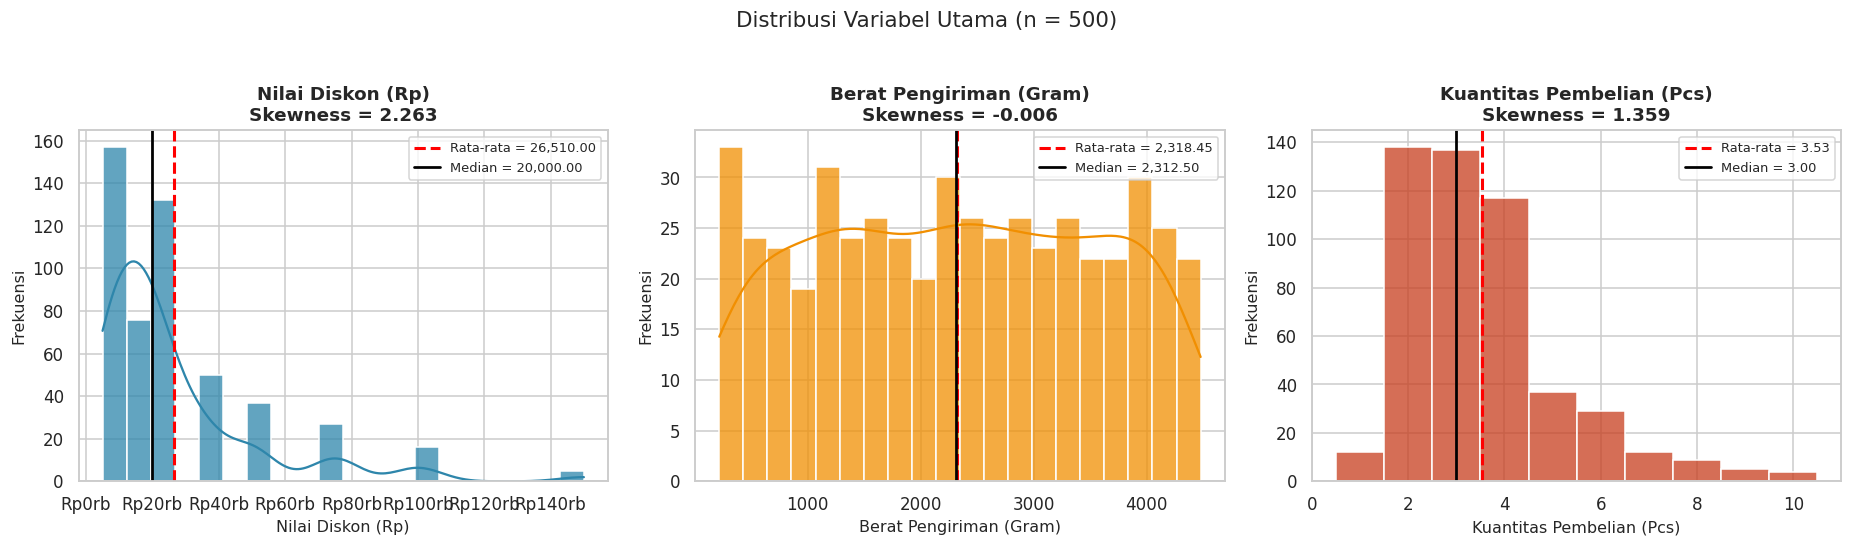

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, k in zip(axes, VAR_UTAMA):
    x = df[k]
    diskrit = k == Y
    sns.histplot(x, ax=ax, color=WARNA_VAR[k], kde=not diskrit, alpha=0.75,
                 discrete=diskrit, bins=None if diskrit else 20, edgecolor="white")
    ax.axvline(x.mean(), color="red", ls="--", lw=2, label=f"Rata-rata = {x.mean():,.2f}")
    ax.axvline(x.median(), color="black", ls="-", lw=1.8, label=f"Median = {x.median():,.2f}")
    ax.set_title(f"{LABEL[k]}\nSkewness = {x.skew():.3f}")
    ax.set_xlabel(LABEL[k]); ax.set_ylabel("Frekuensi"); ax.legend(fontsize=8.5)
    if k == X1: ax.xaxis.set_major_formatter(mtick.FuncFormatter(rupiah))
fig.suptitle("Distribusi Variabel Utama (n = 500)", y=1.03)
plt.tight_layout(); simpan_gambar(fig, "Histogram_Variabel_Utama"); plt.show()

### Langkah 2.4 — Boxplot dan deteksi outlier (metode IQR)
Pencilan = nilai di luar batas $[Q_1 - 1{,}5\,IQR,\; Q_3 + 1{,}5\,IQR]$. Pencilan **tidak dihapus** karena merupakan transaksi nyata (diskon besar / pembelian banyak), tetapi dicatat untuk pembahasan.

💾 Tersimpan: output_visualisasi/Gambar_02_Boxplot_Outlier.png


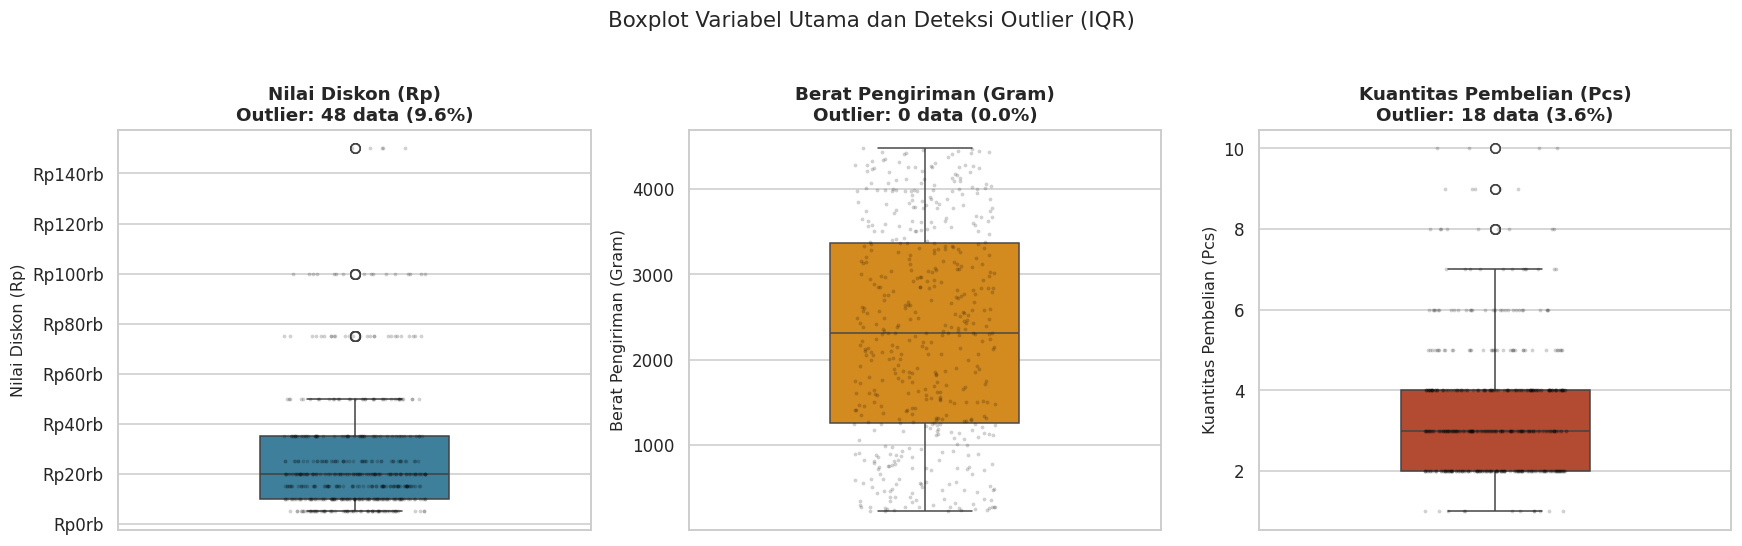

,Batas Bawah,Batas Atas,Jumlah OUtlier,Persentase (%)
Nilai Diskon (Rp),"-27,500.0000","72,500.0000",48.0000,9.6000
Berat Pengiriman (Gram),"-1,903.1250","6,533.8750",0.0000,0.0000
Kuantitas Pembelian (Pcs),-1.0000,7.0000,18.0000,3.6000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
ringkas_outlier = {}
for ax, k in zip(axes, VAR_UTAMA):
    x = df[k]; q1, q3 = x.quantile([.25, .75]); iqr = q3 - q1
    bb, ba = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((x < bb) | (x > ba)).sum())
    ringkas_outlier[LABEL[k]] = {"Batas Bawah": bb, "Batas Atas": ba, "Jumlah OUtlier": n_out,
                                  "Persentase (%)": n_out / len(x) * 100}
    sns.boxplot(y=x, ax=ax, color=WARNA_VAR[k], width=0.4, flierprops=dict(marker="o", markerfacecolor="white"))
    sns.stripplot(y=x, ax=ax, color="black", alpha=0.18, size=2.5, jitter=0.15)
    ax.set_title(f"{LABEL[k]}\nOutlier: {n_out} data ({n_out/len(x)*100:.1f}%)")
    ax.set_ylabel(LABEL[k])
    if k == X1: ax.yaxis.set_major_formatter(mtick.FuncFormatter(rupiah))
fig.suptitle("Boxplot Variabel Utama dan Deteksi Outlier (IQR)", y=1.03)
plt.tight_layout(); simpan_gambar(fig, "Boxplot_Outlier"); plt.show()

tabel_outlier = pd.DataFrame(ringkas_outlier).T
TABEL_HASIL["Deteksi_Outlier"] = tabel_outlier
display(tabel_outlier)

### Langkah 2.5 — Perbandingan rata-rata ± deviasi standar dan koefisien variasi
Karena satuan ketiga variabel berbeda (Rp, gram, pcs), keragaman dibandingkan memakai **koefisien variasi (CV)**: semakin besar CV, semakin heterogen datanya.

💾 Tersimpan: output_visualisasi/Gambar_03_Rata_SD_Koefisien_Variasi.png


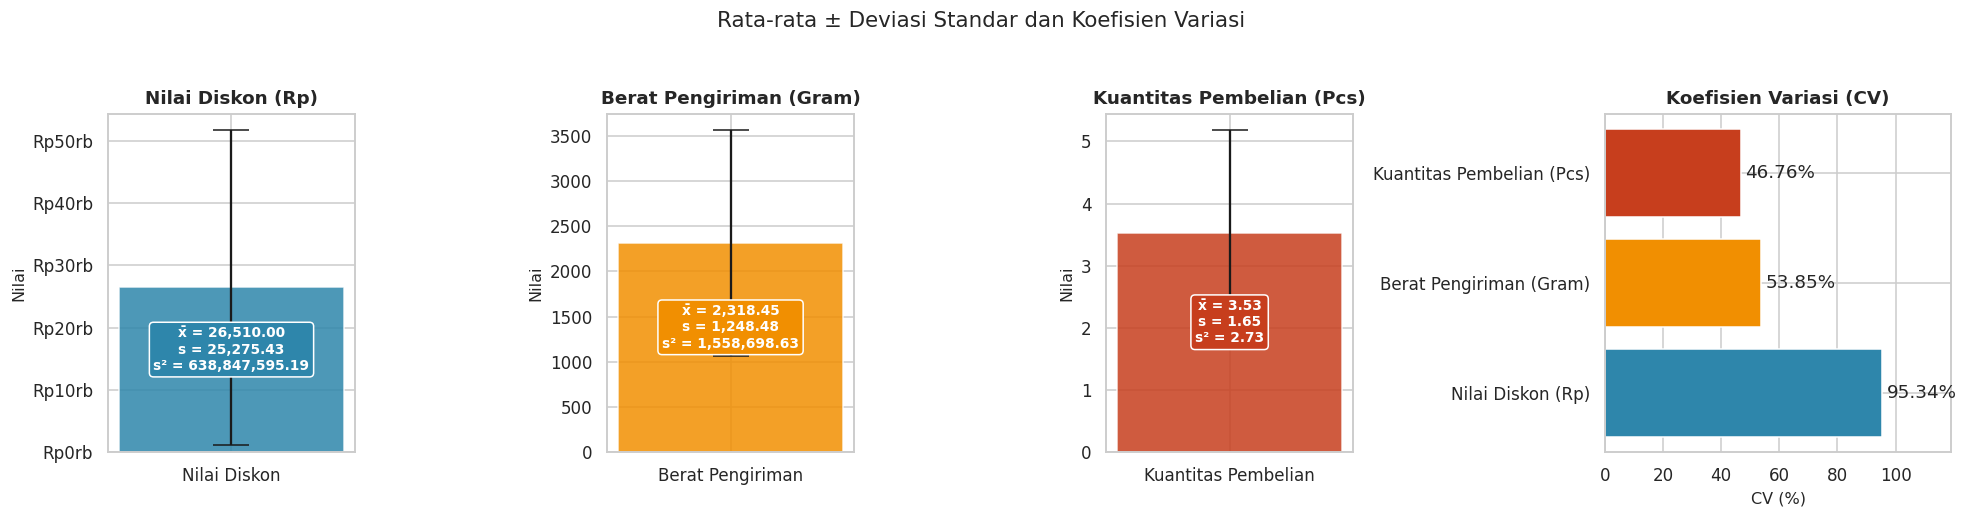

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), gridspec_kw={"width_ratios": [1, 1, 1, 1.4]})
for ax, k in zip(axes[:3], VAR_UTAMA):
    m, s = df[k].mean(), df[k].std()
    ax.bar([LABEL[k].split(" (")[0]], [m], yerr=[s], color=WARNA_VAR[k], capsize=12, width=0.5, alpha=0.85)
    ax.text(0, m / 2, f"x̄ = {m:,.2f}\ns = {s:,.2f}\ns² = {s**2:,.2f}", ha="center", color="white",
            fontweight="bold", fontsize=9, zorder=5,
            bbox=dict(boxstyle="round", fc=WARNA_VAR[k], ec="white"))
    ax.set_title(LABEL[k]); ax.set_ylabel("Nilai")
    if k == X1: ax.yaxis.set_major_formatter(mtick.FuncFormatter(rupiah))
cv = tabel_deskriptif.loc["Koef. Variasi (%)"]
bars = axes[3].barh(cv.index, cv.values, color=[WARNA_VAR[k] for k in VAR_UTAMA])
axes[3].bar_label(bars, fmt="%.2f%%", padding=3)
axes[3].set_title("Koefisien Variasi (CV)"); axes[3].set_xlabel("CV (%)")
axes[3].set_xlim(0, cv.max() * 1.25)
fig.suptitle("Rata-rata ± Deviasi Standar dan Koefisien Variasi", y=1.04)
plt.tight_layout(); simpan_gambar(fig, "Rata_SD_Koefisien_Variasi"); plt.show()

---
## TAHAP 3 — Distribusi Probabilitas Kuantitas Pembelian (Menjawab Rumusan Masalah 2)
### Langkah 3.1 — Tabel distribusi frekuensi dan probabilitas empiris
Untuk variabel diskrit, fungsi massa peluang empiris adalah $P(X=k) = \dfrac{f_k}{n}$ dan fungsi distribusi kumulatif $F(k) = P(X \le k)$.

In [ ]:
q = df[Y].to_numpy()
n = len(q)
nilai_k = np.arange(q.min(), q.max() + 1)
frek = np.array([(q == k).sum() for k in nilai_k])

tabel_frek = pd.DataFrame({
    "Kuantitas (k)": nilai_k, "Frekuensi (f)": frek,
    "P(X=k)": frek / n, "Persentase (%)": frek / n * 100,
    "Frek. Kumulatif": frek.cumsum(), "F(k)=P(X≤k)": frek.cumsum() / n})
TABEL_HASIL["Distribusi_Frekuensi_Qty"] = tabel_frek
display(tabel_frek.style.format({"P(X=k)": "{:.4f}", "Persentase (%)": "{:.2f}", "F(k)=P(X≤k)": "{:.4f}"})
        .hide(axis="index").set_caption("Tabel 2. Distribusi Frekuensi Kuantitas Pembelian"))

E_X = (nilai_k * frek / n).sum()
Var_X = ((nilai_k - E_X) ** 2 * frek / n).sum()
print(f"Nilai harapan  E(X)   = Σ k·P(X=k)         = {E_X:.4f} pcs")
print(f"Variansi       Var(X) = Σ (k−μ)²·P(X=k)    = {Var_X:.4f}")
print(f"Indeks dispersi Var/Mean = {q.var(ddof=1)/q.mean():.4f} "
      f"({'< 1 → underdispersi' if q.var(ddof=1)/q.mean() < 1 else '> 1 → overdispersi'} relatif terhadap Poisson)")

Kuantitas (k),Frekuensi (f),P(X=k),Persentase (%),Frek. Kumulatif,F(k)=P(X≤k)
1,12,0.0240,2.40,12,0.0240
2,138,0.2760,27.60,150,0.3000
3,137,0.2740,27.40,287,0.5740
4,117,0.2340,23.40,404,0.8080
5,37,0.0740,7.40,441,0.8820
6,29,0.0580,5.80,470,0.9400
7,12,0.0240,2.40,482,0.9640
8,9,0.0180,1.80,491,0.9820
9,5,0.0100,1.00,496,0.9920
10,4,0.0080,0.80,500,1.0000


Nilai harapan  E(X)   = Σ k·P(X=k)         = 3.5340 pcs
Variansi       Var(X) = Σ (k−μ)²·P(X=k)    = 2.7248
Indeks dispersi Var/Mean = 0.7726 (< 1 → underdispersi relatif terhadap Poisson)


### Langkah 3.2 — Visualisasi PMF dan CDF empiris

💾 Tersimpan: output_visualisasi/Gambar_04_PMF_CDF_Empiris_Kuantitas.png


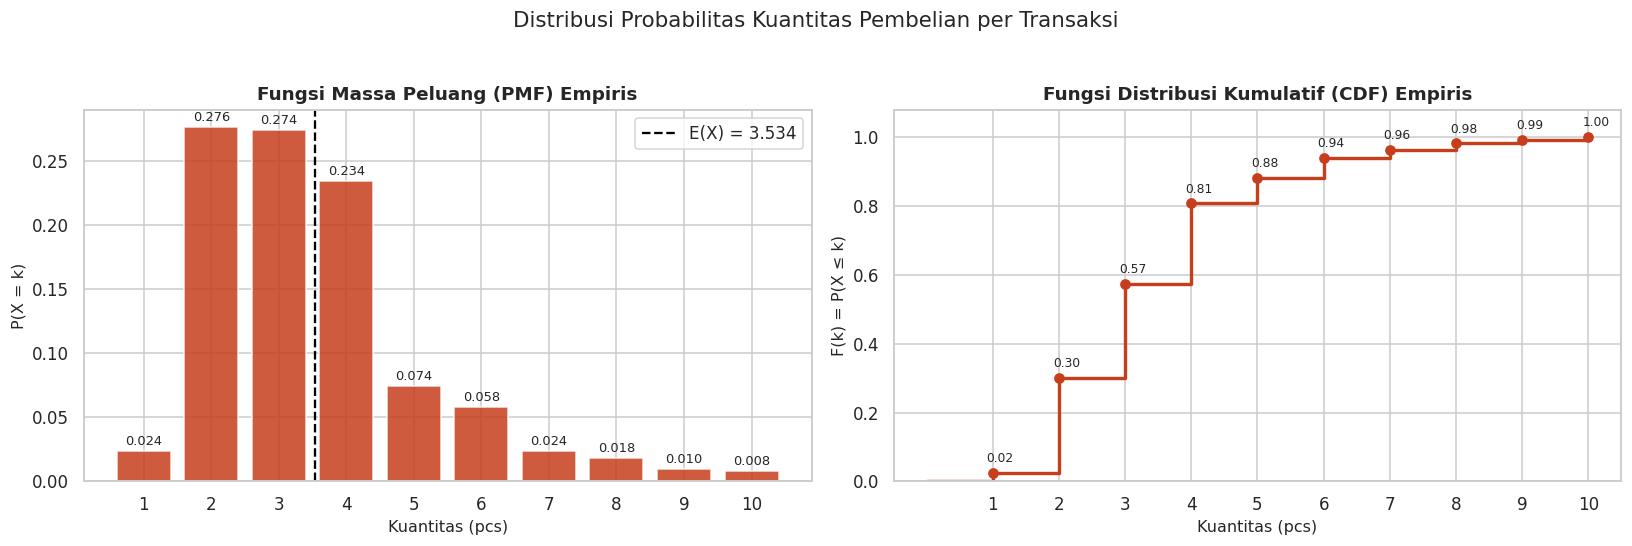

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
b = axes[0].bar(nilai_k, frek / n, color=WARNA["qty"], alpha=0.85, edgecolor="white")
axes[0].bar_label(b, labels=[f"{p:.3f}" for p in frek / n], fontsize=8.5, padding=2)
axes[0].axvline(q.mean(), color="black", ls="--", label=f"E(X) = {q.mean():.3f}")
axes[0].set_title("Fungsi Massa Peluang (PMF) Empiris"); axes[0].set_xlabel("Kuantitas (pcs)")
axes[0].set_ylabel("P(X = k)"); axes[0].set_xticks(nilai_k); axes[0].legend()

axes[1].step(np.r_[nilai_k[0] - 1, nilai_k], np.r_[0, frek.cumsum() / n], where="post", color=WARNA["qty"], lw=2.2)
axes[1].scatter(nilai_k, frek.cumsum() / n, color=WARNA["qty"], zorder=3)
for k_, F_ in zip(nilai_k, frek.cumsum() / n):
    axes[1].annotate(f"{F_:.2f}", (k_, F_), textcoords="offset points", xytext=(-4, 7), fontsize=8)
axes[1].set_title("Fungsi Distribusi Kumulatif (CDF) Empiris"); axes[1].set_xlabel("Kuantitas (pcs)")
axes[1].set_ylabel("F(k) = P(X ≤ k)"); axes[1].set_xticks(nilai_k); axes[1].set_ylim(0, 1.08)
fig.suptitle("Distribusi Probabilitas Kuantitas Pembelian per Transaksi", y=1.03)
plt.tight_layout(); simpan_gambar(fig, "PMF_CDF_Empiris_Kuantitas"); plt.show()

### Langkah 3.3 — Pencocokan (fitting) model distribusi diskrit
Kandidat model yang diuji (parameter ditaksir dari data):

| Model | Asumsi | Penaksir parameter |
|---|---|---|
| **Poisson** | Banyak kejadian per transaksi, mean = variansi | $\hat\lambda = \bar{x}$ |
| **Poisson Terpotong-Nol** (*Zero-Truncated*) | Seperti Poisson tetapi X ≥ 1 (tidak ada transaksi 0 pcs) | $\hat\lambda$ dari $\frac{\lambda}{1-e^{-\lambda}}=\bar{x}$ |
| **Poisson Tergeser** (*Shifted*, X−1 ~ Poisson) | Minimal 1 pcs + tambahan acak | $\hat\lambda = \bar{x}-1$ |
| **Binomial (n = 10)** | Maksimal 10 pcs per transaksi | $\hat p = \bar{x}/10$ |

Kecocokan diuji dengan **uji Chi-Square Goodness of Fit**:
$H_0$: data mengikuti distribusi model; $H_1$: data tidak mengikuti distribusi model.
$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$, $df = (\text{jumlah kelas}) - 1 - (\text{jumlah parameter})$. Kelas dengan frekuensi harapan < 5 digabung. Model juga dibandingkan dengan **AIC** (semakin kecil semakin baik).

In [ ]:
rata_q = q.mean()
lam_pois = rata_q
lam_ztp = brentq(lambda l: l / (1 - np.exp(-l)) - rata_q, 1e-6, 50)
lam_shift = rata_q - 1
p_binom = rata_q / 10

# PMF tiap model untuk k = 1..10 ; kelas pertama menampung P(X≤1), kelas terakhir P(X≥10)
def pmf_model(nama, k):
    if nama == "Poisson":            return stats.poisson.pmf(k, lam_pois)
    if nama == "Poisson Terpotong-Nol": return stats.poisson.pmf(k, lam_ztp) / (1 - np.exp(-lam_ztp))
    if nama == "Poisson Tergeser":   return stats.poisson.pmf(k - 1, lam_shift)
    if nama == "Binomial (n=10)":    return stats.binom.pmf(k, 10, p_binom)

def peluang_kelas(nama):
    p = pmf_model(nama, nilai_k).astype(float)
    if nama == "Poisson":          p[0] += stats.poisson.pmf(0, lam_pois)
    if nama == "Binomial (n=10)":  p[0] += stats.binom.pmf(0, 10, p_binom)
    p[-1] += 1 - p.sum()           # sisa peluang ekor kanan masuk kelas terakhir
    return p

def gabung_kelas(O, E, batas=5):
    O, E = list(O), list(E)
    while len(E) > 2 and E[0] < batas:  O[1] += O[0]; E[1] += E[0]; O.pop(0); E.pop(0)
    while len(E) > 2 and E[-1] < batas: O[-2] += O[-1]; E[-2] += E[-1]; O.pop(); E.pop()
    return np.array(O), np.array(E)

PARAM = {"Poisson": (1, f"λ = {lam_pois:.4f}"), "Poisson Terpotong-Nol": (1, f"λ = {lam_ztp:.4f}"),
         "Poisson Tergeser": (1, f"λ = {lam_shift:.4f}"), "Binomial (n=10)": (1, f"p = {p_binom:.4f}")}
MODEL = list(PARAM)

hasil_fit, harapan = [], {}
for nama in MODEL:
    p = peluang_kelas(nama); E = p * n; harapan[nama] = E
    O_g, E_g = gabung_kelas(frek, E)
    chi2 = ((O_g - E_g) ** 2 / E_g).sum()
    df_chi = len(O_g) - 1 - PARAM[nama][0]
    p_val = stats.chi2.sf(chi2, df_chi)
    loglik = np.log(np.clip(pmf_model(nama, q), 1e-300, None)).sum()
    hasil_fit.append({"Model": nama, "Parameter": PARAM[nama][1], "Jumlah Kelas": len(O_g),
                      "χ² hitung": chi2, "df": df_chi, "χ² tabel (α=0.05)": stats.chi2.ppf(1 - ALPHA, df_chi),
                      "p-value": p_val, "Log-Likelihood": loglik, "AIC": 2 * PARAM[nama][0] - 2 * loglik,
                      "Keputusan": "Terima H₀ (cocok)" if p_val > ALPHA else "Tolak H₀ (tidak cocok)"})

tabel_fit = pd.DataFrame(hasil_fit).sort_values("AIC").reset_index(drop=True)
TABEL_HASIL["Uji_Kecocokan_Distribusi"] = tabel_fit
MODEL_TERBAIK = tabel_fit.loc[0, "Model"]
display(tabel_fit.style.format({"χ² hitung": "{:.3f}", "χ² tabel (α=0.05)": "{:.3f}", "p-value": "{:.2e}",
                                "Log-Likelihood": "{:.2f}", "AIC": "{:.2f}"})
        .hide(axis="index").set_caption("Tabel 3. Uji Chi-Square Goodness of Fit (diurutkan berdasarkan AIC)"))
print(f"🏆 Model dengan AIC terkecil: {MODEL_TERBAIK}")

Model,Parameter,Jumlah Kelas,χ² hitung,df,χ² tabel (α=0.05),p-value,Log-Likelihood,AIC,Keputusan
Poisson Tergeser,λ = 2.5340,8,64.744,6,12.592,4.87e-12,-909.87,1821.75,Tolak H₀ (tidak cocok)
Poisson Terpotong-Nol,λ = 3.4182,8,80.885,6,12.592,2.34e-15,-923.66,1849.32,Tolak H₀ (tidak cocok)
Poisson,λ = 3.5340,9,103.932,7,14.067,1.66e-19,-939.35,1880.70,Tolak H₀ (tidak cocok)
Binomial (n=10),p = 0.3534,7,96.056,5,11.070,3.58e-19,-950.30,1902.61,Tolak H₀ (tidak cocok)


🏆 Model dengan AIC terkecil: Poisson Tergeser


### Langkah 3.4 — Visualisasi frekuensi observasi vs frekuensi harapan tiap model

💾 Tersimpan: output_visualisasi/Gambar_05_Fitting_Distribusi_Diskrit.png


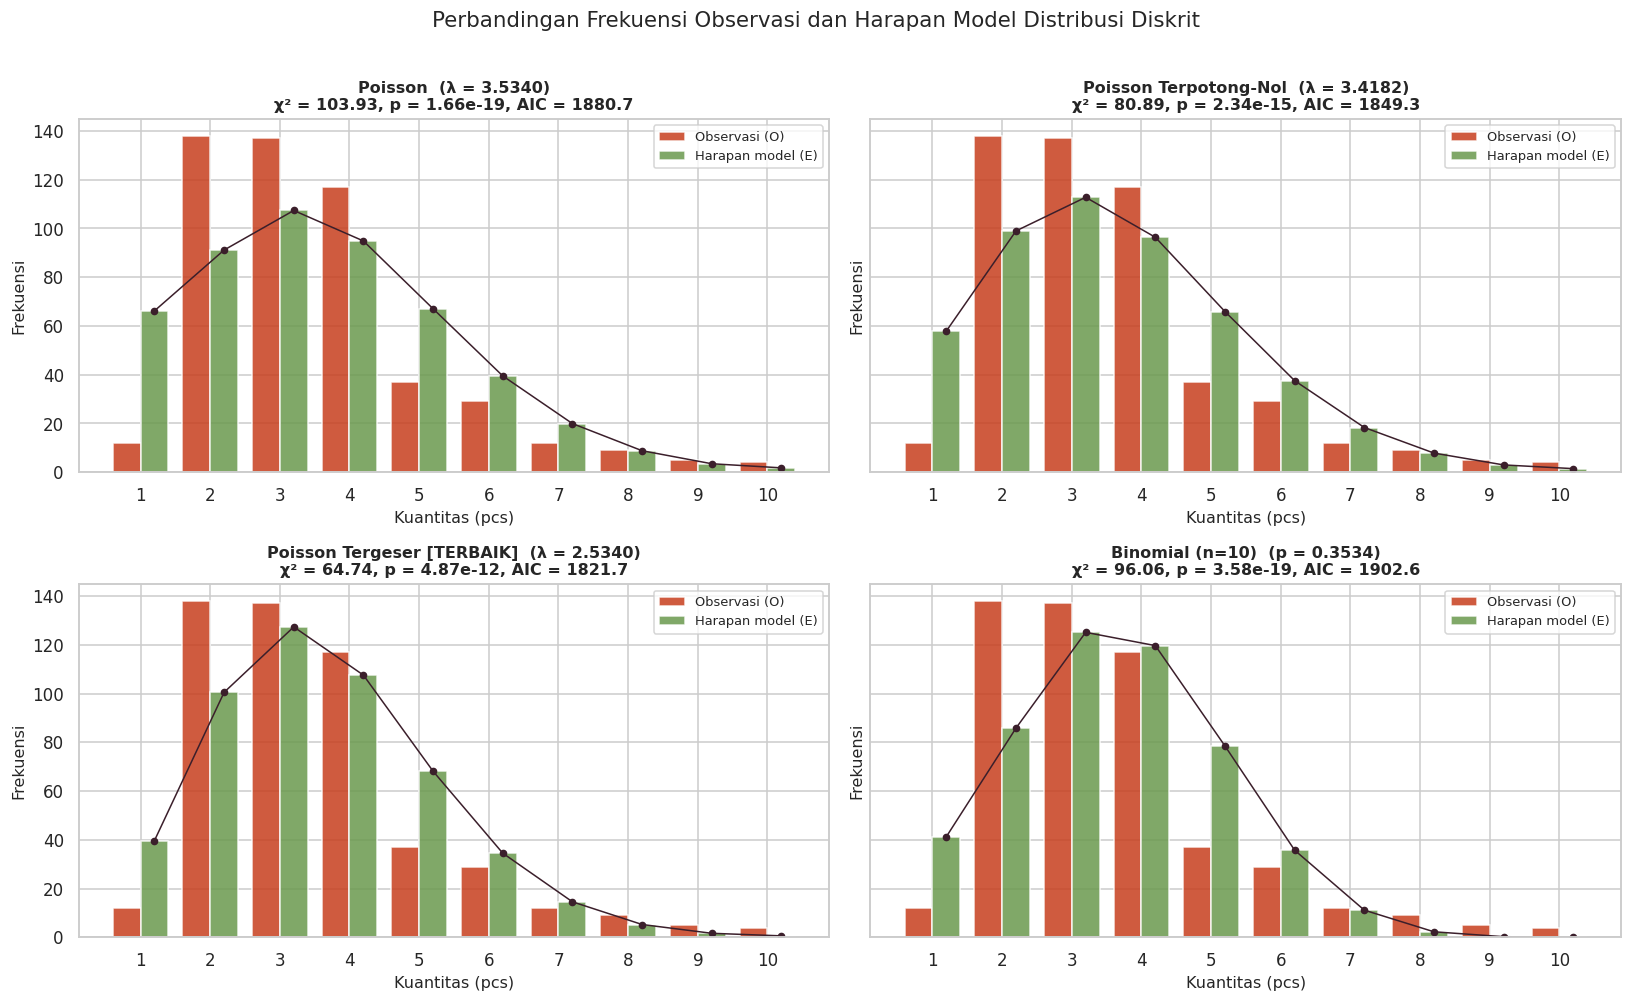

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
for ax, nama in zip(axes.ravel(), MODEL):
    baris = tabel_fit[tabel_fit.Model == nama].iloc[0]
    ax.bar(nilai_k - 0.2, frek, width=0.4, color=WARNA["qty"], alpha=0.85, label="Observasi (O)")
    ax.bar(nilai_k + 0.2, harapan[nama], width=0.4, color=WARNA["model"], alpha=0.85, label="Harapan model (E)")
    ax.plot(nilai_k + 0.2, harapan[nama], "o-", color=WARNA["aksen"], ms=4, lw=1)
    tanda = " [TERBAIK]" if nama == MODEL_TERBAIK else ""
    ax.set_title(f"{nama}{tanda}  ({baris['Parameter']})\nχ² = {baris['χ² hitung']:.2f}, "
                 f"p = {baris['p-value']:.2e}, AIC = {baris['AIC']:.1f}", fontsize=10.5)
    ax.set_xticks(nilai_k); ax.set_xlabel("Kuantitas (pcs)"); ax.set_ylabel("Frekuensi"); ax.legend(fontsize=8.5)
fig.suptitle("Perbandingan Frekuensi Observasi dan Harapan Model Distribusi Diskrit", y=1.01)
plt.tight_layout(); simpan_gambar(fig, "Fitting_Distribusi_Diskrit"); plt.show()

### Langkah 3.5 — Perhitungan peluang: empiris vs model terbaik
Contoh pertanyaan peluang yang relevan untuk laporan.

Kejadian,Peluang Empiris,Peluang Model (Poisson Tergeser),Selisih
P(X = 1) → membeli tepat 1 pcs,0.0240,0.0793,-0.0553
P(X = 2) → membeli tepat 2 pcs,0.2760,0.2011,0.0749
P(X ≤ 3) → membeli paling banyak 3 pcs,0.5740,0.5351,0.0389
P(2 ≤ X ≤ 4) → membeli 2 sampai 4 pcs,0.7840,0.6709,0.1131
P(X ≥ 5) → membeli minimal 5 pcs,0.1920,0.2497,-0.0577
P(X > 7) → membeli lebih dari 7 pcs,0.0360,0.0152,0.0208


💾 Tersimpan: output_visualisasi/Gambar_06_Perbandingan_Peluang.png


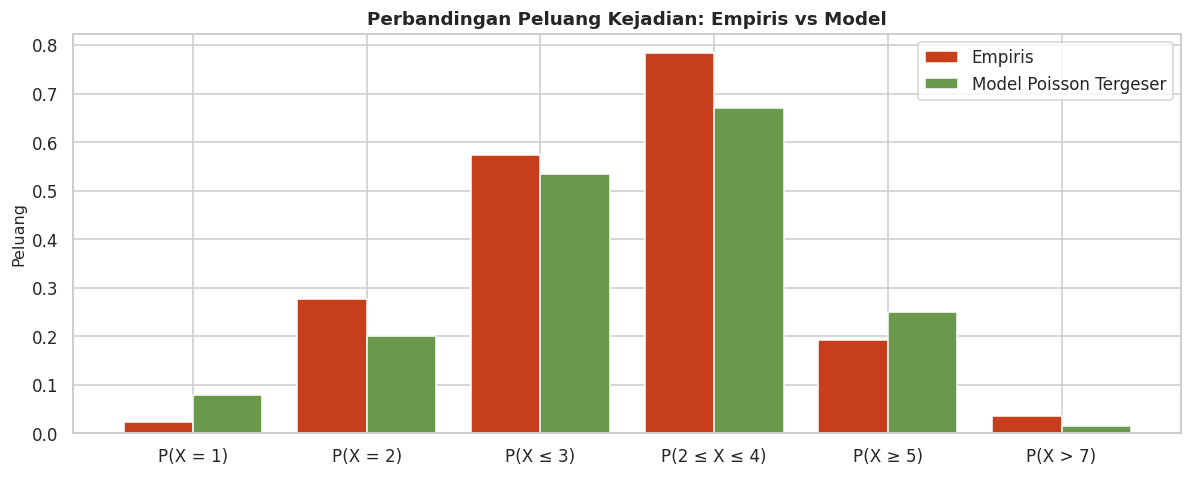

In [ ]:
p_model = peluang_kelas(MODEL_TERBAIK)
def P_emp(cond): return cond(q).mean()
def P_mod(cond): return p_model[cond(nilai_k)].sum()

pertanyaan = {
    "P(X = 1)  → membeli tepat 1 pcs":        lambda k: k == 1,
    "P(X = 2)  → membeli tepat 2 pcs":        lambda k: k == 2,
    "P(X ≤ 3)  → membeli paling banyak 3 pcs": lambda k: k <= 3,
    "P(2 ≤ X ≤ 4) → membeli 2 sampai 4 pcs":   lambda k: (k >= 2) & (k <= 4),
    "P(X ≥ 5)  → membeli minimal 5 pcs":       lambda k: k >= 5,
    "P(X > 7)  → membeli lebih dari 7 pcs":    lambda k: k > 7}
tabel_peluang = pd.DataFrame([{"Kejadian": t, "Peluang Empiris": P_emp(f),
                               f"Peluang Model ({MODEL_TERBAIK})": P_mod(f)} for t, f in pertanyaan.items()])
tabel_peluang["Selisih"] = tabel_peluang.iloc[:, 1] - tabel_peluang.iloc[:, 2]
TABEL_HASIL["Perhitungan_Peluang"] = tabel_peluang
display(tabel_peluang.style.format({c: "{:.4f}" for c in tabel_peluang.columns[1:]}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(11, 4.5))
lbl = [t.split("→")[0].strip() for t in pertanyaan]
xx = np.arange(len(lbl))
ax.bar(xx - 0.2, tabel_peluang.iloc[:, 1], 0.4, color=WARNA["qty"], label="Empiris")
ax.bar(xx + 0.2, tabel_peluang.iloc[:, 2], 0.4, color=WARNA["model"], label=f"Model {MODEL_TERBAIK}")
ax.set_xticks(xx); ax.set_xticklabels(lbl); ax.set_ylabel("Peluang"); ax.legend()
ax.set_title("Perbandingan Peluang Kejadian: Empiris vs Model")
plt.tight_layout(); simpan_gambar(fig, "Perbandingan_Peluang"); plt.show()

### Langkah 3.6 — Uji normalitas ketiga variabel utama
Penting untuk menentukan metode lanjutan (misalnya pemilihan korelasi Pearson vs Spearman).
$H_0$: data berdistribusi normal; $H_1$: data tidak berdistribusi normal. Digunakan **Shapiro-Wilk**, **Kolmogorov-Smirnov (Lilliefors)**, dan **D'Agostino-Pearson**.

Variabel,Shapiro-Wilk W,p (SW),KS-Lilliefors D,p (KS),D'Agostino K²,p (DA),Kesimpulan
Nilai Diskon (Rp),0.733885,1.65e-27,0.253819,1.00e-03,247.912294,1.47e-54,Tidak Normal
Berat Pengiriman (Gram),0.954082,2.35e-11,0.064840,1.00e-03,298.750445,1.34e-65,Tidak Normal
Kuantitas Pembelian (Pcs),0.860663,1.14e-20,0.200718,1.00e-03,124.556137,8.97e-28,Tidak Normal


💾 Tersimpan: output_visualisasi/Gambar_07_QQPlot_Normalitas.png


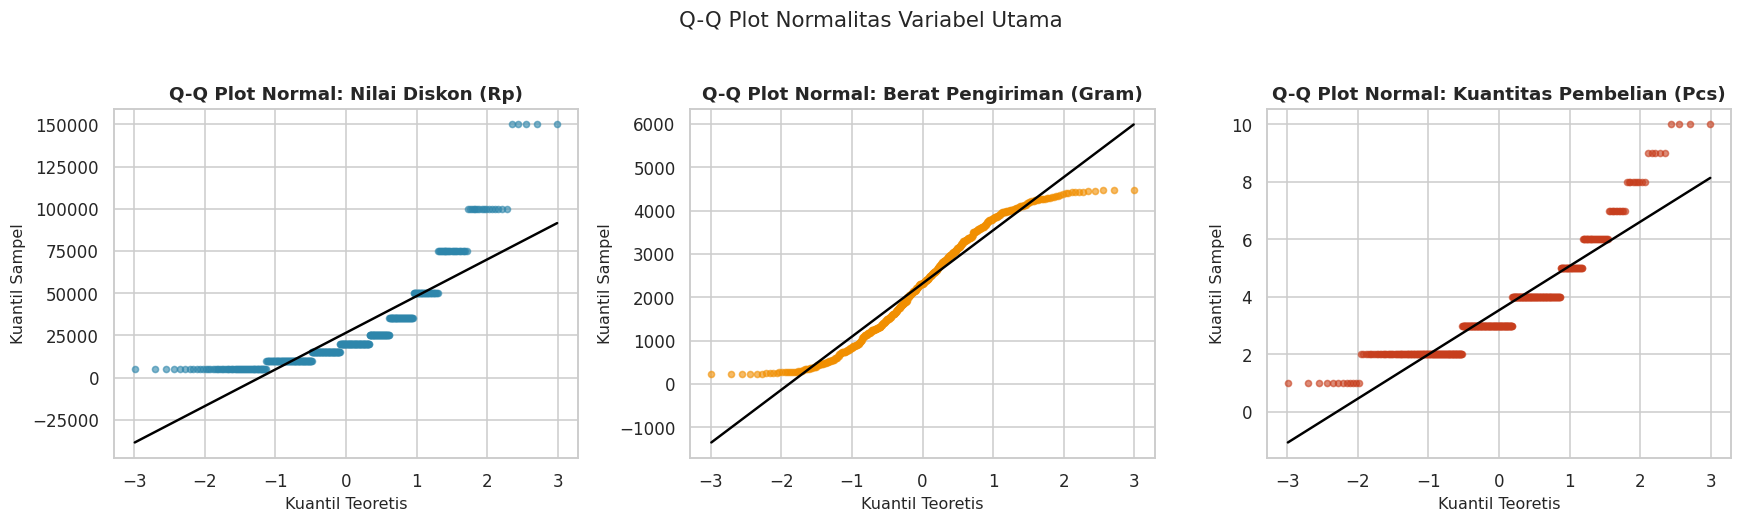

In [ ]:
from statsmodels.stats.diagnostic import lilliefors
hasil_norm = []
for k in VAR_UTAMA:
    x = df[k]
    sw = stats.shapiro(x); ks = lilliefors(x, dist="norm"); dp = stats.normaltest(x)
    hasil_norm.append({"Variabel": LABEL[k], "Shapiro-Wilk W": sw.statistic, "p (SW)": sw.pvalue,
                       "KS-Lilliefors D": ks[0], "p (KS)": ks[1], "D'Agostino K²": dp.statistic, "p (DA)": dp.pvalue,
                       "Kesimpulan": "Normal" if sw.pvalue > ALPHA else "Tidak Normal"})
tabel_norm = pd.DataFrame(hasil_norm)
TABEL_HASIL["Uji_Normalitas"] = tabel_norm
display(tabel_norm.style.format({c: "{:.4f}" for c in tabel_norm.columns if c not in ["Variabel", "Kesimpulan"]})
        .format({"p (SW)": "{:.2e}", "p (KS)": "{:.2e}", "p (DA)": "{:.2e}"}).hide(axis="index"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, k in zip(axes, VAR_UTAMA):
    stats.probplot(df[k], dist="norm", plot=ax)
    ax.get_lines()[0].set(color=WARNA_VAR[k], markersize=4, alpha=0.6)
    ax.get_lines()[1].set(color="black", lw=1.6)
    ax.set_title(f"Q-Q Plot Normal: {LABEL[k]}"); ax.set_xlabel("Kuantil Teoretis"); ax.set_ylabel("Kuantil Sampel")
fig.suptitle("Q-Q Plot Normalitas Variabel Utama", y=1.03)
plt.tight_layout(); simpan_gambar(fig, "QQPlot_Normalitas"); plt.show()

### Langkah 3.7 — Distribusi kuantitas pada setiap tingkat diskon
Melihat apakah bentuk distribusi kuantitas berubah ketika diskon berubah. Jika rata-rata kuantitas naik seiring diskon sementara variansi di tiap kelompok kecil, maka bentuk distribusi keseluruhan (Langkah 3.1) sebenarnya merupakan **campuran** beberapa kelompok — ini sekaligus menjadi jembatan ke Rumusan Masalah 3.

,n,Rata-rata Qty,Median,Variansi,Std,Min,Maks
Nilai_Diskon_Rp,,,,,,,
5000,64,2.3125,2.0000,1.0119,1.0059,1,5
10000,93,2.8387,2.0000,1.4194,1.1914,2,6
15000,76,3.0395,3.0000,0.6251,0.7906,2,6
20000,82,3.1829,3.0000,1.0402,1.0199,2,7
25000,50,3.1800,3.0000,0.8445,0.9190,2,5
35000,50,4.1000,4.0000,1.4388,1.1995,3,9
50000,37,4.5405,4.0000,1.0330,1.0164,4,8
75000,27,5.8148,6.0000,0.7721,0.8787,5,8
100000,16,8.1250,8.0000,1.1833,1.0878,7,10


💾 Tersimpan: output_visualisasi/Gambar_08_Kuantitas_per_Tingkat_Diskon.png


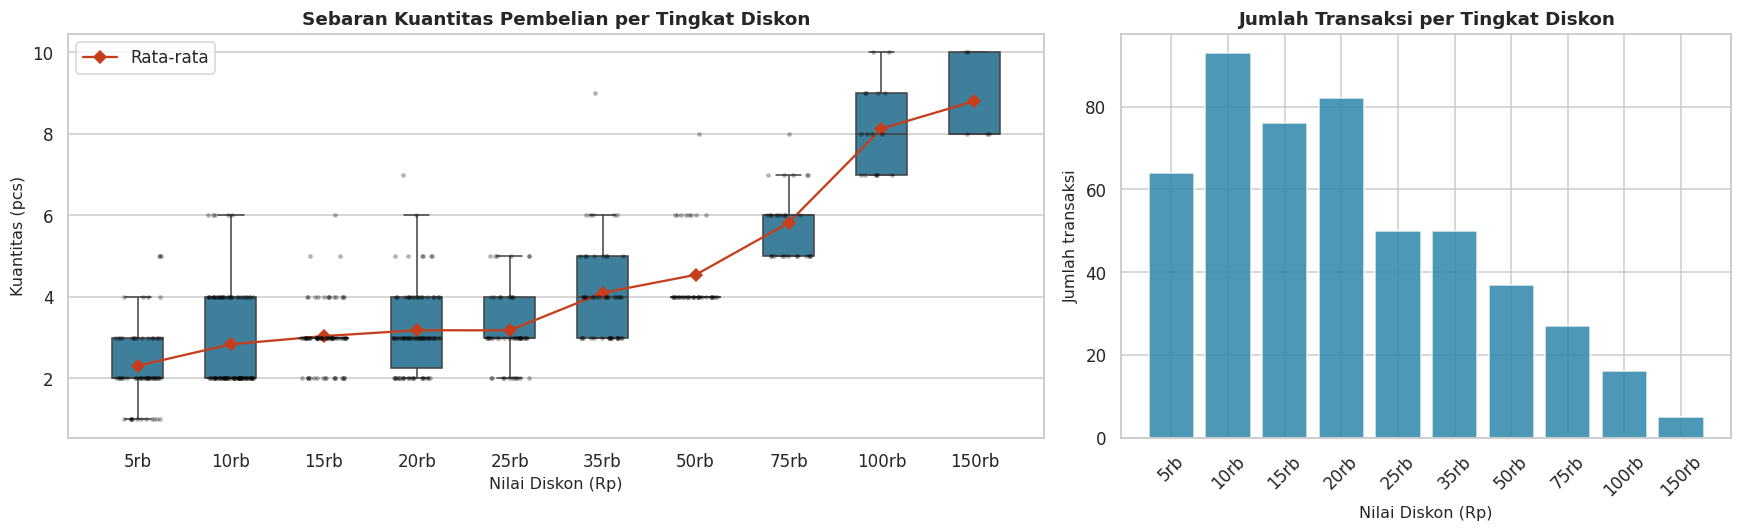

In [ ]:
per_diskon = df.groupby(X1)[Y].agg(["count", "mean", "median", "var", "std", "min", "max"])
per_diskon.columns = ["n", "Rata-rata Qty", "Median", "Variansi", "Std", "Min", "Maks"]
TABEL_HASIL["Qty_per_Tingkat_Diskon"] = per_diskon.reset_index()
display(per_diskon)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.6, 1]})
urut = sorted(df[X1].unique())
lbl_d = [f"{v/1000:,.0f}rb" for v in urut]
sns.boxplot(data=df, x=X1, y=Y, order=urut, ax=axes[0], color=WARNA["diskon"], width=0.55, fliersize=0)
sns.stripplot(data=df, x=X1, y=Y, order=urut, ax=axes[0], color="black", alpha=0.3, size=3, jitter=0.25)
axes[0].plot(range(len(urut)), per_diskon["Rata-rata Qty"].values, "D-", color=WARNA["qty"], label="Rata-rata")
axes[0].set_xticklabels(lbl_d); axes[0].set_xlabel("Nilai Diskon (Rp)"); axes[0].set_ylabel("Kuantitas (pcs)")
axes[0].set_title("Sebaran Kuantitas Pembelian per Tingkat Diskon"); axes[0].legend()

axes[1].bar(lbl_d, per_diskon["n"], color=WARNA["diskon"], alpha=0.85)
axes[1].set_title("Jumlah Transaksi per Tingkat Diskon"); axes[1].set_xlabel("Nilai Diskon (Rp)")
axes[1].set_ylabel("Jumlah transaksi"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); simpan_gambar(fig, "Kuantitas_per_Tingkat_Diskon"); plt.show()

---
## TAHAP 4 — Analisis Korelasi (Menjawab Rumusan Masalah 3, bagian hubungan)
### Langkah 4.1 — Koefisien korelasi Pearson dan Spearman beserta uji signifikansinya
- **Pearson (r)** mengukur hubungan **linier**: $r = \dfrac{\sum (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum (x_i-\bar x)^2 \sum (y_i-\bar y)^2}}$
- **Spearman (ρ)** mengukur hubungan **monoton** berbasis peringkat, lebih tahan terhadap data tidak normal dan pencilan (dipakai sebagai pembanding karena hasil Langkah 3.6).
- Uji: $H_0: \rho = 0$ (tidak ada hubungan), $H_1: \rho \ne 0$; statistik $t = r\sqrt{\dfrac{n-2}{1-r^2}}$.

Interpretasi kekuatan (Sugiyono): 0,00–0,199 sangat lemah; 0,20–0,399 lemah; 0,40–0,599 sedang; 0,60–0,799 kuat; 0,80–1,00 sangat kuat.

In [ ]:
def kekuatan(r):
    a = abs(r)
    kat = ("Sangat lemah" if a < .2 else "Lemah" if a < .4 else "Sedang" if a < .6 else "Kuat" if a < .8 else "Sangat kuat")
    return f"{kat} {'positif' if r > 0 else 'negatif'}"

pasangan = [(X1, Y), (X2, Y), (X1, X2)]
hasil_kor = []
for a, b in pasangan:
    pr = stats.pearsonr(df[a], df[b]); sp = stats.spearmanr(df[a], df[b])
    t_hit = pr.statistic * np.sqrt((n - 2) / (1 - pr.statistic ** 2))
    hasil_kor.append({"Pasangan": f"{LABEL[a]} ↔ {LABEL[b]}", "Pearson r": pr.statistic, "r²": pr.statistic ** 2,
                      "t hitung": t_hit, "t tabel (α/2)": stats.t.ppf(1 - ALPHA / 2, n - 2), "p (Pearson)": pr.pvalue,
                      "Spearman ρ": sp.statistic, "p (Spearman)": sp.pvalue,
                      "Kekuatan (Pearson)": kekuatan(pr.statistic),
                      "Keputusan": "Signifikan (Tolak H₀)" if pr.pvalue < ALPHA else "Tidak signifikan (Terima H₀)"})
tabel_kor = pd.DataFrame(hasil_kor)
TABEL_HASIL["Uji_Korelasi"] = tabel_kor
display(tabel_kor.style.format({"Pearson r": "{:.4f}", "r²": "{:.4f}", "t hitung": "{:.3f}", "t tabel (α/2)": "{:.3f}",
                                "p (Pearson)": "{:.2e}", "Spearman ρ": "{:.4f}", "p (Spearman)": "{:.2e}"})
        .hide(axis="index").set_caption("Tabel 4. Hasil Uji Korelasi"))

Pasangan,Pearson r,r²,t hitung,t tabel (α/2),p (Pearson),Spearman ρ,p (Spearman),Kekuatan (Pearson),Keputusan
Nilai Diskon (Rp) ↔ Kuantitas Pembelian (Pcs),0.7748,0.6003,27.348,1.965,3.14e-101,0.6213,1.03e-54,Kuat positif,Signifikan (Tolak H₀)
Berat Pengiriman (Gram) ↔ Kuantitas Pembelian (Pcs),-0.1067,0.0114,-2.394,1.965,1.70e-02,-0.0925,3.88e-02,Sangat lemah negatif,Signifikan (Tolak H₀)
Nilai Diskon (Rp) ↔ Berat Pengiriman (Gram),-0.0849,0.0072,-1.901,1.965,5.79e-02,-0.0703,1.16e-01,Sangat lemah negatif,Tidak signifikan (Terima H₀)


### Langkah 4.2 — Heatmap matriks korelasi

💾 Tersimpan: output_visualisasi/Gambar_09_Heatmap_Korelasi.png


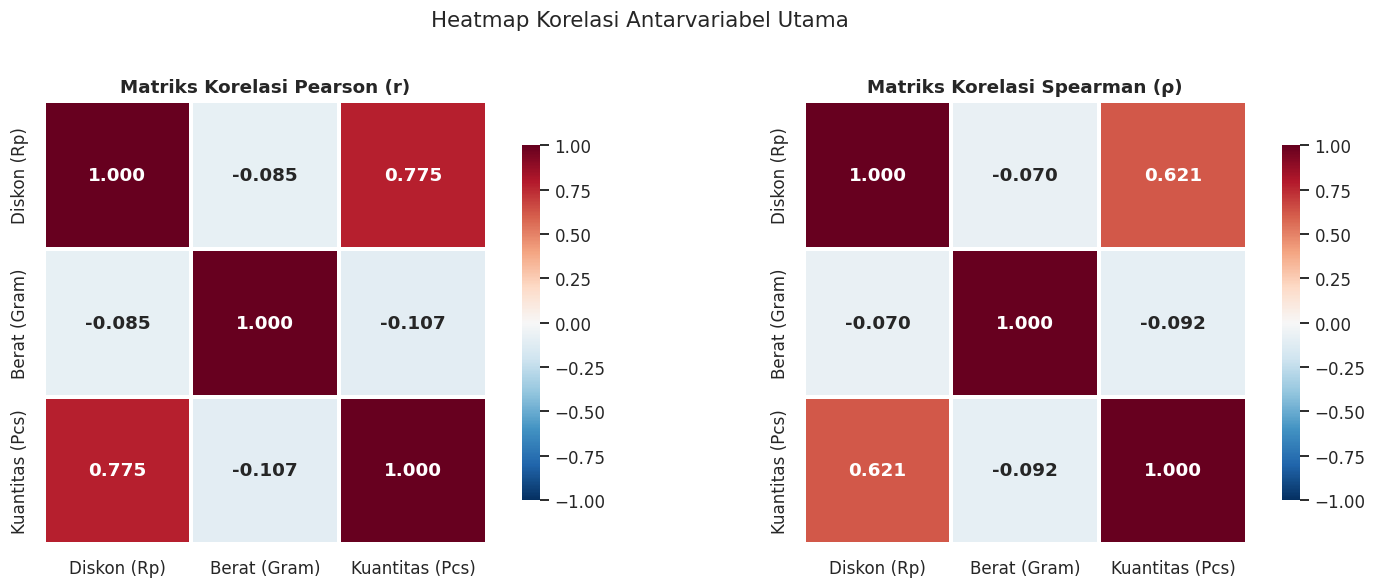

In [ ]:
nama_pendek = {X1: "Diskon (Rp)", X2: "Berat (Gram)", Y: "Kuantitas (Pcs)"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, met, judul in zip(axes, ["pearson", "spearman"], ["Pearson (r)", "Spearman (ρ)"]):
    m = df[VAR_UTAMA].corr(method=met).rename(index=nama_pendek, columns=nama_pendek)
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=1.5, cbar_kws={"shrink": 0.8}, annot_kws={"size": 12, "weight": "bold"})
    ax.set_title(f"Matriks Korelasi {judul}")
fig.suptitle("Heatmap Korelasi Antarvariabel Utama", y=1.02)
plt.tight_layout(); simpan_gambar(fig, "Heatmap_Korelasi"); plt.show()

### Langkah 4.3 — Diagram pencar (scatter plot) dengan garis regresi
Titik diberi sedikit *jitter* (geseran acak kecil) agar data yang bertumpuk pada nilai diskon/kuantitas yang sama tetap terlihat.

💾 Tersimpan: output_visualisasi/Gambar_10_Scatter_Regresi_Sederhana.png


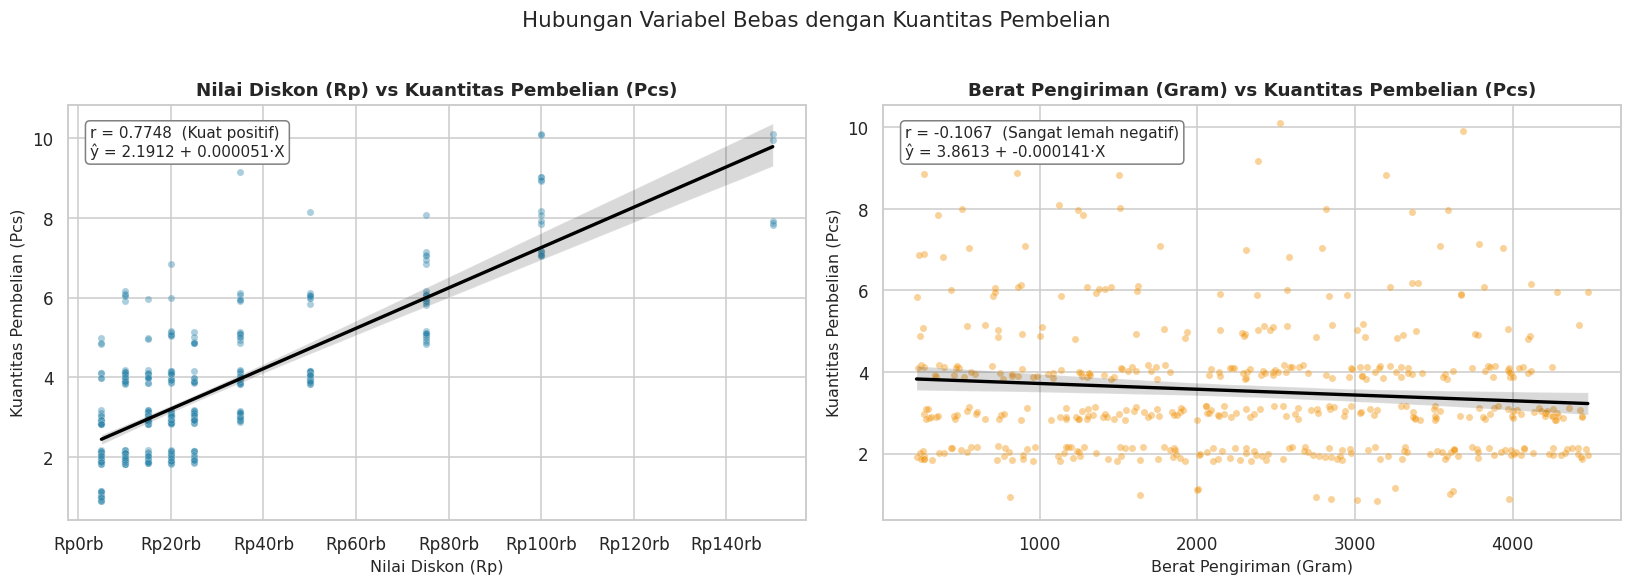

In [ ]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, xv in zip(axes, [X1, X2]):
    r = df[xv].corr(df[Y])
    jit_y = df[Y] + rng.uniform(-0.18, 0.18, n)
    ax.scatter(df[xv], jit_y, alpha=0.4, s=22, color=WARNA_VAR[xv], edgecolor="white", lw=0.3)
    sns.regplot(data=df, x=xv, y=Y, ax=ax, scatter=False, color="black", line_kws={"lw": 2.2})
    b1, b0 = np.polyfit(df[xv], df[Y], 1)
    ax.text(0.03, 0.95, f"r = {r:.4f}  ({kekuatan(r)})\nŷ = {b0:.4f} + {b1:.6f}·X",
            transform=ax.transAxes, va="top", fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray"))
    ax.set_xlabel(LABEL[xv]); ax.set_ylabel(LABEL[Y]); ax.set_title(f"{LABEL[xv]} vs {LABEL[Y]}")
    if xv == X1: ax.xaxis.set_major_formatter(mtick.FuncFormatter(rupiah))
fig.suptitle("Hubungan Variabel Bebas dengan Kuantitas Pembelian", y=1.02)
plt.tight_layout(); simpan_gambar(fig, "Scatter_Regresi_Sederhana"); plt.show()

### Langkah 4.4 — Pairplot seluruh variabel utama

💾 Tersimpan: output_visualisasi/Gambar_11_Pairplot_Variabel_Utama.png


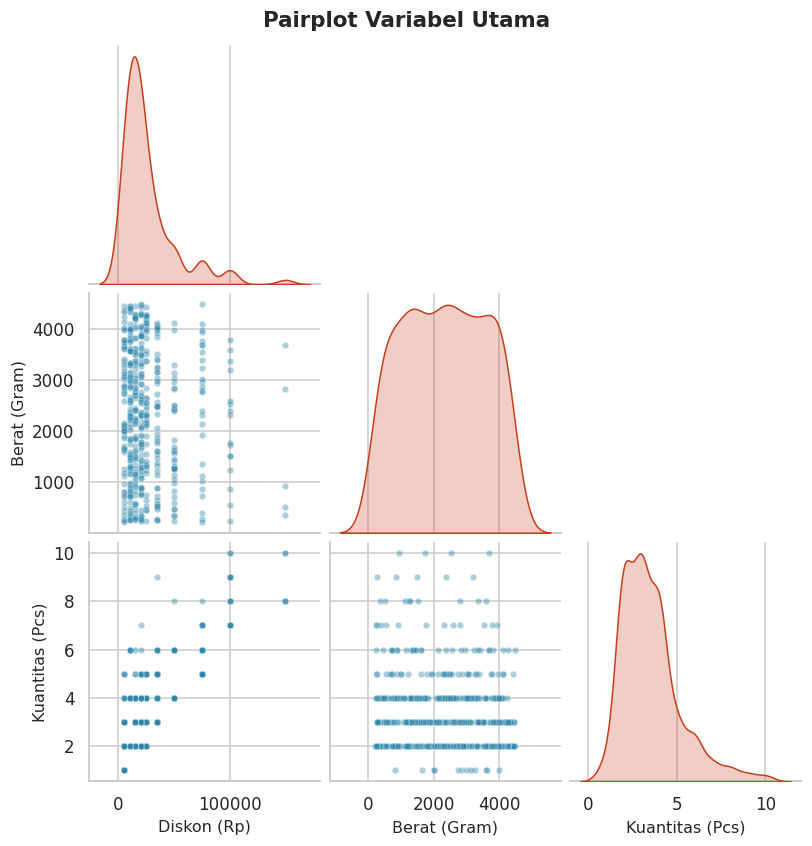

In [ ]:
g = sns.pairplot(df[VAR_UTAMA].rename(columns=nama_pendek), diag_kind="kde", corner=True,
                 plot_kws={"alpha": 0.4, "s": 18, "color": WARNA["diskon"]},
                 diag_kws={"color": WARNA["qty"], "fill": True})
g.figure.suptitle("Pairplot Variabel Utama", y=1.02, fontweight="bold")
simpan_gambar(g.figure, "Pairplot_Variabel_Utama"); plt.show()

---
## TAHAP 5 — Regresi Linier Berganda (Menjawab Rumusan Masalah 3, bagian pengaruh)
### Langkah 5.1 — Estimasi model
Model: $\hat{Y} = \beta_0 + \beta_1 X_1 + \beta_2 X_2$, dengan $X_1$ = diskon (Rp), $X_2$ = berat (gram), $Y$ = kuantitas (pcs). Parameter ditaksir dengan **Ordinary Least Squares (OLS)**: $\hat\beta = (X^TX)^{-1}X^Ty$.

In [ ]:
X_reg = sm.add_constant(df[[X1, X2]])
model = sm.OLS(df[Y], X_reg).fit()
print(model.summary())

# Model regresi sederhana sebagai pembanding
model_x1 = sm.OLS(df[Y], sm.add_constant(df[[X1]])).fit()
model_x2 = sm.OLS(df[Y], sm.add_constant(df[[X2]])).fit()

                               OLS Regression Results                              
Dep. Variable:     Kuantitas_Pembelian_Pcs   R-squared:                       0.602
Model:                                 OLS   Adj. R-squared:                  0.600
Method:                      Least Squares   F-statistic:                     375.8
Date:                     Tue, 06 Oct 2026   Prob (F-statistic):          3.76e-100
Time:                             23:39:45   Log-Likelihood:                -729.76
No. Observations:                      500   AIC:                             1466.
Df Residuals:                          497   BIC:                             1478.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

### Langkah 5.2 — Uji F (simultan), uji t (parsial), koefisien determinasi, dan koefisien terstandar
- **Uji F**: $H_0: \beta_1=\beta_2=0$ (diskon dan berat secara bersama-sama tidak berpengaruh).
- **Uji t**: $H_0: \beta_j = 0$ (variabel ke-j secara parsial tidak berpengaruh).
- **R²**: proporsi variasi kuantitas yang dijelaskan model.
- **Beta terstandar** dipakai untuk membandingkan besar pengaruh dua variabel yang satuannya berbeda.

In [ ]:
b0, b1, b2 = model.params
beta_std = model.params[[X1, X2]] * df[[X1, X2]].std() / df[Y].std()
t_tabel = stats.t.ppf(1 - ALPHA / 2, model.df_resid)
F_tabel = stats.f.ppf(1 - ALPHA, model.df_model, model.df_resid)

tabel_koef = pd.DataFrame({
    "Koefisien (B)": model.params, "Std. Error": model.bse, "Beta Terstandar": [np.nan, *beta_std],
    "t hitung": model.tvalues, "t tabel": t_tabel, "p-value": model.pvalues,
    "CI 95% Bawah": model.conf_int()[0], "CI 95% Atas": model.conf_int()[1]})
tabel_koef["Keputusan"] = np.where(model.pvalues < ALPHA, "Signifikan", "Tidak signifikan")
tabel_koef.index = ["Konstanta (β₀)", "Diskon (β₁)", "Berat (β₂)"]
TABEL_HASIL["Koefisien_Regresi"] = tabel_koef.reset_index().rename(columns={"index": "Parameter"})
display(tabel_koef.style.format({c: "{:.6f}" for c in tabel_koef.columns if c != "Keputusan"})
        .format({"p-value": "{:.2e}"}).set_caption("Tabel 5. Koefisien Regresi Linier Berganda"))

ringkas_model = pd.DataFrame({
    "Model": ["Y ~ Diskon", "Y ~ Berat", "Y ~ Diskon + Berat"],
    "R²": [model_x1.rsquared, model_x2.rsquared, model.rsquared],
    "Adj. R²": [model_x1.rsquared_adj, model_x2.rsquared_adj, model.rsquared_adj],
    "F hitung": [model_x1.fvalue, model_x2.fvalue, model.fvalue],
    "p-value F": [model_x1.f_pvalue, model_x2.f_pvalue, model.f_pvalue],
    "AIC": [model_x1.aic, model_x2.aic, model.aic]})
TABEL_HASIL["Perbandingan_Model_Regresi"] = ringkas_model
display(ringkas_model.style.format({"R²": "{:.4f}", "Adj. R²": "{:.4f}", "F hitung": "{:.3f}",
                                    "p-value F": "{:.2e}", "AIC": "{:.2f}"}).hide(axis="index"))

print(f"\n📌 Persamaan regresi:\n   Ŷ = {b0:.4f} + {b1:.8f}·Diskon + ({b2:.8f})·Berat")
print(f"\n📌 Uji F: F hitung = {model.fvalue:.3f} vs F tabel = {F_tabel:.3f}, p = {model.f_pvalue:.2e} → "
      f"{'Tolak H₀: diskon & berat berpengaruh simultan' if model.f_pvalue < ALPHA else 'Terima H₀'}")
print(f"📌 R² = {model.rsquared:.4f} → {model.rsquared*100:.2f}% variasi kuantitas dijelaskan oleh diskon dan berat; "
      f"sisanya {100-model.rsquared*100:.2f}% oleh faktor lain.")
print(f"📌 Interpretasi β₁: setiap kenaikan diskon Rp10.000, kuantitas naik rata-rata {b1*10000:.4f} pcs (berat konstan).")
print(f"📌 Interpretasi β₂: setiap kenaikan berat 1.000 gram, kuantitas berubah rata-rata {b2*1000:.4f} pcs (diskon konstan).")

,Koefisien (B),Std. Error,Beta Terstandar,t hitung,t tabel,p-value,CI 95% Bawah,CI 95% Atas,Keputusan
Konstanta (β₀),2.323781,0.113702,nan,20.437534,1.964749,7.77e-68,2.100386,2.547176,Signifikan
Diskon (β₁),0.000050,0.000002,0.771289,27.156578,1.964749,2.99e-100,0.000047,0.000054,Signifikan
Berat (β₂),-0.000055,0.000038,-0.041220,-1.451315,1.964749,1.47e-01,-0.000128,0.000019,Tidak signifikan


Model,R²,Adj. R²,F hitung,p-value F,AIC
Y ~ Diskon,0.6003,0.5995,747.920,3.14e-101,1465.63
Y ~ Berat,0.0114,0.0094,5.732,1.70e-02,1918.42
Y ~ Diskon + Berat,0.6020,0.6004,375.844,3.76e-100,1465.51



📌 Persamaan regresi:
   Ŷ = 2.3238 + 0.00005042·Diskon + (-0.00005455)·Berat

📌 Uji F: F hitung = 375.844 vs F tabel = 3.014, p = 3.76e-100 → Tolak H₀: diskon & berat berpengaruh simultan
📌 R² = 0.6020 → 60.20% variasi kuantitas dijelaskan oleh diskon dan berat; sisanya 39.80% oleh faktor lain.
📌 Interpretasi β₁: setiap kenaikan diskon Rp10.000, kuantitas naik rata-rata 0.5042 pcs (berat konstan).
📌 Interpretasi β₂: setiap kenaikan berat 1.000 gram, kuantitas berubah rata-rata -0.0546 pcs (diskon konstan).


### Langkah 5.3 — Uji asumsi klasik regresi
| Asumsi | Uji | Syarat terpenuhi |
|---|---|---|
| Normalitas residual | Shapiro-Wilk & KS | p > 0,05 |
| Homoskedastisitas | Breusch-Pagan | p > 0,05 |
| Non-autokorelasi | Durbin-Watson | DW ≈ 2 (≈ 1,5–2,5) |
| Non-multikolinearitas | VIF | VIF < 10 |

In [ ]:
resid = model.resid; fitted = model.fittedvalues
sw_r = stats.shapiro(resid); ks_r = lilliefors(resid, dist="norm")
bp = het_breuschpagan(resid, X_reg)
dw = durbin_watson(resid)
vif = {c: variance_inflation_factor(X_reg.values, i) for i, c in enumerate(X_reg.columns) if c != "const"}

tabel_asumsi = pd.DataFrame([
    {"Asumsi": "Normalitas residual", "Uji": "Shapiro-Wilk", "Statistik": sw_r.statistic, "p-value / Kriteria": f"{sw_r.pvalue:.2e}",
     "Kesimpulan": "Terpenuhi" if sw_r.pvalue > ALPHA else "Tidak terpenuhi"},
    {"Asumsi": "Normalitas residual", "Uji": "KS-Lilliefors", "Statistik": ks_r[0], "p-value / Kriteria": f"{ks_r[1]:.2e}",
     "Kesimpulan": "Terpenuhi" if ks_r[1] > ALPHA else "Tidak terpenuhi"},
    {"Asumsi": "Homoskedastisitas", "Uji": "Breusch-Pagan (LM)", "Statistik": bp[0], "p-value / Kriteria": f"{bp[1]:.2e}",
     "Kesimpulan": "Terpenuhi" if bp[1] > ALPHA else "Tidak terpenuhi (heteroskedastis)"},
    {"Asumsi": "Non-autokorelasi", "Uji": "Durbin-Watson", "Statistik": dw, "p-value / Kriteria": "1,5 < DW < 2,5",
     "Kesimpulan": "Terpenuhi" if 1.5 < dw < 2.5 else "Tidak terpenuhi"},
    *[{"Asumsi": "Non-multikolinearitas", "Uji": f"VIF {LABEL[c]}", "Statistik": v, "p-value / Kriteria": "VIF < 10",
       "Kesimpulan": "Terpenuhi" if v < 10 else "Tidak terpenuhi"} for c, v in vif.items()]])
TABEL_HASIL["Uji_Asumsi_Klasik"] = tabel_asumsi
display(tabel_asumsi.style.format({"Statistik": "{:.4f}"}).hide(axis="index")
        .set_caption("Tabel 6. Hasil Uji Asumsi Klasik"))

# Jika ada heteroskedastisitas, sajikan juga standard error robust (HC3) sebagai pembanding
if bp[1] <= ALPHA:
    model_robust = sm.OLS(df[Y], X_reg).fit(cov_type="HC3")
    print("⚠️ Terdeteksi heteroskedastisitas → berikut uji t dengan standard error robust (HC3):")
    display(pd.DataFrame({"Koefisien": model_robust.params, "SE Robust": model_robust.bse,
                          "z hitung": model_robust.tvalues, "p-value": model_robust.pvalues}))

Asumsi,Uji,Statistik,p-value / Kriteria,Kesimpulan
Normalitas residual,Shapiro-Wilk,0.9245,3.75e-15,Tidak terpenuhi
Normalitas residual,KS-Lilliefors,0.1357,1.00e-03,Tidak terpenuhi
Homoskedastisitas,Breusch-Pagan (LM),3.0417,2.19e-01,Terpenuhi
Non-autokorelasi,Durbin-Watson,1.9571,"1,5 < DW < 2,5",Terpenuhi
Non-multikolinearitas,VIF Nilai Diskon (Rp),1.0073,VIF < 10,Terpenuhi
Non-multikolinearitas,VIF Berat Pengiriman (Gram),1.0073,VIF < 10,Terpenuhi


### Langkah 5.4 — Visualisasi diagnostik residual

💾 Tersimpan: output_visualisasi/Gambar_12_Diagnostik_Residual_Regresi.png


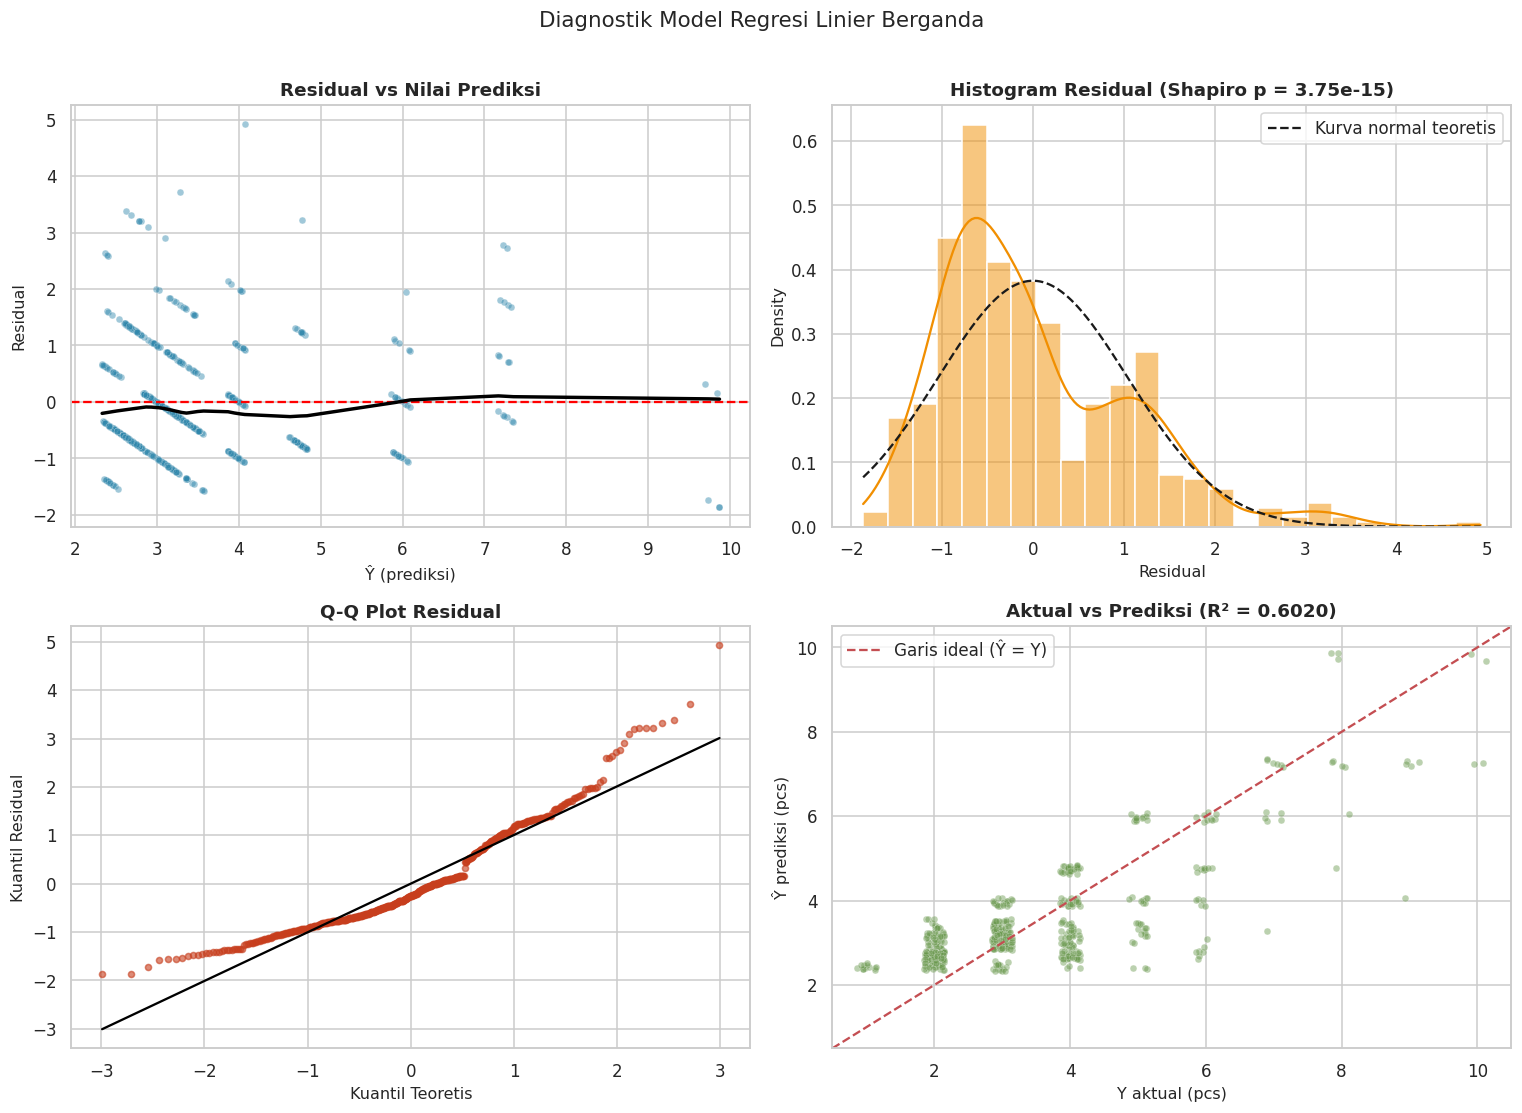

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
ax.scatter(fitted, resid, alpha=0.45, s=20, color=WARNA["diskon"], edgecolor="white", lw=0.3)
ax.axhline(0, color="red", ls="--"); sns.regplot(x=fitted, y=resid, lowess=True, scatter=False, ax=ax, color="black")
ax.set_title("Residual vs Nilai Prediksi"); ax.set_xlabel("Ŷ (prediksi)"); ax.set_ylabel("Residual")

ax = axes[0, 1]
sns.histplot(resid, kde=True, ax=ax, color=WARNA["berat"], bins=25, stat="density", edgecolor="white")
xs = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, 0, resid.std()), "k--", label="Kurva normal teoretis"); ax.legend()
ax.set_title(f"Histogram Residual (Shapiro p = {sw_r.pvalue:.2e})"); ax.set_xlabel("Residual")

ax = axes[1, 0]
stats.probplot(resid, dist="norm", plot=ax)
ax.get_lines()[0].set(color=WARNA["qty"], markersize=4, alpha=0.6); ax.get_lines()[1].set(color="black")
ax.set_title("Q-Q Plot Residual"); ax.set_xlabel("Kuantil Teoretis"); ax.set_ylabel("Kuantil Residual")

ax = axes[1, 1]
ax.scatter(df[Y] + rng.uniform(-0.15, 0.15, n), fitted, alpha=0.45, s=20, color=WARNA["model"], edgecolor="white", lw=0.3)
lim = [min(df[Y].min(), fitted.min()) - 0.5, max(df[Y].max(), fitted.max()) + 0.5]
ax.plot(lim, lim, "r--", label="Garis ideal (Ŷ = Y)"); ax.set_xlim(lim); ax.set_ylim(lim); ax.legend()
ax.set_title(f"Aktual vs Prediksi (R² = {model.rsquared:.4f})"); ax.set_xlabel("Y aktual (pcs)"); ax.set_ylabel("Ŷ prediksi (pcs)")
fig.suptitle("Diagnostik Model Regresi Linier Berganda", y=1.01)
plt.tight_layout(); simpan_gambar(fig, "Diagnostik_Residual_Regresi"); plt.show()

### Langkah 5.5 — Visualisasi bidang regresi 3D dan perbandingan besar pengaruh

💾 Tersimpan: output_visualisasi/Gambar_13_Bidang_Regresi_3D_Beta.png


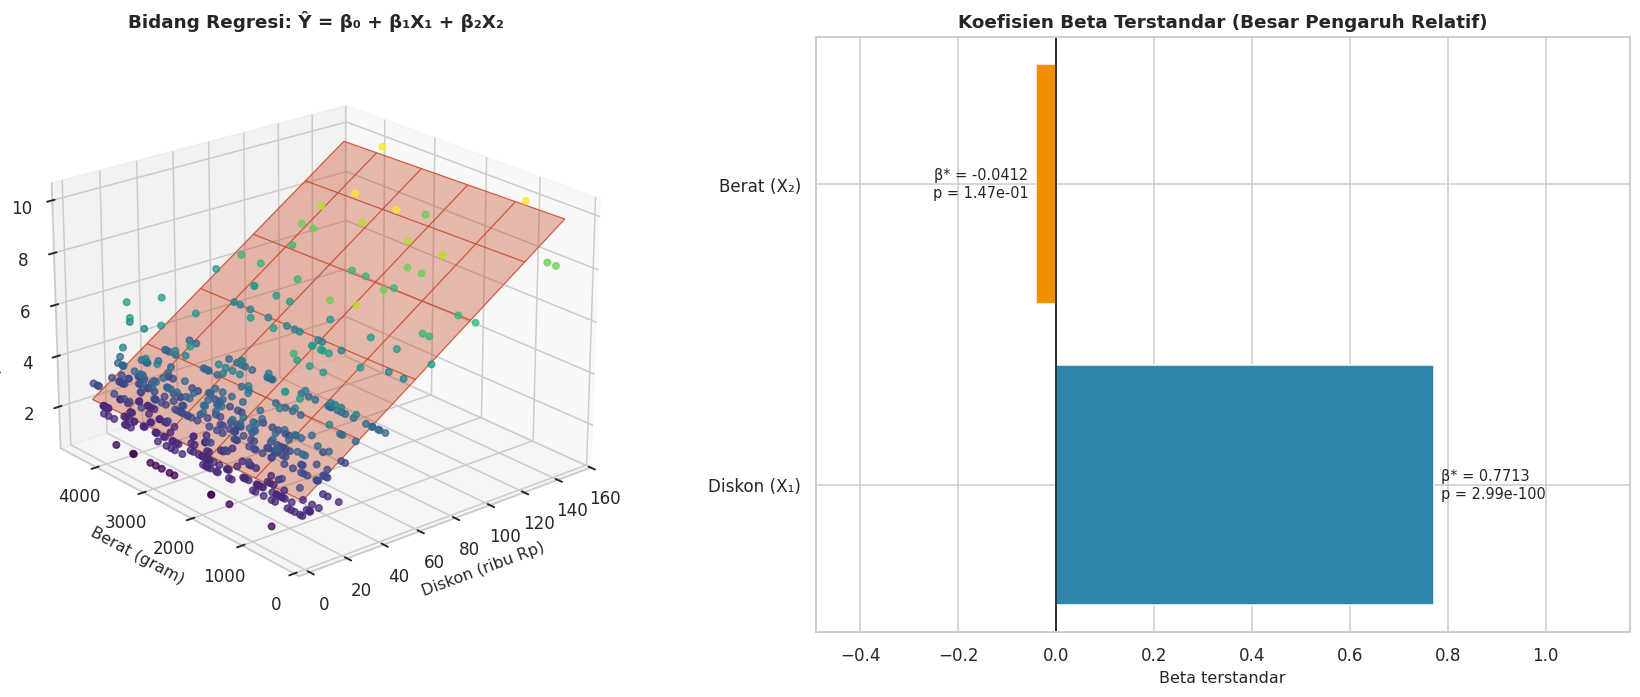

In [ ]:
fig = plt.figure(figsize=(16, 6.5))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")
ax3.scatter(df[X1] / 1000, df[X2], df[Y], c=df[Y], cmap="viridis", s=18, alpha=0.75)
g1, g2 = np.meshgrid(np.linspace(df[X1].min(), df[X1].max(), 20), np.linspace(df[X2].min(), df[X2].max(), 20))
bidang = b0 + b1 * g1 + b2 * g2
ax3.plot_surface(g1 / 1000, g2, bidang, alpha=0.35, color=WARNA["qty"], shade=False, edgecolor="none")
ax3.plot_wireframe(g1 / 1000, g2, bidang, rstride=4, cstride=4, color=WARNA["qty"], lw=0.8, alpha=0.8)
ax3.set_xlabel("Diskon (ribu Rp)"); ax3.set_ylabel("Berat (gram)"); ax3.set_zlabel("Kuantitas (pcs)")
ax3.set_title("Bidang Regresi: Ŷ = β₀ + β₁X₁ + β₂X₂"); ax3.view_init(elev=22, azim=-130)

ax = fig.add_subplot(1, 2, 2)
nm = ["Diskon (X₁)", "Berat (X₂)"]
warna_b = [WARNA["diskon"], WARNA["berat"]]
bars = ax.barh(nm, beta_std.values, color=warna_b)
ax.bar_label(bars, labels=[f"β* = {v:.4f}\np = {p:.2e}" for v, p in zip(beta_std.values, model.pvalues[[X1, X2]])],
             padding=5, fontsize=9.5)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(min(0, beta_std.min()) - 0.45, beta_std.max() + 0.4)
ax.set_title("Koefisien Beta Terstandar (Besar Pengaruh Relatif)"); ax.set_xlabel("Beta terstandar")
plt.tight_layout(); simpan_gambar(fig, "Bidang_Regresi_3D_Beta"); plt.show()

---
## TAHAP 6 — Visualisasi Pendukung (Konteks Data)
Variabel pendukung (kategori produk, provinsi, tanggal) tidak menjadi fokus rumusan masalah, tetapi berguna di bab **gambaran umum data**.

💾 Tersimpan: output_visualisasi/Gambar_14_Distribusi_Kategori_Provinsi.png


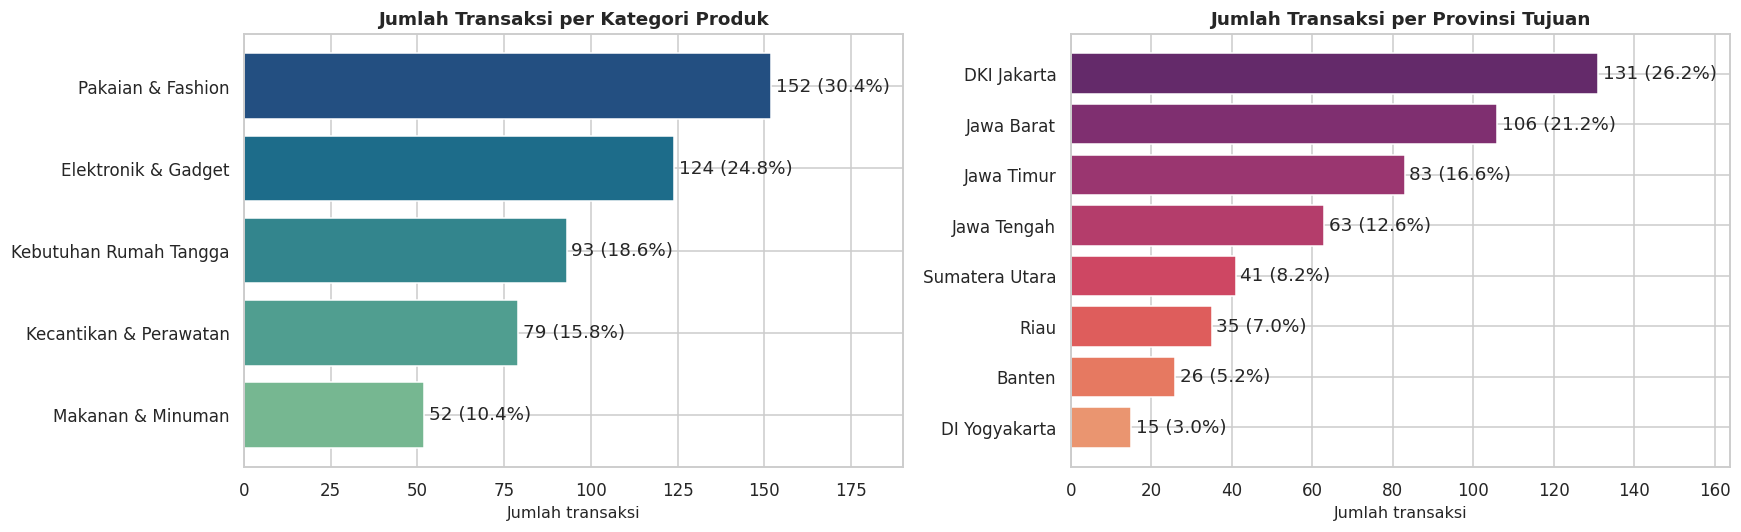

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
kat = df["Kategori_Produk"].value_counts()
b = axes[0].barh(kat.index[::-1], kat.values[::-1], color=sns.color_palette("crest", len(kat)))
axes[0].bar_label(b, labels=[f"{v} ({v/n*100:.1f}%)" for v in kat.values[::-1]], padding=3)
axes[0].set_title("Jumlah Transaksi per Kategori Produk"); axes[0].set_xlabel("Jumlah transaksi")
axes[0].set_xlim(0, kat.max() * 1.25)

prov = df["Provinsi_Tujuan"].value_counts()
b = axes[1].barh(prov.index[::-1], prov.values[::-1], color=sns.color_palette("flare", len(prov)))
axes[1].bar_label(b, labels=[f"{v} ({v/n*100:.1f}%)" for v in prov.values[::-1]], padding=3)
axes[1].set_title("Jumlah Transaksi per Provinsi Tujuan"); axes[1].set_xlabel("Jumlah transaksi")
axes[1].set_xlim(0, prov.max() * 1.25)
plt.tight_layout(); simpan_gambar(fig, "Distribusi_Kategori_Provinsi"); plt.show()

💾 Tersimpan: output_visualisasi/Gambar_15_Rata_rata_per_Kategori.png


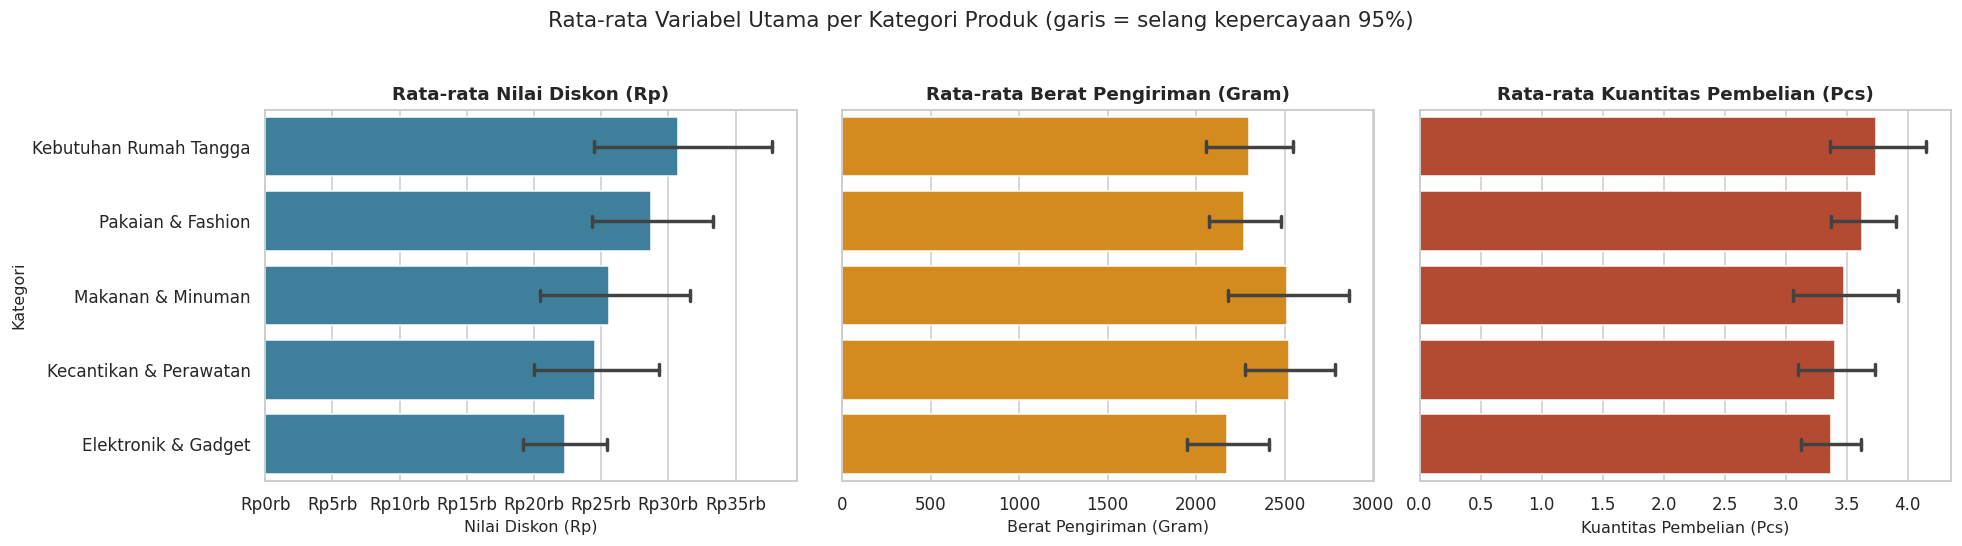

In [ ]:
rata_kat = df.groupby("Kategori_Produk")[VAR_UTAMA].mean().sort_values(Y, ascending=False)
TABEL_HASIL["Rata_rata_per_Kategori"] = rata_kat.reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, k in zip(axes, VAR_UTAMA):
    sns.barplot(data=df, y="Kategori_Produk", x=k, order=rata_kat.index, ax=ax, color=WARNA_VAR[k],
                errorbar=("ci", 95), capsize=0.15)
    ax.set_title(f"Rata-rata {LABEL[k]}"); ax.set_xlabel(LABEL[k]); ax.set_ylabel("" if k != X1 else "Kategori")
    if k == X1: ax.xaxis.set_major_formatter(mtick.FuncFormatter(rupiah))
    if k != X1: ax.set_yticklabels([])
fig.suptitle("Rata-rata Variabel Utama per Kategori Produk (garis = selang kepercayaan 95%)", y=1.03)
plt.tight_layout(); simpan_gambar(fig, "Rata_rata_per_Kategori"); plt.show()

💾 Tersimpan: output_visualisasi/Gambar_16_Tren_Bulanan.png


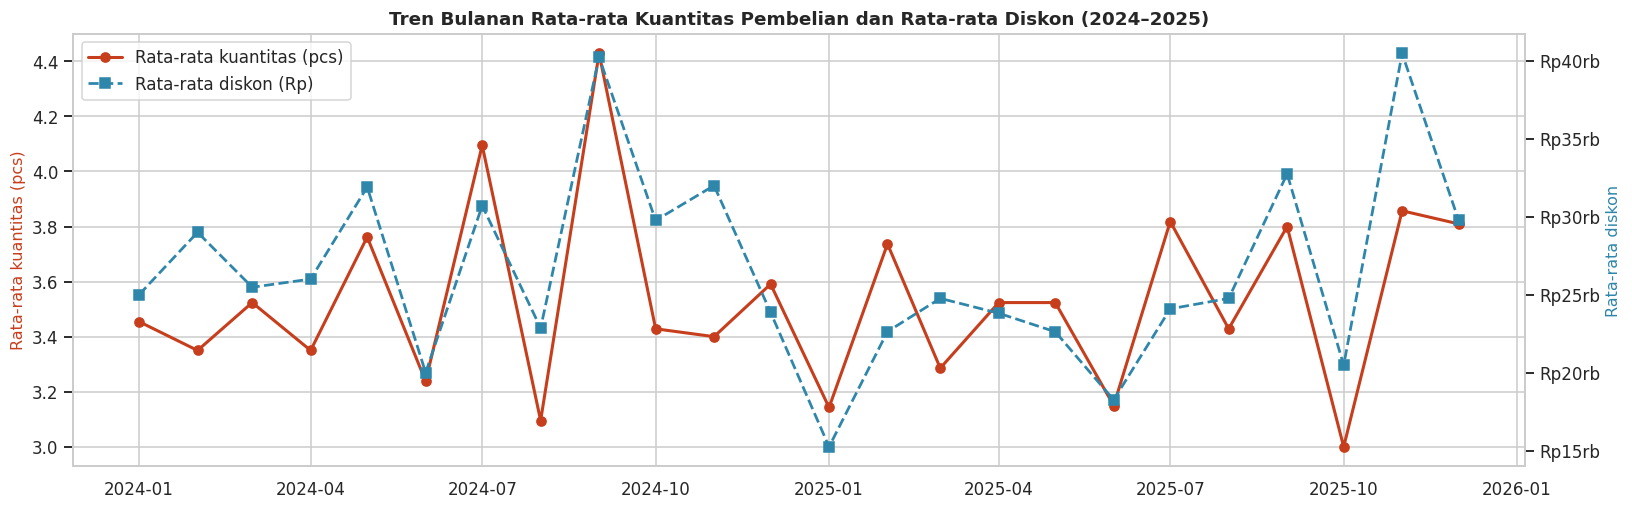

In [ ]:
bulanan = df.set_index("Tanggal_Transaksi").resample("MS").agg(
    Jumlah_Transaksi=(Y, "size"), Rata_Qty=(Y, "mean"), Rata_Diskon=(X1, "mean"))
TABEL_HASIL["Tren_Bulanan"] = bulanan.reset_index()

fig, ax1 = plt.subplots(figsize=(15, 4.8))
ax1.plot(bulanan.index, bulanan["Rata_Qty"], "o-", color=WARNA["qty"], lw=2, label="Rata-rata kuantitas (pcs)")
ax1.set_ylabel("Rata-rata kuantitas (pcs)", color=WARNA["qty"])
ax2 = ax1.twinx()
ax2.plot(bulanan.index, bulanan["Rata_Diskon"], "s--", color=WARNA["diskon"], lw=1.8, label="Rata-rata diskon (Rp)")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(rupiah)); ax2.set_ylabel("Rata-rata diskon", color=WARNA["diskon"])
ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
ax1.set_title("Tren Bulanan Rata-rata Kuantitas Pembelian dan Rata-rata Diskon (2024–2025)")
plt.tight_layout(); simpan_gambar(fig, "Tren_Bulanan"); plt.show()

---
## TAHAP 7 — Ringkasan Jawaban Rumusan Masalah dan Ekspor Hasil
Teks di bawah dibentuk otomatis dari hasil perhitungan, sehingga selalu konsisten dengan angka di tabel dan grafik. Gunakan sebagai **draf** bab kesimpulan, lalu sempurnakan dengan bahasa tim sendiri.

In [ ]:
td = tabel_deskriptif
def baris_desk(k):
    c = td[LABEL[k]]
    return (f"   • {LABEL[k]}: rata-rata {c['Rata-rata']:,.2f}, variansi {c['Variansi (s²)']:,.2f}, "
            f"deviasi standar {c['Deviasi Standar (s)']:,.2f}, CV {c['Koef. Variasi (%)']:.2f}%, skewness {c['Skewness']:.3f}")

terbaik = tabel_fit.iloc[0]
ada_cocok = (tabel_fit["p-value"] > ALPHA).any()
r1 = df[X1].corr(df[Y]); r2 = df[X2].corr(df[Y])

print("=" * 100)
print("RUMUSAN MASALAH 1 — Karakteristik statistika deskriptif")
for k in VAR_UTAMA: print(baris_desk(k))
cv_max = td.loc["Koef. Variasi (%)"].idxmax()
print(f"   → Variabel paling heterogen (CV terbesar): {cv_max}.")

print("\nRUMUSAN MASALAH 2 — Distribusi probabilitas kuantitas pembelian")
print(f"   • Kuantitas berkisar {q.min()}–{q.max()} pcs, modus {int(df[Y].mode()[0])} pcs, E(X) = {q.mean():.3f}, "
      f"Var(X) = {q.var(ddof=1):.3f}; distribusi menceng kanan (skewness {df[Y].skew():.3f}).")
print(f"   • {tabel_frek.loc[tabel_frek['Kuantitas (k)'].between(2,4),'Persentase (%)'].sum():.1f}% transaksi membeli 2–4 pcs.")
print(f"   • Model dengan AIC terkecil: {terbaik['Model']} ({terbaik['Parameter']}), χ² = {terbaik['χ² hitung']:.2f}, "
      f"p = {terbaik['p-value']:.2e}.")
if ada_cocok:
    print("   • Model yang lolos uji Chi-Square (p > 0,05): " + ", ".join(tabel_fit.loc[tabel_fit['p-value'] > ALPHA, 'Model']))
else:
    print("   • Tidak ada model diskrit tunggal yang lolos uji Chi-Square pada α = 0,05; model terbaik di atas adalah")
    print("     pendekatan terdekat. Langkah 3.7 menunjukkan distribusi keseluruhan merupakan campuran dari beberapa")
    print("     kelompok diskon dengan rata-rata berbeda, sehingga bentuknya tidak bisa diwakili satu distribusi standar.")

print("\nRUMUSAN MASALAH 3 — Korelasi dan pengaruh")
print(f"   • Korelasi Diskon–Kuantitas: r = {r1:.4f} ({kekuatan(r1)}), p = {stats.pearsonr(df[X1], df[Y]).pvalue:.2e}")
print(f"   • Korelasi Berat–Kuantitas : r = {r2:.4f} ({kekuatan(r2)}), p = {stats.pearsonr(df[X2], df[Y]).pvalue:.2e}")
print(f"   • Persamaan regresi: Ŷ = {b0:.4f} + {b1:.8f}·X₁ + ({b2:.8f})·X₂")
print(f"   • Uji F: F = {model.fvalue:.3f}, p = {model.f_pvalue:.2e}; R² = {model.rsquared:.4f} "
      f"({model.rsquared*100:.2f}% variasi kuantitas dijelaskan bersama oleh diskon dan berat).")
for c, nm in [(X1, "Diskon"), (X2, "Berat")]:
    print(f"   • Uji t {nm}: t = {model.tvalues[c]:.3f}, p = {model.pvalues[c]:.2e} → "
          f"{'berpengaruh signifikan' if model.pvalues[c] < ALPHA else 'tidak berpengaruh signifikan'}; beta terstandar = {beta_std[c]:.4f}")
print(f"   → Variabel dengan pengaruh terbesar: {'Diskon' if abs(beta_std[X1]) > abs(beta_std[X2]) else 'Berat'}.")
print("=" * 100)

RUMUSAN MASALAH 1 — Karakteristik statistika deskriptif
   • Nilai Diskon (Rp): rata-rata 26,510.00, variansi 638,847,595.19, deviasi standar 25,275.43, CV 95.34%, skewness 2.263
   • Berat Pengiriman (Gram): rata-rata 2,318.45, variansi 1,558,698.63, deviasi standar 1,248.48, CV 53.85%, skewness -0.006
   • Kuantitas Pembelian (Pcs): rata-rata 3.53, variansi 2.73, deviasi standar 1.65, CV 46.76%, skewness 1.359
   → Variabel paling heterogen (CV terbesar): Nilai Diskon (Rp).

RUMUSAN MASALAH 2 — Distribusi probabilitas kuantitas pembelian
   • Kuantitas berkisar 1–10 pcs, modus 2 pcs, E(X) = 3.534, Var(X) = 2.730; distribusi menceng kanan (skewness 1.359).
   • 78.4% transaksi membeli 2–4 pcs.
   • Model dengan AIC terkecil: Poisson Tergeser (λ = 2.5340), χ² = 64.74, p = 4.87e-12.
   • Tidak ada model diskrit tunggal yang lolos uji Chi-Square pada α = 0,05; model terbaik di atas adalah
     pendekatan terdekat. Langkah 3.7 menunjukkan distribusi keseluruhan merupakan campuran dari beb

---
## TAHAP 8 — Dashboard Hasil Analisis Statistika
Dashboard ini memvisualisasikan **hasil analisis statistika** dari Tahap 2–5 dalam satu layar. Setiap kartu adalah satu grafik hasil uji/perhitungan, dikelompokkan per rumusan masalah:

| Baris | Kartu grafik | Hasil analisis yang divisualisasikan |
|---|---|---|
| KPI | 6 angka ringkas | n, x̄ ± s ketiga variabel, r, R² |
| **RM 1** Deskriptif | Histogram diskon, berat, kuantitas · Koefisien variasi | x̄, median, s, s², skewness, CV |
| **RM 2** Distribusi | PMF observasi vs 4 model · Perbandingan AIC · Q-Q plot normalitas | Uji χ² goodness of fit, pemilihan model, uji Shapiro-Wilk |
| **RM 3** Korelasi | Heatmap korelasi · Scatter diskon–qty · Scatter berat–qty · Qty per tingkat diskon | Pearson r + signifikansi, garis regresi sederhana |
| **RM 3** Regresi | Beta terstandar + CI 95% · Donat R² · Aktual vs prediksi · Histogram residual | Uji t, R², RMSE, uji normalitas residual |
| Uji hipotesis | Grafik −log₁₀(p) semua uji terhadap batas α = 0,05 | Keputusan tolak / gagal tolak H₀ |

Ada **dua versi**: (1) **Dashboard interaktif** (Langkah 8.4–8.5, tampil paling akhir) yang bisa diklik seperti web dan tersimpan sebagai file `.html`, dan (2) PNG 300 dpi untuk slide PPT (Langkah 8.3).

> Jalankan Tahap 8 **setelah** Tahap 0–6 selesai, karena dashboard memakai variabel hasil tahap-tahap tersebut.

### Langkah 8.1 — Format angka dan tema warna dashboard

In [ ]:
import io, base64, textwrap
from matplotlib.patches import FancyBboxPatch, Patch

def idn(v, d=2):
    s = f"{v:,.{d}f}"
    return s.replace(",", "#").replace(".", ",").replace("#", ".")

SUP = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")
def ilmiah(v, d=2):
    e = int(np.floor(np.log10(abs(v)))); return f"{idn(v / 10 ** e, d)}×10{str(e).translate(SUP)}"

def pval(p):
    return "p < 0,001" if p < 0.001 else f"p = {idn(p, 3)}"

TEAL, ORANYE = "#1FC1CB", "#FF5A1F"
C = {"bg": "#4E5468", "panel": "#3A3F52", "putih": "#FFFFFF", "teks": "#2B2F3A", "redup": "#8A90A3"}
TEMA_PUTIH = {"bg": "#FFFFFF", "fg": "#2B2F3A", "sub": "#8A90A3", "grid": "#E9EDF2", "netral": "#5C6380"}
TEMA_GELAP = {"bg": "#3A3F52", "fg": "#FFFFFF", "sub": "#C9CEDB", "grid": "#4E5468", "netral": "#9AA0B4"}
FS = 8      # ukuran huruf dasar grafik di dalam kartu

td = tabel_deskriptif
NAMA_PENDEK = {X1: "Diskon", X2: "Berat", Y: "Kuantitas"}
LABEL_SUMBU = {X1: "nilai diskon (Rp)", X2: "berat pengiriman (gram)", Y: "kuantitas pembelian (pcs)"}
rng_dash = np.random.default_rng(7)
JITTER = rng_dash.uniform(-0.2, 0.2, n)     # geser acak kecil agar titik bertumpuk terlihat

def rapi(ax, t, grid="y"):
    ax.set_facecolor("none"); ax.grid(False)
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]: ax.spines[s].set_color(t["grid"])
    ax.tick_params(colors=t["sub"], labelsize=FS - 0.5, length=2)
    if grid: ax.grid(axis=grid, color=t["grid"], lw=0.7); ax.set_axisbelow(True)
    for lb in (ax.xaxis.label, ax.yaxis.label): lb.set_color(t["sub"]); lb.set_size(FS - 0.5)

def tulis(ax, baris, t, x=0.99, ha="right", y0=0.97, jarak=0.115):
    for i, (s, warna) in enumerate(baris):
        ax.text(x, y0 - i * jarak, s, transform=ax.transAxes, ha=ha, va="top", fontsize=FS - 0.5,
                color=warna or t["fg"], fontweight="bold" if i == 0 else "normal")

print("✅ Tema dan fungsi bantu dashboard siap.")

✅ Tema dan fungsi bantu dashboard siap.


### Langkah 8.2 — Fungsi grafik untuk setiap kartu
Setiap fungsi menggambar **satu hasil analisis**. Fungsi yang sama dipakai untuk versi PNG maupun HTML, sehingga keduanya identik.

In [ ]:
# ===================== RM 1: STATISTIKA DESKRIPTIF =====================
def g_hist(ax, t, k):
    x = df[k]; diskrit = k == Y
    bins = np.arange(x.min() - 0.5, x.max() + 1.5, 1) if diskrit else 18
    cnt, _, _ = ax.hist(x, bins=bins, color=WARNA_VAR[k], alpha=0.85, edgecolor=t["bg"], lw=0.6)
    ax.axvline(x.mean(), color=ORANYE, ls="--", lw=1.6); ax.axvline(x.median(), color=t["fg"], lw=1.2)
    ax.set_ylim(0, cnt.max() * 1.6); rapi(ax, t); ax.set_ylabel("frekuensi")
    f = {X1: lambda v: f"Rp{idn(v, 0)}", X2: lambda v: f"{idn(v, 1)} g", Y: lambda v: f"{idn(v, 2)} pcs"}[k]
    s2 = x.var(); s2t = ilmiah(s2) if s2 > 1e5 else idn(s2)
    tulis(ax, [(f"x̄ = {f(x.mean())}  (garis putus)", ORANYE), (f"Me = {f(x.median())};  skew = {idn(x.skew())}", t["fg"]),
               (f"s = {f(x.std())};  s² = {s2t}", t["sub"])], t)
    if k == X1:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(rupiah)); ax.xaxis.set_major_locator(mtick.MultipleLocator(50000))
    ax.set_xlabel(LABEL_SUMBU[k])

def g_cv(ax, t):
    cv = [td.loc["Koef. Variasi (%)", LABEL[k]] for k in VAR_UTAMA][::-1]
    b = ax.barh([NAMA_PENDEK[k] for k in VAR_UTAMA][::-1], cv, color=[WARNA_VAR[k] for k in VAR_UTAMA][::-1], height=0.55, edgecolor="none")
    ax.bar_label(b, labels=[f"{idn(v, 1)}%" for v in cv], color=t["fg"], fontsize=FS, padding=3, fontweight="bold")
    ax.set_xlim(0, max(cv) * 1.3); rapi(ax, t, grid="x"); ax.set_xlabel("CV = s / x̄ × 100%")
    ax.tick_params(axis="y", labelcolor=t["fg"], labelsize=FS)

# ===================== RM 2: DISTRIBUSI PROBABILITAS =====================
def g_fit(ax, t):
    ax.bar(nilai_k, frek, color=t["netral"], alpha=0.35, width=0.7, edgecolor="none", label="Observasi (O)")
    lain = iter([("#5C6380", "--"), (TEAL, "-."), ("#9AA0B4", ":")])
    for _, r in tabel_fit.iterrows():
        best = r["Model"] == MODEL_TERBAIK
        warna, gaya = (ORANYE, "-") if best else next(lain)
        ax.plot(nilai_k, harapan[r["Model"]], color=warna, ls=gaya, lw=2.4 if best else 1.3, marker="o" if best else None,
                ms=4, label=f"{r['Model']}: χ² = {idn(r['χ² hitung'], 1)}, {pval(r['p-value'])}")
    rapi(ax, t); ax.set_xticks(nilai_k); ax.set_xlabel("kuantitas per transaksi (pcs)"); ax.set_ylabel("frekuensi")
    ax.legend(fontsize=FS - 1, frameon=False, labelcolor=t["fg"], loc="upper right")
    lolos = tabel_fit.loc[tabel_fit["p-value"] > ALPHA, "Model"].tolist()
    ax.text(0.99, 0.38, ("Lolos uji χ²: " + ", ".join(lolos)) if lolos else "Tidak ada model yang lolos uji χ² (semua p < α)",
            transform=ax.transAxes, ha="right", fontsize=FS - 0.5, color=ORANYE, fontweight="bold")

def g_aic(ax, t):
    tf = tabel_fit.sort_values("AIC"); y = np.arange(len(tf))[::-1]
    warna = [ORANYE if m == MODEL_TERBAIK else t["netral"] for m in tf["Model"]]
    ax.barh(y, tf["AIC"], color=warna, height=0.55, edgecolor="none")
    rg = tf["AIC"].max() - tf["AIC"].min()
    ax.set_xlim(tf["AIC"].min() - rg * 0.7, tf["AIC"].max() + rg * 0.1)
    for yy, v in zip(y, tf["AIC"]):
        ax.text(v - rg * 0.03, yy, idn(v, 1), ha="right", va="center", color="white", fontsize=FS - 0.5, fontweight="bold")
    ax.set_yticks(y); ax.set_yticklabels(tf["Model"]); rapi(ax, t, grid="x")
    ax.tick_params(axis="y", labelcolor=t["fg"], labelsize=FS - 0.5); ax.set_xlabel("AIC (makin kecil makin baik)")

def g_qq(ax, t):
    teo = stats.norm.ppf((np.arange(1, n + 1) - 0.375) / (n + 0.25))
    for k in VAR_UTAMA:
        z = np.sort((df[k] - df[k].mean()) / df[k].std())
        bar = tabel_norm[tabel_norm["Variabel"] == LABEL[k]].iloc[0]
        ax.scatter(teo, z, s=5, color=WARNA_VAR[k], alpha=0.75, lw=0,
                   label=f"{NAMA_PENDEK[k]}: W = {idn(bar['Shapiro-Wilk W'], 3)}, {pval(bar['p (SW)'])}")
    ax.plot([-3.2, 3.2], [-3.2, 3.2], color=t["fg"], lw=1)
    rapi(ax, t, grid="both"); ax.set_xlabel("kuantil normal teoretis"); ax.set_ylabel("z sampel")
    ax.legend(fontsize=FS - 1.3, frameon=False, labelcolor=t["fg"], loc="upper left", markerscale=2.5, handletextpad=0.2)

# ===================== RM 3: KORELASI =====================
def g_heat(ax, t):
    m = df[VAR_UTAMA].corr(); nm = ["Diskon", "Berat", "Qty"]
    ax.imshow(m.values, cmap="RdBu_r", vmin=-1, vmax=1)
    for i in range(3):
        for j in range(3):
            r = m.iloc[i, j]; bt = ""
            if i != j:
                p = stats.pearsonr(df[VAR_UTAMA[i]], df[VAR_UTAMA[j]]).pvalue
                bt = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            ax.text(j, i, f"{idn(r, 3)}{bt}", ha="center", va="center", fontsize=FS + 0.5, fontweight="bold",
                    color="white" if abs(r) > 0.5 else "#2B2F3A")
    ax.set_xticks(range(3)); ax.set_xticklabels(nm); ax.set_yticks(range(3)); ax.set_yticklabels(nm)
    ax.tick_params(colors=t["fg"], labelsize=FS, length=0); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xlabel("Pearson r   * p<0,05   ** p<0,01   *** p<0,001", color=t["sub"], fontsize=FS - 1.5)

def g_scatter(ax, t, xv):
    ax.scatter(df[xv], df[Y] + JITTER, s=7, alpha=0.45, color=WARNA_VAR[xv], lw=0)
    bb1, bb0 = np.polyfit(df[xv], df[Y], 1); xx = np.linspace(df[xv].min(), df[xv].max(), 50)
    ax.plot(xx, bb0 + bb1 * xx, color=ORANYE, lw=2)
    r = df[xv].corr(df[Y]); p = stats.pearsonr(df[xv], df[Y]).pvalue
    tulis(ax, [(f"r = {idn(r, 3)} ({kekuatan(r).lower()})", ORANYE), (f"{pval(p)};  r² = {idn(r**2 * 100, 1)}%", t["fg"])],
          t, x=0.02, ha="left")
    rapi(ax, t, grid="both"); ax.set_xlabel(LABEL_SUMBU[xv]); ax.set_ylabel("kuantitas (pcs)"); ax.set_ylim(0, 12.5)
    if xv == X1:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(rupiah)); ax.xaxis.set_major_locator(mtick.MultipleLocator(50000))

def g_qty_dsk(ax, t):
    xs = np.arange(len(per_diskon)); m = per_diskon["Rata-rata Qty"]; s = per_diskon["Std"]
    ax.fill_between(xs, m - s, m + s, color=TEAL, alpha=0.22, lw=0, label="± 1 s")
    ax.plot(xs, m, color=TEAL, lw=2); ax.scatter(xs, m, color=ORANYE, s=18, zorder=3, label="rata-rata")
    ax.set_xticks(xs); ax.set_xticklabels([f"{v/1000:,.0f}rb" for v in per_diskon.index], fontsize=FS - 1.5)
    rapi(ax, t); ax.set_xlabel("tingkat diskon (Rp)"); ax.set_ylabel("kuantitas (pcs)")
    ax.legend(fontsize=FS - 1, frameon=False, labelcolor=t["fg"], loc="upper left")

# ===================== RM 3: REGRESI =====================
def g_beta(ax, t):
    sx = df[[X1, X2]].std(); sy = df[Y].std(); ci = model.conf_int().loc[[X1, X2]]
    lo, hi = (ci[0] * sx / sy).values, (ci[1] * sx / sy).values; b = beta_std.values; y = [1, 0]
    warna = [ORANYE if model.pvalues[k] < ALPHA else t["netral"] for k in [X1, X2]]
    ax.barh(y, b, color=warna, height=0.5, edgecolor="none")
    ax.errorbar(b, y, xerr=[b - lo, hi - b], fmt="none", ecolor=t["fg"], capsize=4, lw=1.2)
    ax.axvline(0, color=t["fg"], lw=0.8)
    for yy, bi, h, k in zip(y, b, hi, [X1, X2]):
        ax.text(max(bi, h) + 0.04, yy, f"β* = {idn(bi, 3)}\nt = {idn(model.tvalues[k], 2)}; {pval(model.pvalues[k])}",
                va="center", fontsize=FS - 1, color=t["fg"])
    ax.set_yticks(y); ax.set_yticklabels(["Diskon (X₁)", "Berat (X₂)"]); ax.set_xlim(-0.2, 1.45); ax.set_ylim(-0.6, 1.6)
    rapi(ax, t, grid="x"); ax.tick_params(axis="y", labelcolor=t["fg"], labelsize=FS); ax.set_xlabel("beta terstandar (CI 95%)")

def g_r2(ax, t):
    R2 = model.rsquared
    ax.pie([R2, 1 - R2], colors=[TEAL, t["netral"]], startangle=90, counterclock=False, radius=1,
           wedgeprops=dict(width=0.32, edgecolor=t["bg"], lw=2), center=(0, 0))
    ax.text(0, 0.1, f"{idn(R2 * 100, 1)}%", ha="center", va="center", fontsize=FS + 8, fontweight="bold", color=t["fg"])
    ax.text(0, -0.3, "R²", ha="center", va="center", fontsize=FS + 2, fontweight="bold", color=TEAL)
    baris = [("Y ~ Diskon + Berat", TEAL), (f"R² = {idn(R2, 4)};  adj. R² = {idn(model.rsquared_adj, 4)}", t["fg"]),
             (f"F = {idn(model.fvalue, 2)};  {pval(model.f_pvalue)}", t["fg"]),
             (f"Y ~ Diskon saja: R² = {idn(model_x1.rsquared * 100, 1)}%", t["sub"]),
             (f"Y ~ Berat saja: R² = {idn(model_x2.rsquared * 100, 1)}%", t["sub"]),
             (f"Tak terjelaskan: {idn((1 - R2) * 100, 1)}%", t["sub"])]
    for i, (s, w) in enumerate(baris):
        ax.text(1.3, 0.85 - i * 0.34, s, fontsize=FS - 0.5, color=w, va="center", fontweight="bold" if i == 0 else "normal")
    ax.set_xlim(-1.15, 4.6); ax.set_ylim(-1.15, 1.15); ax.set_aspect("equal"); ax.axis("off")

def g_pred(ax, t):
    ax.scatter(df[Y] + JITTER, fitted, s=7, alpha=0.45, color=TEAL, lw=0)
    ax.plot([0.5, 10.5], [0.5, 10.5], color=ORANYE, ls="--", lw=1.4)
    rmse = np.sqrt(np.mean(resid ** 2))
    tulis(ax, [(f"R² = {idn(model.rsquared, 4)}", ORANYE), (f"RMSE = {idn(rmse, 3)} pcs", t["fg"]),
               ("garis putus: Ŷ = Y", t["sub"])], t, x=0.02, ha="left")
    rapi(ax, t, grid="both"); ax.set_xlabel("Y aktual (pcs)"); ax.set_ylabel("Ŷ prediksi (pcs)")

def g_resid(ax, t):
    ax.hist(resid, bins=24, density=True, color=t["netral"], alpha=0.55, edgecolor=t["bg"], lw=0.5)
    xs = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, 0, resid.std()), color=ORANYE, lw=1.8)
    tulis(ax, [(f"Shapiro-Wilk W = {idn(sw_r.statistic, 3)}", ORANYE),
               (f"{pval(sw_r.pvalue)} → {'normal' if sw_r.pvalue > ALPHA else 'tidak normal'}", t["fg"]),
               (f"skew residual = {idn(pd.Series(resid).skew())}", t["sub"]), ("kurva: normal teoretis", t["sub"])], t)
    rapi(ax, t); ax.set_xlabel("residual (pcs)"); ax.set_ylabel("kepadatan")

# ===================== UJI HIPOTESIS =====================
UJI_P = [("Uji F\nsimultan", model.f_pvalue), ("Uji t\nDiskon (β₁)", model.pvalues[X1]),
         ("Uji t\nBerat (β₂)", model.pvalues[X2]), ("Korelasi\nDiskon–Qty", stats.pearsonr(df[X1], df[Y]).pvalue),
         ("Korelasi\nBerat–Qty", stats.pearsonr(df[X2], df[Y]).pvalue),
         (f"χ² GoF\n{MODEL_TERBAIK}", tabel_fit.iloc[0]["p-value"]),
         ("Shapiro-Wilk\nresidual", sw_r.pvalue), ("Breusch-Pagan\nresidual", bp[1])]

def g_pval(ax, t, batas=20):
    nl = [min(-np.log10(max(p, 1e-300)), batas) for _, p in UJI_P]
    warna = [ORANYE if p < ALPHA else TEAL for _, p in UJI_P]
    xs = np.arange(len(UJI_P)); ax.bar(xs, nl, color=warna, width=0.55, edgecolor="none")
    for x, v, (_, p) in zip(xs, nl, UJI_P):
        lbl = f"p < 10{str(-batas).translate(SUP)}" if v >= batas else ("p = " + ilmiah(p, 1) if p < 0.001 else pval(p))
        ax.text(x, max(v, -np.log10(ALPHA)) + 0.6, lbl, ha="center", fontsize=FS - 1, color=t["fg"])
    ax.axhline(-np.log10(ALPHA), color=t["fg"], ls="--", lw=1.2)
    ax.set_xticks(xs); ax.set_xticklabels([u for u, _ in UJI_P], fontsize=FS - 1); ax.set_ylim(0, batas * 1.15)
    rapi(ax, t); ax.tick_params(axis="x", labelcolor=t["fg"]); ax.set_ylabel("−log₁₀(p)")
    from matplotlib.lines import Line2D
    ax.legend(handles=[Patch(color=ORANYE, label="Tolak H₀ (p < α)"), Patch(color=TEAL, label="Gagal tolak H₀ (p ≥ α)"),
                       Line2D([], [], color=t["fg"], ls="--", label="batas α = 0,05 (−log₁₀ = 1,30)")],
              fontsize=FS - 0.5, frameon=False, labelcolor=t["fg"], loc="upper left", bbox_to_anchor=(1.01, 1.0))
    vif_max = max(vif.values())
    ax.text(1.02, 0.45, "Uji tanpa p-value:", transform=ax.transAxes, fontsize=FS, color=t["fg"], fontweight="bold")
    ax.text(1.02, 0.3, f"Durbin-Watson = {idn(dw, 3)} → {'tidak ada autokorelasi' if 1.5 < dw < 2.5 else 'ada autokorelasi'}",
            transform=ax.transAxes, fontsize=FS - 0.5, color=t["sub"])
    ax.text(1.02, 0.17, f"VIF maks = {idn(vif_max, 3)} → {'tidak ada multikolinearitas' if vif_max < 10 else 'multikolinearitas'}",
            transform=ax.transAxes, fontsize=FS - 0.5, color=t["sub"])

# ===================== DAFTAR KARTU =====================
# kunci: (judul, label RM, kartu gelap?, fungsi, batas area grafik (kiri, bawah, kanan, atas))
KARTU = {
    "hist_dsk": ("Histogram Nilai Diskon", "RM 1", False, lambda a, t: g_hist(a, t, X1), (.15, .2, .97, .97)),
    "hist_brt": ("Histogram Berat Pengiriman", "RM 1", False, lambda a, t: g_hist(a, t, X2), (.15, .2, .97, .97)),
    "hist_qty": ("Histogram Kuantitas Pembelian", "RM 1", False, lambda a, t: g_hist(a, t, Y), (.15, .2, .97, .97)),
    "cv":       ("Koefisien Variasi (Keragaman)", "RM 1", True, g_cv, (.22, .22, .95, .95)),
    "fit":      ("PMF Kuantitas: Observasi vs Model (Uji χ² Goodness of Fit)", "RM 2", False, g_fit, (.06, .2, .98, .97)),
    "aic":      ("Pemilihan Model Distribusi (AIC)", "RM 2", True, g_aic, (.4, .22, .96, .95)),
    "qq":       ("Q-Q Plot Normalitas (Shapiro-Wilk)", "RM 2", False, g_qq, (.14, .2, .97, .97)),
    "heat":     ("Matriks Korelasi Pearson", "RM 3", True, g_heat, (.12, .2, .92, .97)),
    "sc_dsk":   ("Scatter Diskon vs Kuantitas", "RM 3", False, lambda a, t: g_scatter(a, t, X1), (.13, .2, .97, .97)),
    "sc_brt":   ("Scatter Berat vs Kuantitas", "RM 3", False, lambda a, t: g_scatter(a, t, X2), (.13, .2, .97, .97)),
    "qty_dsk":  ("Kuantitas per Tingkat Diskon", "RM 3", False, g_qty_dsk, (.12, .24, .97, .97)),
    "beta":     ("Koefisien Regresi Terstandar (Uji t)", "RM 3", True, g_beta, (.22, .22, .97, .95)),
    "r2":       ("Koefisien Determinasi R² (Uji F)", "RM 3", True, g_r2, (.02, .04, .98, .96)),
    "pred":     ("Aktual vs Prediksi Regresi", "RM 3", False, g_pred, (.13, .2, .97, .97)),
    "resid":    ("Normalitas Residual Regresi", "RM 3", False, g_resid, (.13, .2, .97, .97)),
    "pval":     ("Ringkasan Uji Hipotesis: −log₁₀(p) terhadap α = 0,05", "Uji", True, g_pval, (.045, .3, .74, .93)),
}
BARIS = [("Σ", "RM 1", "Deskriptif", [("hist_dsk", 1), ("hist_brt", 1), ("hist_qty", 1), ("cv", 1)]),
         ("P(x)", "RM 2", "Distribusi", [("fit", 2), ("aic", 1), ("qq", 1)]),
         ("r", "RM 3", "Korelasi", [("heat", 1), ("sc_dsk", 1), ("sc_brt", 1), ("qty_dsk", 1)]),
         ("β", "RM 3", "Regresi", [("beta", 1), ("r2", 1), ("pred", 1), ("resid", 1)]),
         ("p", "Uji", "Hipotesis", [("pval", 4)])]

KPI = [("Sampel", f"{n} transaksi", f"{df['Tanggal_Transaksi'].min():%m/%Y} – {df['Tanggal_Transaksi'].max():%m/%Y}", "#5C6380"),
       ("Diskon (X₁)", f"Rp{idn(df[X1].mean(), 0)}", f"s = Rp{idn(df[X1].std(), 0)}", WARNA_VAR[X1]),
       ("Berat (X₂)", f"{idn(df[X2].mean(), 1)} g", f"s = {idn(df[X2].std(), 1)} g", WARNA_VAR[X2]),
       ("Kuantitas (Y)", f"{idn(df[Y].mean(), 2)} pcs", f"s = {idn(df[Y].std(), 2)};  modus {int(df[Y].mode()[0])}", WARNA_VAR[Y]),
       ("Korelasi diskon–qty", f"r = {idn(df[X1].corr(df[Y]), 3)}", kekuatan(df[X1].corr(df[Y])), TEAL),
       ("Regresi berganda", f"R² = {idn(model.rsquared * 100, 1)}%", f"F = {idn(model.fvalue, 1)}; {pval(model.f_pvalue)}", ORANYE)]

print(f"✅ {len(KARTU)} kartu grafik dan {len(KPI)} KPI siap digambar.")

✅ 16 kartu grafik dan 6 KPI siap digambar.


### Langkah 8.3 — Dashboard PNG untuk slide presentasi (versi gambar statis)
Tata letak mengikuti contoh: sidebar toska (berisi label tiap baris RM), header gelap, kartu putih dan kartu gelap berbingkai toska, aksen oranye. Tersimpan sebagai `Dashboard_Analisis_Statistika.png` (300 dpi).

💾 Tersimpan: output_visualisasi/Gambar_17_Dashboard_Hasil_Analisis.png
💾 Tersimpan juga: Dashboard_Analisis_Statistika.png


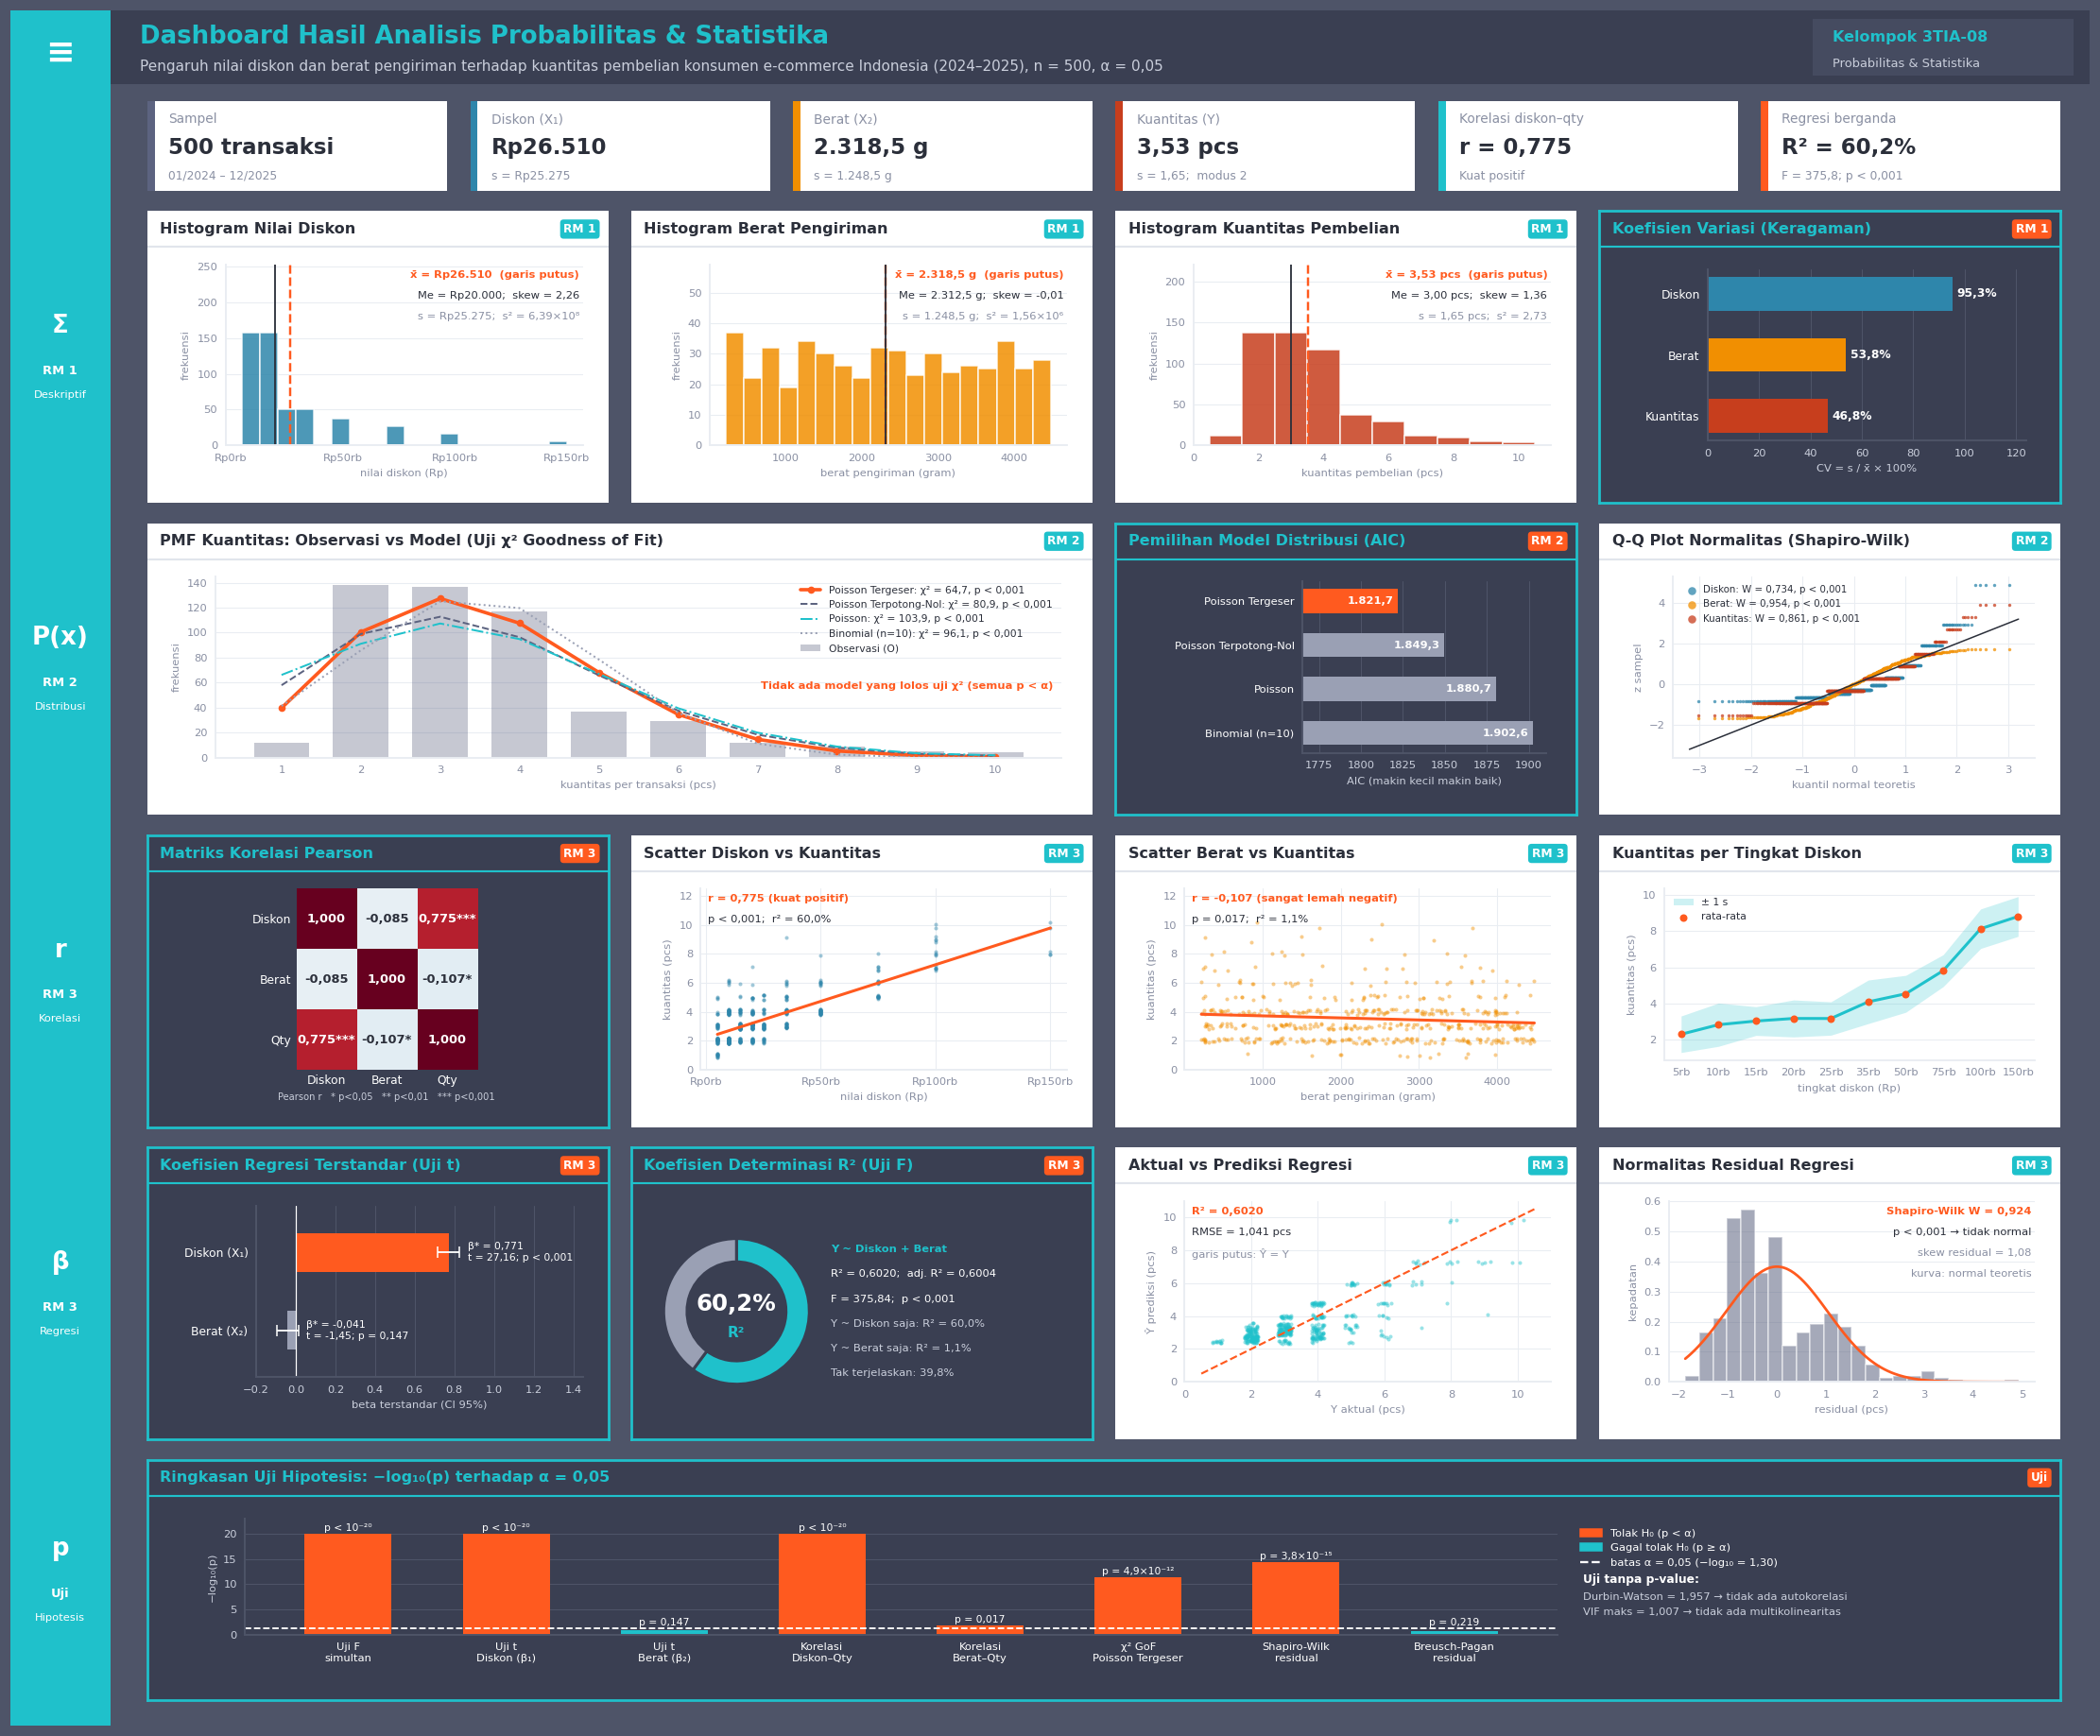

In [ ]:
fig = plt.figure(figsize=(20, 16.5), facecolor=C["bg"])

def kotak(x, y, w, h, warna, bingkai=None, z=1):
    ax = fig.add_axes([x, y, w, h], zorder=z)
    ax.set_facecolor(warna); ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(bingkai is not None)
        if bingkai: s.set_color(bingkai); s.set_linewidth(1.8)
    return ax

X0, LEBAR, G = 0.066, 0.92, 0.011
wkol = (LEBAR - 3 * G) / 4
TH, PAD = 0.021, 0.006                   # tinggi judul kartu dan padding (fraksi tinggi gambar)
y_baris = [0.713, 0.531, 0.349, 0.167, 0.015]; h_baris = [0.17, 0.17, 0.17, 0.17, 0.14]

# ---------- Sidebar: label setiap baris ----------
sb = kotak(0, 0, 0.048, 1, TEAL)
sb.text(0.5, 0.975, "≡", color="white", fontsize=24, ha="center", va="center", fontweight="bold")
for (ikon, rm, nama, _), yb, hb in zip(BARIS, y_baris, h_baris):
    yc = yb + hb / 2
    sb.text(0.5, yc + 0.018, ikon, color="white", fontsize=17, ha="center", va="center", fontweight="bold")
    sb.text(0.5, yc - 0.008, rm, color="white", fontsize=8.5, ha="center", va="center", fontweight="bold")
    sb.text(0.5, yc - 0.022, nama, color="white", fontsize=7.5, ha="center", va="center")

# ---------- Header ----------
hd = kotak(0.048, 0.957, 0.952, 0.043, C["panel"])
hd.text(0.015, 0.64, "Dashboard Hasil Analisis Probabilitas & Statistika", color=TEAL, fontsize=17, fontweight="bold", va="center")
hd.text(0.015, 0.24, f"Pengaruh nilai diskon dan berat pengiriman terhadap kuantitas pembelian konsumen e-commerce Indonesia "
                     f"(2024–2025), n = {n}, α = {idn(ALPHA, 2)}", color="#C9CEDB", fontsize=10, va="center")
hd.add_patch(FancyBboxPatch((0.86, 0.12), 0.132, 0.76, boxstyle="square,pad=0", fc="#454B60", ec="none"))
hd.text(0.87, 0.64, "Kelompok 3TIA-08", color=TEAL, fontsize=10.5, fontweight="bold", va="center")
hd.text(0.87, 0.28, "Probabilitas & Statistika", color="#C9CEDB", fontsize=8.5, va="center")

# ---------- Baris KPI ----------
wk = (LEBAR - 5 * G) / 6
for i, (lbl, nilai, sub, warna) in enumerate(KPI):
    ax = kotak(X0 + i * (wk + G), 0.895, wk, 0.052, C["putih"])
    ax.add_patch(FancyBboxPatch((0, 0), 0.025, 1, boxstyle="square,pad=0", fc=warna, ec="none"))
    ax.text(0.07, 0.8, lbl, color=C["redup"], fontsize=9, va="center")
    ax.text(0.07, 0.48, nilai, color=C["teks"], fontsize=15, fontweight="bold", va="center")
    ax.text(0.07, 0.16, sub, color=C["redup"], fontsize=8, va="center")

# ---------- Kartu grafik ----------
def kartu_png(x, y, w, h, kunci):
    judul, tag, gelap, fungsi, (l, b, r, tp) = KARTU[kunci]
    t = TEMA_GELAP if gelap else TEMA_PUTIH
    bgax = kotak(x, y, w, h, t["bg"], bingkai=TEAL if gelap else None)
    hy = 1 - TH / h
    bgax.axhline(hy, color=TEAL if gelap else "#E1E5EC", lw=1.4)
    bgax.text(PAD / w, 1 - TH / 2 / h, judul, color=TEAL if gelap else C["teks"], fontsize=10.5, fontweight="bold", va="center")
    bgax.text(1 - PAD / w, 1 - TH / 2 / h, tag, color="white", fontsize=8, fontweight="bold", va="center", ha="right",
              bbox=dict(boxstyle="round,pad=0.3", fc=ORANYE if gelap else TEAL, ec="none"))
    cx, cy, cw, ch = x + PAD, y + PAD, w - 2 * PAD, h - TH - 2 * PAD
    ax = fig.add_axes([cx + l * cw, cy + b * ch, (r - l) * cw, (tp - b) * ch], zorder=3)
    fungsi(ax, t)

for (_, _, _, isi_baris), yb, hb in zip(BARIS, y_baris, h_baris):
    kol = 0
    for kunci, span in isi_baris:
        kartu_png(X0 + kol * (wkol + G), yb, span * wkol + (span - 1) * G, hb, kunci)
        kol += span

simpan_gambar(fig, "Dashboard_Hasil_Analisis")
fig.savefig("Dashboard_Analisis_Statistika.png", dpi=300, facecolor=fig.get_facecolor())
print("💾 Tersimpan juga: Dashboard_Analisis_Statistika.png")
plt.show()

### Langkah 8.4 — Dashboard interaktif (bisa diklik seperti web)
Sel ini menyiapkan data setiap kartu untuk dashboard interaktif. Tata letak, warna, judul kartu, dan isi grafiknya **sama dengan dashboard PNG di atas**, tetapi sekarang:

| Fitur | Cara pakai |
|---|---|
| **Tooltip** | Arahkan kursor ke batang / titik / sel untuk melihat nilainya |
| **Perbesar grafik** | Klik judul kartu → tampil besar + penjelasan interpretasi + tombol *Simpan PNG* (tutup dengan ✕ atau tombol Esc) |
| **Legenda interaktif** | Klik item legenda (PMF vs model, Q-Q plot, kuantitas per diskon) untuk menyembunyikan/menampilkan seri |
| **Menu samping** | Klik Σ / P(x) / r / β / p untuk menyaring baris RM 1, RM 2, RM 3, dan Uji; klik ≡ untuk menampilkan semua |
| **Kotak KPI** | Klik kotak KPI untuk loncat ke grafik yang bersangkutan |

> Tidak butuh library tambahan (HTML + SVG + JavaScript murni), jadi aman dijalankan di Colab, Jupyter, maupun VS Code.

In [ ]:
# ===== Langkah 8.4 — Dashboard INTERAKTIF (bisa diklik seperti web) =====
# Dibuat dengan HTML + SVG + JavaScript murni → tidak perlu install library tambahan, jalan di Colab / Jupyter / VS Code.
import json, html as _html
from matplotlib import cm as _cm, colors as _mc
from IPython.display import HTML, display

def _rnd(o):
    if isinstance(o, (float, np.floating)): return None if not np.isfinite(o) else round(float(o), 4)
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, np.ndarray): return [_rnd(v) for v in o.tolist()]
    if isinstance(o, (list, tuple)): return [_rnd(v) for v in o]
    if isinstance(o, dict): return {k: _rnd(v) for k, v in o.items()}
    return o

CH, INFO, LEG, TINGGI = {}, {}, {}, {}
def _pad(a, b, p=0.03): return [a - (b - a) * p, b + (b - a) * p]
def _rpf(v): return f"Rp{idn(v, 0)}"
FMT_TIP = {X1: _rpf, X2: lambda v: f"{idn(v, 0)} g", Y: lambda v: f"{idn(v, 0)} pcs"}
def _bentuk(s): return "menceng kanan" if s > 0.5 else "menceng kiri" if s < -0.5 else "hampir simetris"

# ---------- RM 1: histogram ----------
def spec_hist(k):
    x = df[k]; diskrit = k == Y
    edges = np.arange(x.min() - 0.5, x.max() + 1.5, 1) if diskrit else np.histogram_bin_edges(x, bins=18)
    cnt, ed = np.histogram(x, bins=edges)
    mk = []
    for c_, a, b in zip(cnt, ed[:-1], ed[1:]):
        rentang = f"{int(round((a + b) / 2))} pcs" if diskrit else f"{FMT_TIP[k](a)} – {FMT_TIP[k](b)}"
        mk.append({"t": "r", "x0": a, "x1": b, "y0": 0, "y1": c_, "f": WARNA_VAR[k], "o": .85, "s": 1,
                   "tip": f"{rentang}: {c_} transaksi ({idn(c_ / n * 100, 1)}%)"})
    mk += [{"t": "v", "x": x.mean(), "c": ORANYE, "d": "5 4", "w": 1.8}, {"t": "v", "x": x.median(), "c": "@fg", "w": 1.3}]
    f = {X1: lambda v: f"Rp{idn(v, 0)}", X2: lambda v: f"{idn(v, 1)} g", Y: lambda v: f"{idn(v, 2)} pcs"}[k]
    s2 = x.var(); s2t = ilmiah(s2) if s2 > 1e5 else idn(s2)
    CH[{X1: "hist_dsk", X2: "hist_brt", Y: "hist_qty"}[k]] = {
        "xd": _pad(ed[0], ed[-1]), "yd": [0, cnt.max() * 1.6], "xf": "rp" if k == X1 else None, "xl": LABEL_SUMBU[k], "yl": "frekuensi", "marks": mk,
        "notes": {"pos": "tr", "lines": [[f"x̄ = {f(x.mean())}  (garis putus)", ORANYE], [f"Me = {f(x.median())};  skew = {idn(x.skew())}", "@fg"],
                                          [f"s = {f(x.std())};  s² = {s2t}", "@sub"]]}}
    INFO[{X1: "hist_dsk", X2: "hist_brt", Y: "hist_qty"}[k]] = (
        f"Rata-rata {f(x.mean())} vs median {f(x.median())} → distribusi {_bentuk(x.skew())} (skewness {idn(x.skew())}). "
        f"Deviasi standar {f(x.std())}, CV = {idn(x.std() / x.mean() * 100, 1)}%.")
for _k in VAR_UTAMA: spec_hist(_k)

# ---------- RM 1: koefisien variasi ----------
cvv = [td.loc["Koef. Variasi (%)", LABEL[k]] for k in VAR_UTAMA]
CH["cv"] = {"xd": [0, max(cvv) * 1.3], "yd": [-0.6, 2.6], "ml": 70, "ycat": 1, "xl": "CV = s / x̄ × 100%", "yt": [{"v": 2 - i, "l": NAMA_PENDEK[k]} for i, k in enumerate(VAR_UTAMA)],
            "marks": [m for i, (k, v) in enumerate(zip(VAR_UTAMA, cvv)) for m in (
                {"t": "r", "x0": 0, "x1": v, "y0": 2 - i - .27, "y1": 2 - i + .27, "f": WARNA_VAR[k], "tip": f"{LABEL[k]}: CV = {idn(v, 2)}%"},
                {"t": "x", "x": v + max(cvv) * .02, "y": 2 - i - .05, "s": f"{idn(v, 1)}%", "c": "@fg", "z": 12, "a": "start", "b": 1})]}
INFO["cv"] = f"Variabel paling heterogen: {NAMA_PENDEK[VAR_UTAMA[int(np.argmax(cvv))]]} (CV {idn(max(cvv), 1)}%); paling homogen: {NAMA_PENDEK[VAR_UTAMA[int(np.argmin(cvv))]]} (CV {idn(min(cvv), 1)}%)."

# ---------- RM 2: PMF vs model ----------
lain = iter([("#9AA0B4", "5 4"), (TEAL, "6 3 1 3"), ("#C9CEDB", "1.5 3")])
mk = [{"t": "r", "x0": a - .35, "x1": a + .35, "y0": 0, "y1": b, "f": "@netral", "o": .35, "g": "obs",
       "tip": f"k = {int(a)} pcs · observasi {int(b)} transaksi ({idn(b / n * 100, 1)}%)"} for a, b in zip(nilai_k, frek)]
leg = [{"l": "Observasi (O)", "c": "@netral", "g": "obs"}]
for _, r in tabel_fit.iterrows():
    best = r["Model"] == MODEL_TERBAIK; warna, dash = (ORANYE, None) if best else next(lain); nm = r["Model"]
    mk.append({"t": "l", "pts": [[a, b] for a, b in zip(nilai_k, harapan[nm])], "c": warna, "w": 2.8 if best else 1.6, "d": dash, "g": nm})
    mk += [{"t": "p", "x": a, "y": b, "r": 4 if best else 2.5, "c": warna, "g": nm, "tip": f"{nm} · k = {int(a)}: harapan {idn(b, 1)} (observasi {int(o_)})"}
           for a, b, o_ in zip(nilai_k, harapan[nm], frek)]
    leg.append({"l": f"{nm}: χ² = {idn(r['χ² hitung'], 1)}, {pval(r['p-value'])}", "c": warna, "g": nm, "d": dash})
lolos = tabel_fit.loc[tabel_fit["p-value"] > ALPHA, "Model"].tolist()
CH["fit"] = {"xd": [0.4, nilai_k.max() + .6], "yd": [0, max(frek.max(), max(v.max() for v in harapan.values())) * 1.15], "xt": [{"v": int(v), "l": str(int(v))} for v in nilai_k],
             "xl": "kuantitas per transaksi (pcs)", "yl": "frekuensi", "marks": mk,
             "notes": {"pos": "tr", "lines": [[("Lolos uji χ²: " + ", ".join(lolos)) if lolos else "Tidak ada model yang lolos uji χ² (semua p < α)", ORANYE]]}}
LEG["fit"] = leg
INFO["fit"] = ("Klik legenda untuk menampilkan/menyembunyikan model. " + (f"Model yang lolos uji χ² (p > 0,05): {', '.join(lolos)}." if lolos else
               "Tidak ada model diskrit tunggal yang lolos uji χ² pada α = 0,05; distribusi keseluruhan merupakan campuran beberapa kelompok diskon (lihat Langkah 3.7)."))

# ---------- RM 2: AIC ----------
tf = tabel_fit.sort_values("AIC"); rg = tf["AIC"].max() - tf["AIC"].min(); xd_aic = [tf["AIC"].min() - rg * .7, tf["AIC"].max() + rg * .1]
CH["aic"] = {"xd": xd_aic, "yd": [-0.6, len(tf) - 0.4], "ml": 124, "ycat": 1, "grid": "x", "xl": "AIC (makin kecil makin baik)",
             "yt": [{"v": len(tf) - 1 - i, "l": m} for i, m in enumerate(tf["Model"])],
             "marks": [m for i, (nm, v) in enumerate(zip(tf["Model"], tf["AIC"])) for m in (
                 {"t": "r", "x0": xd_aic[0], "x1": v, "y0": len(tf) - 1 - i - .27, "y1": len(tf) - 1 - i + .27, "f": ORANYE if nm == MODEL_TERBAIK else "@netral",
                  "tip": f"{nm}: AIC = {idn(v, 2)}"},
                 {"t": "x", "x": v - rg * .03, "y": len(tf) - 1 - i - .06, "s": idn(v, 1), "c": "#FFFFFF", "z": 11, "a": "end", "b": 1})]}
INFO["aic"] = f"AIC terkecil = model terbaik: {MODEL_TERBAIK} (AIC {idn(tf['AIC'].min(), 1)}). Selisih dengan model terburuk {idn(rg, 1)} poin."

# ---------- RM 2: Q-Q ----------
teo = stats.norm.ppf((np.arange(1, n + 1) - 0.375) / (n + 0.25)); mk, leg, zmin, zmax = [], [], 0, 0
for k in VAR_UTAMA:
    z = np.sort((df[k] - df[k].mean()) / df[k].std()); zmin, zmax = min(zmin, z.min()), max(zmax, z.max())
    bar = tabel_norm[tabel_norm["Variabel"] == LABEL[k]].iloc[0]
    mk += [{"t": "p", "x": a, "y": b, "r": 2, "c": WARNA_VAR[k], "o": .75, "g": k, "tip": f"{NAMA_PENDEK[k]}: kuantil teoretis {idn(a)}, z sampel {idn(b)}"} for a, b in zip(teo, z)]
    leg.append({"l": f"{NAMA_PENDEK[k]}: W = {idn(bar['Shapiro-Wilk W'], 3)}, {pval(bar['p (SW)'])}", "c": WARNA_VAR[k], "g": k})
mk.insert(0, {"t": "l", "pts": [[-3.4, -3.4], [3.4, 3.4]], "c": "@fg", "w": 1.2})
CH["qq"] = {"xd": [-3.4, 3.4], "yd": [zmin - .3, zmax + .3], "grid": "both", "xl": "kuantil normal teoretis", "yl": "z sampel", "marks": mk}
LEG["qq"] = leg
INFO["qq"] = "Titik yang mengikuti garis diagonal = data normal. " + "; ".join(f"{NAMA_PENDEK[k]}: {r_['Kesimpulan'].lower()} ({pval(r_['p (SW)'])})" for k, (_, r_) in zip(VAR_UTAMA, tabel_norm.iterrows())) + "."

# ---------- RM 3: heatmap korelasi ----------
mat = df[VAR_UTAMA].corr(); nm3 = ["Diskon", "Berat", "Qty"]; mk = []
for i in range(3):
    for j in range(3):
        r = mat.iloc[i, j]; bt = ""; pp = None
        if i != j:
            pp = stats.pearsonr(df[VAR_UTAMA[i]], df[VAR_UTAMA[j]]).pvalue; bt = "***" if pp < .001 else "**" if pp < .01 else "*" if pp < .05 else ""
        fill = _mc.to_hex(_cm.RdBu_r((r + 1) / 2))
        mk += [{"t": "r", "x0": j - .5, "x1": j + .5, "y0": 2 - i - .5, "y1": 2 - i + .5, "f": fill, "s": 1,
                "tip": f"{nm3[i]} ↔ {nm3[j]}: r = {idn(r, 3)}" + (f", {pval(pp)}" if pp is not None else "")},
               {"t": "x", "x": j, "y": 2 - i - .05, "s": f"{idn(r, 3)}{bt}", "c": "#FFFFFF" if abs(r) > .5 else "#2B2F3A", "z": 13, "a": "middle", "b": 1}]
CH["heat"] = {"xd": [-.5, 2.5], "yd": [-.5, 2.5], "ml": 48, "grid": "none", "ycat": 1, "xcat": 1, "xt": [{"v": i, "l": nm3[i]} for i in range(3)],
              "yt": [{"v": 2 - i, "l": nm3[i]} for i in range(3)], "xl": "Pearson r   * p<0,05   ** p<0,01   *** p<0,001", "marks": mk}
INFO["heat"] = (f"Diskon–Qty r = {idn(mat.iloc[0, 2], 3)} ({kekuatan(mat.iloc[0, 2])}); Berat–Qty r = {idn(mat.iloc[1, 2], 3)} ({kekuatan(mat.iloc[1, 2])}); "
                f"Diskon–Berat r = {idn(mat.iloc[0, 1], 3)} ({kekuatan(mat.iloc[0, 1])}).")

# ---------- RM 3: scatter ----------
for xv, key in [(X1, "sc_dsk"), (X2, "sc_brt")]:
    bb1, bb0 = np.polyfit(df[xv], df[Y], 1); xx = np.array([df[xv].min(), df[xv].max()])
    r = df[xv].corr(df[Y]); p = stats.pearsonr(df[xv], df[Y]).pvalue
    mk = [{"t": "p", "x": a, "y": b + j_, "r": 2.6, "c": WARNA_VAR[xv], "o": .45, "tip": f"{NAMA_PENDEK[xv]}: {FMT_TIP[xv](a)} · kuantitas {int(b)} pcs"}
          for a, b, j_ in zip(df[xv], df[Y], JITTER)]
    mk.append({"t": "l", "pts": [[a, bb0 + bb1 * a] for a in xx], "c": ORANYE, "w": 2.4})
    CH[key] = {"xd": _pad(xx[0], xx[1]), "yd": [0, 12.5], "xf": "rp" if xv == X1 else None, "grid": "both", "xl": LABEL_SUMBU[xv], "yl": "kuantitas (pcs)", "marks": mk,
               "notes": {"pos": "tl", "lines": [[f"r = {idn(r, 3)} ({kekuatan(r).lower()})", ORANYE], [f"{pval(p)};  r² = {idn(r ** 2 * 100, 1)}%", "@fg"]]}}
    INFO[key] = f"r = {idn(r, 3)} ({kekuatan(r)}), {pval(p)}. {NAMA_PENDEK[xv]} menjelaskan {idn(r ** 2 * 100, 1)}% variasi kuantitas pada regresi sederhana. Titik digeser acak sedikit (jitter) agar tidak menumpuk."

# ---------- RM 3: kuantitas per tingkat diskon ----------
m_, s_ = per_diskon["Rata-rata Qty"].to_numpy(), per_diskon["Std"].fillna(0).to_numpy(); xs = np.arange(len(per_diskon))
CH["qty_dsk"] = {"xd": [-.4, len(xs) - .6], "yd": [max(0, (m_ - s_).min() - .3), (m_ + s_).max() + .3], "xl": "tingkat diskon (Rp)", "yl": "kuantitas (pcs)", "ml": 40,
                 "xt": [{"v": int(i), "l": f"{v / 1000:,.0f}rb"} for i, v in zip(xs, per_diskon.index)],
                 "marks": [{"t": "b", "xs": xs, "lo": m_ - s_, "hi": m_ + s_, "c": TEAL, "o": .22, "g": "band"}, {"t": "l", "pts": [[a, b] for a, b in zip(xs, m_)], "c": TEAL, "w": 2.2}] +
                          [{"t": "p", "x": a, "y": b, "r": 4, "c": ORANYE, "g": "mean", "tip": f"Diskon {_rpf(v)}: n = {int(nn)}, rata-rata {idn(b, 2)} pcs, s = {idn(sd, 2)}"}
                           for a, b, v, nn, sd in zip(xs, m_, per_diskon.index, per_diskon["n"], s_)]}
LEG["qty_dsk"] = [{"l": "± 1 s", "c": TEAL, "g": "band"}, {"l": "rata-rata", "c": ORANYE, "g": "mean"}]
INFO["qty_dsk"] = f"Rata-rata kuantitas naik dari {idn(m_[0], 2)} pcs (diskon terendah) menjadi {idn(m_[-1], 2)} pcs (diskon tertinggi); tiap tingkat diskon punya rata-rata berbeda."

# ---------- RM 3: regresi ----------
sx, sy = df[[X1, X2]].std(), df[Y].std(); ci = model.conf_int().loc[[X1, X2]]
lo, hi = (ci[0] * sx / sy).values, (ci[1] * sx / sy).values; bs = beta_std.values; mk = []
for yy, bi, l_, h_, k, nmk in zip([1, 0], bs, lo, hi, [X1, X2], ["Diskon (X₁)", "Berat (X₂)"]):
    sig = model.pvalues[k] < ALPHA
    mk += [{"t": "r", "x0": 0, "x1": bi, "y0": yy - .25, "y1": yy + .25, "f": ORANYE if sig else "@netral", "tip": f"{nmk}: β* = {idn(bi, 3)}; CI 95% [{idn(l_, 3)}; {idn(h_, 3)}]"},
           {"t": "e", "y": yy, "lo": l_, "hi": h_, "c": "@fg"},
           {"t": "x", "x": max(bi, h_) + .04, "y": yy + .05, "s": f"β* = {idn(bi, 3)}\nt = {idn(model.tvalues[k], 2)}; {pval(model.pvalues[k])}", "c": "@fg", "z": 10, "a": "start"}]
CH["beta"] = {"xd": [-.2, 1.5], "yd": [-.6, 1.6], "ml": 78, "ycat": 1, "grid": "x", "xl": "beta terstandar (CI 95%)", "yt": [{"v": 1, "l": "Diskon (X₁)"}, {"v": 0, "l": "Berat (X₂)"}], "marks": mk}
INFO["beta"] = (f"Diskon: β* = {idn(bs[0], 3)} ({'signifikan' if model.pvalues[X1] < ALPHA else 'tidak signifikan'}); Berat: β* = {idn(bs[1], 3)} "
                f"({'signifikan' if model.pvalues[X2] < ALPHA else 'tidak signifikan'}). Pengaruh terbesar: {'Diskon' if abs(bs[0]) > abs(bs[1]) else 'Berat'}.")

R2 = model.rsquared
CH["r2"] = {"type": "donut", "val": R2, "c": TEAL,
            "lines": [["Y ~ Diskon + Berat", TEAL], [f"R² = {idn(R2, 4)};  adj. R² = {idn(model.rsquared_adj, 4)}", "@fg"], [f"F = {idn(model.fvalue, 2)};  {pval(model.f_pvalue)}", "@fg"],
                      [f"Y ~ Diskon saja: R² = {idn(model_x1.rsquared * 100, 1)}%", "@sub"], [f"Y ~ Berat saja: R² = {idn(model_x2.rsquared * 100, 1)}%", "@sub"],
                      [f"Tak terjelaskan: {idn((1 - R2) * 100, 1)}%", "@sub"]], "tip1": f"Dijelaskan model: {idn(R2 * 100, 2)}%", "tip2": f"Tak terjelaskan: {idn((1 - R2) * 100, 2)}%"}
TINGGI["r2"] = 260
INFO["r2"] = f"{idn(R2 * 100, 1)}% variasi kuantitas dijelaskan bersama oleh diskon dan berat; sisanya {idn((1 - R2) * 100, 1)}% oleh faktor lain. Uji F: {pval(model.f_pvalue)} → model signifikan."

rmse = np.sqrt(np.mean(resid ** 2))
CH["pred"] = {"xd": [.3, 10.7], "yd": [min(fitted.min(), .5) - .3, max(fitted.max(), 10.5) + .3], "grid": "both", "xl": "Y aktual (pcs)", "yl": "Ŷ prediksi (pcs)",
              "marks": [{"t": "p", "x": a + j_, "y": b, "r": 2.6, "c": TEAL, "o": .45, "tip": f"Aktual {int(a)} pcs · prediksi {idn(b, 2)} pcs"} for a, b, j_ in zip(df[Y], fitted, JITTER)] +
                       [{"t": "l", "pts": [[.5, .5], [10.5, 10.5]], "c": ORANYE, "d": "5 4", "w": 1.6}],
              "notes": {"pos": "tl", "lines": [[f"R² = {idn(R2, 4)}", ORANYE], [f"RMSE = {idn(rmse, 3)} pcs", "@fg"], ["garis putus: Ŷ = Y", "@sub"]]}}
INFO["pred"] = f"Makin dekat titik ke garis putus (Ŷ = Y), makin akurat prediksi. RMSE = {idn(rmse, 3)} pcs; R² = {idn(R2, 4)}."

cnt, ed = np.histogram(resid, bins=24, density=True); xs_ = np.linspace(resid.min(), resid.max(), 120); pdf_ = stats.norm.pdf(xs_, 0, resid.std())
CH["resid"] = {"xd": _pad(ed[0], ed[-1]), "yd": [0, max(cnt.max(), pdf_.max()) * 1.6], "xl": "residual (pcs)", "yl": "kepadatan", "ml": 40,
               "marks": [{"t": "r", "x0": a, "x1": b, "y0": 0, "y1": c_, "f": "@netral", "o": .55, "s": 1, "tip": f"residual {idn(a, 2)} s.d. {idn(b, 2)}: kepadatan {idn(c_, 3)}"} for c_, a, b in zip(cnt, ed[:-1], ed[1:])] +
                        [{"t": "l", "pts": [[a, b] for a, b in zip(xs_, pdf_)], "c": ORANYE, "w": 2}],
               "notes": {"pos": "tr", "lines": [[f"Shapiro-Wilk W = {idn(sw_r.statistic, 3)}", ORANYE], [f"{pval(sw_r.pvalue)} → {'normal' if sw_r.pvalue > ALPHA else 'tidak normal'}", "@fg"],
                                                 [f"skew residual = {idn(pd.Series(resid).skew())}", "@sub"], ["kurva oranye: normal teoretis", "@sub"]]}}
INFO["resid"] = f"Residual {'berdistribusi normal' if sw_r.pvalue > ALPHA else 'tidak berdistribusi normal'} (Shapiro-Wilk {pval(sw_r.pvalue)}). Breusch-Pagan {pval(bp[1])} → {'homoskedastis' if bp[1] > ALPHA else 'terindikasi heteroskedastis'}."

# ---------- Uji hipotesis ----------
BATAS = 20; nl = [min(-np.log10(max(p, 1e-300)), BATAS) for _, p in UJI_P]; mk = []
for i, ((nm, p), v) in enumerate(zip(UJI_P, nl)):
    lbl = f"p < 10{str(-BATAS).translate(SUP)}" if v >= BATAS else ("p = " + ilmiah(p, 1) if p < .001 else pval(p))
    mk += [{"t": "r", "x0": i - .27, "x1": i + .27, "y0": 0, "y1": v, "f": ORANYE if p < ALPHA else TEAL, "tip": f"{nm.replace(chr(10), ' ')}: {pval(p)} → {'Tolak H₀' if p < ALPHA else 'Gagal tolak H₀'}"},
           {"t": "x", "x": i, "y": max(v, -np.log10(ALPHA)) + 1.2, "s": lbl, "c": "@fg", "z": 10, "a": "middle"}]
mk.append({"t": "h", "y": -np.log10(ALPHA), "c": "@fg", "d": "5 4", "w": 1.3})
vif_max = max(vif.values())
CH["pval"] = {"xd": [-.6, len(UJI_P) - .4], "yd": [0, BATAS * 1.15], "ml": 44, "mb": 48, "xl": None, "yl": "−log₁₀(p)", "xt": [{"v": i, "l": u} for i, (u, _) in enumerate(UJI_P)], "marks": mk,
              "notes": {"pos": "tr", "lines": [["Uji tanpa p-value:", "@fg"], [f"Durbin-Watson = {idn(dw, 3)} → {'tidak ada autokorelasi' if 1.5 < dw < 2.5 else 'ada autokorelasi'}", "@sub"],
                                               [f"VIF maks = {idn(vif_max, 3)} → {'tidak ada multikolinearitas' if vif_max < 10 else 'multikolinearitas'}", "@sub"]]}}
LEG["pval"] = [{"l": "Tolak H₀ (p < α)", "c": ORANYE}, {"l": "Gagal tolak H₀ (p ≥ α)", "c": TEAL}, {"l": "batas α = 0,05 (−log₁₀ = 1,30)", "c": "@fg", "d": "5 4"}]
TINGGI["pval"] = 280
INFO["pval"] = f"Batang di atas garis putus = tolak H₀ pada α = 0,05. {sum(p < ALPHA for _, p in UJI_P)} dari {len(UJI_P)} uji menolak H₀; sisanya gagal tolak H₀."

# ---------- Rakit data dashboard ----------
TARGET_KPI = [None, "hist_dsk", "hist_brt", "hist_qty", "sc_dsk", "r2"]
DATA = {"judul": "Dashboard Hasil Analisis Probabilitas & Statistika",
        "sub": f"Pengaruh nilai diskon dan berat pengiriman terhadap kuantitas pembelian konsumen e-commerce Indonesia (2024–2025), n = {n}, α = {idn(ALPHA, 2)}",
        "kelompok": "Kelompok 3TIA-08", "mk": "Probabilitas & Statistika",
        "kpi": [{"l": a, "v": b, "s": c_, "c": d, "t": t_} for (a, b, c_, d), t_ in zip(KPI, TARGET_KPI)],
        "rows": [{"ikon": ik, "rm": rm, "nama": nmr, "cards": [{"k": k, "span": sp} for k, sp in cs]} for ik, rm, nmr, cs in BARIS],
        "cards": {k: {"title": KARTU[k][0], "tag": KARTU[k][1], "dark": KARTU[k][2], "spec": CH[k], "legend": LEG.get(k, []), "info": INFO.get(k, ""), "h": TINGGI.get(k, 236)} for k in KARTU}}

### Langkah 8.5 — Tampilkan dashboard dan simpan sebagai file HTML
Dashboard tampil langsung di bawah sel ini. File `Dashboard_Interaktif_Analisis_Statistika.html` juga tersimpan: **buka dengan browser** (klik dua kali) untuk tampilan layar penuh, atau lampirkan saat presentasi/pengumpulan tugas. Di Colab, unduh lewat panel *Files* di sebelah kiri.

In [ ]:
# ===== Langkah 8.5 — Tampilkan dashboard interaktif & simpan sebagai file HTML =====
TEMPLATE = r'''<!DOCTYPE html><html lang="id"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1">
<title>Dashboard Analisis Statistika</title>
<style>
:root{--teal:#1FC1CB;--or:#FF5A1F;--bg:#4E5468;--panel:#3A3F52;--redup:#8A90A3;--teks:#2B2F3A}
*{box-sizing:border-box}html,body{margin:0}
body{background:var(--bg);font-family:"Segoe UI",system-ui,Roboto,Arial,sans-serif;color:#fff}
.app{display:flex;min-height:100vh}
.side{width:78px;flex:none;background:var(--teal)}
.sticky{position:sticky;top:0;display:flex;flex-direction:column;align-items:center;gap:6px;padding:12px 4px}
.side button{width:68px;border:0;background:transparent;color:#fff;cursor:pointer;border-radius:8px;padding:12px 2px;font-family:inherit;transition:.15s}
.side button:hover{background:rgba(255,255,255,.18)}.side button.on{background:rgba(0,0,0,.22);box-shadow:inset 3px 0 0 #fff}
.side .ik{display:block;font-size:20px;font-weight:700}.side .rm{display:block;font-size:11px;font-weight:700;margin-top:4px}.side .nm{display:block;font-size:10px;opacity:.9}
.main{flex:1;min-width:0;padding:12px 14px 20px}
.hdr{background:var(--panel);padding:14px 20px;display:flex;gap:16px;align-items:center;justify-content:space-between;flex-wrap:wrap}
.hdr h1{margin:0;font-size:24px;color:var(--teal)}.hdr p{margin:6px 0 0;font-size:12.5px;color:#C9CEDB}
.grp{background:#454B60;padding:10px 16px;font-size:12px;color:#C9CEDB}.grp b{display:block;color:var(--teal);font-size:14px;margin-bottom:3px}
.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:10px;margin:12px 0}
.kpi{background:#fff;color:var(--teks);padding:10px 12px 10px 16px;position:relative;cursor:pointer;transition:.15s;border-radius:2px}
.kpi:hover{transform:translateY(-3px);box-shadow:0 6px 16px rgba(0,0,0,.35)}.kpi i{position:absolute;left:0;top:0;bottom:0;width:5px}
.kpi small{display:block;color:var(--redup);font-size:11.5px}.kpi b{display:block;font-size:20px;margin:3px 0}.kpi span{font-size:11px;color:var(--redup)}
.row{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:12px}
.s1{grid-column:span 1}.s2{grid-column:span 2}.s4{grid-column:span 4}
.card{background:#fff;color:var(--teks);min-width:0;display:flex;flex-direction:column;border-radius:2px;transition:box-shadow .2s}
.card.dark{background:var(--panel);color:#fff;outline:2px solid var(--teal);outline-offset:-2px}
.card:hover{box-shadow:0 6px 18px rgba(0,0,0,.35)}.card.flash{animation:fl 1.4s}
@keyframes fl{0%,60%{box-shadow:0 0 0 4px var(--or),0 0 24px var(--or)}100%{box-shadow:none}}
.ch{display:flex;align-items:center;gap:8px;padding:8px 10px;border-bottom:1.5px solid #E1E5EC;cursor:pointer}
.dark .ch{border-color:var(--teal)}.ch h3{margin:0;font-size:13px;flex:1;line-height:1.25}.dark .ch h3{color:var(--teal)}
.tag{background:var(--teal);color:#fff;font-size:10.5px;font-weight:700;padding:2px 7px;border-radius:4px}.dark .tag{background:var(--or)}
.ex{border:0;background:transparent;font-size:15px;cursor:pointer;color:inherit;opacity:.55;padding:0 2px}.ch:hover .ex{opacity:1;color:var(--or)}
.plot{padding:4px 6px 0;height:var(--h)}.plot svg{display:block;max-width:100%}
.leg{display:flex;flex-wrap:wrap;gap:4px 12px;padding:2px 10px 8px;font-size:11px}
.chip{cursor:default;display:inline-flex;align-items:center;gap:5px;user-select:none}.chip[data-g]{cursor:pointer}.chip.off{opacity:.3;text-decoration:line-through}
.chip i{width:14px;height:8px;border-radius:2px;display:inline-block}.chip i.ln{height:0;border-top:2.5px solid;border-radius:0}
.m{transition:opacity .1s}.m[data-t]:hover{stroke:#fff;stroke-width:1.6;filter:brightness(1.12)}
#tip{position:fixed;z-index:60;pointer-events:none;background:#14161d;color:#fff;font-size:12px;padding:6px 9px;border-radius:5px;border:1px solid var(--teal);display:none;max-width:290px;box-shadow:0 4px 14px rgba(0,0,0,.4)}
#ov{position:fixed;inset:0;background:rgba(15,17,25,.72);display:none;align-items:center;justify-content:center;z-index:50;padding:16px}
#ov.on{display:flex}.mb{width:min(1180px,96vw);max-height:94vh;overflow:auto;border-radius:6px;display:flex;flex-direction:column;background:#fff;color:var(--teks)}
.mb.dark{background:var(--panel);color:#fff;outline:2px solid var(--teal)}
.mh{display:flex;align-items:center;gap:10px;padding:12px 16px;border-bottom:1.5px solid #E1E5EC}.mb.dark .mh{border-color:var(--teal)}
.mh h2{margin:0;font-size:17px;flex:1}.mb.dark .mh h2{color:var(--teal)}
.mh button{border:0;border-radius:5px;padding:6px 11px;cursor:pointer;font-size:12.5px;font-family:inherit;background:var(--teal);color:#fff}.mh .x{background:var(--or);font-size:15px}
#mp{padding:8px 14px}.mi{padding:10px 18px 16px;font-size:13.5px;line-height:1.55;border-top:1px solid rgba(128,128,128,.25)}.mi b{color:var(--or)}
.foot{font-size:11px;color:#C9CEDB;text-align:center;margin-top:4px}
@media(max-width:1100px){.row{grid-template-columns:repeat(2,1fr)}.s1,.s2,.s4{grid-column:span 2}.s1{grid-column:span 1}}
@media(max-width:640px){.row{grid-template-columns:1fr}.s1,.s2,.s4{grid-column:span 1 !important}.side{width:56px}.side button{width:50px}.hdr h1{font-size:18px}}
</style></head><body>
<div class="app"><nav class="side"><div class="sticky" id="side"></div></nav>
<div class="main"><header class="hdr"><div><h1 id="jd"></h1><p id="sb"></p></div><div class="grp" id="gp"></div></header>
<div class="kpis" id="kpis"></div><div id="rows"></div>
<div class="foot">💡 Klik kartu untuk memperbesar · arahkan kursor ke grafik untuk melihat nilai · klik legenda untuk menyembunyikan seri · klik menu di kiri untuk menyaring baris · klik kotak KPI untuk loncat ke grafiknya</div></div></div>
<div id="ov"><div class="mb" id="mb"><div class="mh"><h2 id="mt"></h2><button id="dl">⬇ Simpan PNG</button><button class="x" id="cl">✕</button></div><div id="mp"></div><div class="leg" id="ml"></div><div class="mi" id="mi"></div></div></div>
<div id="tip"></div>
<script>
const D=__DATA__;
const TL={fg:'#2B2F3A',sub:'#8A90A3',grid:'#E9EDF2',netral:'#5C6380',bg:'#FFFFFF'},TD={fg:'#FFFFFF',sub:'#C9CEDB',grid:'#4E5468',netral:'#9AA0B4',bg:'#3A3F52'};
const nf=new Intl.NumberFormat('id-ID',{maximumFractionDigits:2});let UID=0;const HID={};
const $=s=>document.querySelector(s);
const esc=s=>String(s).replace(/&/g,'&amp;').replace(/</g,'&lt;').replace(/>/g,'&gt;').replace(/"/g,'&quot;');
const fmt=(v,f)=>f==='rp'?'Rp'+Math.round(v/1000)+'rb':nf.format(+v.toPrecision(10));
function nice(a,b,n){const raw=(b-a)/n,p=Math.pow(10,Math.floor(Math.log10(raw))),f=raw/p,st=(f<1.5?1:f<3?2:f<7?5:10)*p,o=[];for(let v=Math.ceil(a/st-1e-9)*st;v<=b+1e-9;v+=st)o.push(+v.toPrecision(12));return o}
function txt(x,y,s,c,z,a,bold,ex){const L=String(s).split('\n');return `<text x="${x}" y="${y}" fill="${c}" font-size="${z}" text-anchor="${a}"${bold?' font-weight="700"':''} ${ex||''}>`+L.map((l,i)=>`<tspan x="${x}" dy="${i?z*1.25:0}">${esc(l)}</tspan>`).join('')+'</text>'}
const FF='Segoe UI,Roboto,Arial,sans-serif';
function head(w,h,id,clip){return `<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 ${w} ${h}" width="${w}" height="${h}" font-family="${FF}">`+(clip?`<defs><clipPath id="${id}"><rect x="${clip[0]}" y="${clip[1]}" width="${clip[2]}" height="${clip[3]}"/></clipPath></defs>`:'')}
function donut(S,w,h,th,col){
  const r=Math.max(30,Math.min(w*.25,(h-110)/2,110)),cx=w/2,cy=r+12,sw=r*.34,rr=r-sw/2,C=2*Math.PI*rr;
  let o=head(w,h);
  o+=`<circle class="m" cx="${cx}" cy="${cy}" r="${rr}" fill="none" stroke="${th.netral}" stroke-opacity=".55" stroke-width="${sw}" data-t="${esc(S.tip2)}"/>`;
  o+=`<circle class="m" cx="${cx}" cy="${cy}" r="${rr}" fill="none" stroke="${col(S.c)}" stroke-width="${sw}" stroke-dasharray="${S.val*C} ${C}" transform="rotate(-90 ${cx} ${cy})" data-t="${esc(S.tip1)}"/>`;
  o+=txt(cx,cy+r*.05,nf.format(+(S.val*100).toFixed(1))+'%',th.fg,Math.max(14,r*.36),'middle',1);
  o+=txt(cx,cy+r*.42,'R²',col(S.c),Math.max(11,r*.2),'middle',1);
  const z=Math.max(11,Math.min(13,w/32)),y0=cy+r+24;
  S.lines.forEach((l,i)=>o+=txt(cx,y0+i*(z*1.35),l[0],col(l[1]),z,'middle',i===0));
  return o+'</svg>'}
function render(S,w,h,dark,hid){
  const th=dark?TD:TL,col=c=>(c&&c[0]==='@')?th[c.slice(1)]:c;
  if(S.type==='donut')return donut(S,w,h,th,col);
  const ml=S.ml??46,mr=14,mt=10,mb=S.mb??(S.xl?40:26),pw=Math.max(40,w-ml-mr),ph=Math.max(40,h-mt-mb);
  const [x0,x1]=S.xd,[y0,y1]=S.yd,X=v=>ml+(v-x0)/(x1-x0)*pw,Y=v=>mt+ph-(v-y0)/(y1-y0)*ph,id='c'+(++UID);
  let o=head(w,h,id,[ml,mt,pw,ph]);
  const xt=S.xt||nice(x0,x1,Math.max(3,Math.round(pw/85))).map(v=>({v,l:fmt(v,S.xf)})),yt=S.yt||nice(y0,y1,5).map(v=>({v,l:fmt(v,S.yf)}));
  const gr=S.grid===undefined?'y':S.grid;
  if(gr==='y'||gr==='both')yt.forEach(t=>o+=`<line x1="${ml}" x2="${ml+pw}" y1="${Y(t.v)}" y2="${Y(t.v)}" stroke="${th.grid}"/>`);
  if(gr==='x'||gr==='both')xt.forEach(t=>o+=`<line y1="${mt}" y2="${mt+ph}" x1="${X(t.v)}" x2="${X(t.v)}" stroke="${th.grid}"/>`);
  if(gr!=='none')o+=`<line x1="${ml}" x2="${ml}" y1="${mt}" y2="${mt+ph}" stroke="${th.grid}"/><line x1="${ml}" x2="${ml+pw}" y1="${mt+ph}" y2="${mt+ph}" stroke="${th.grid}"/>`;
  const sk=Math.max(1,Math.ceil(xt.length*(S.xt?46:0)/pw));xt.forEach((t,i)=>{if(i%sk)return;o+=txt(X(t.v),mt+ph+14,t.l,S.xcat?th.fg:th.sub,10,'middle')});
  yt.forEach(t=>o+=txt(ml-6,Y(t.v)+3.5,t.l,S.ycat?th.fg:th.sub,S.ycat?11:10,'end'));
  if(S.xl)o+=txt(ml+pw/2,h-6,S.xl,th.sub,10.5,'middle');
  if(S.yl)o+=`<text transform="translate(12 ${mt+ph/2}) rotate(-90)" text-anchor="middle" font-size="10.5" fill="${th.sub}">${esc(S.yl)}</text>`;
  o+=`<g clip-path="url(#${id})">`;
  for(const m of S.marks){
    if(m.g&&hid.has(m.g))continue;const T=m.tip?` data-t="${esc(m.tip)}"`:'',op=m.o??1;
    if(m.t==='r'){const xa=X(Math.min(m.x0,m.x1)),xb=X(Math.max(m.x0,m.x1)),ya=Y(Math.max(m.y0,m.y1)),yb=Y(Math.min(m.y0,m.y1));
      o+=`<rect class="m" x="${xa}" y="${ya}" width="${Math.max(.5,xb-xa)}" height="${Math.max(0,yb-ya)}" fill="${col(m.f)}" fill-opacity="${op}"${m.s?` stroke="${th.bg}" stroke-width=".6"`:''}${T}/>`}
    else if(m.t==='l'){o+=`<path d="M${m.pts.map(p=>X(p[0]).toFixed(1)+' '+Y(p[1]).toFixed(1)).join('L')}" fill="none" stroke="${col(m.c)}" stroke-width="${m.w||1.5}"${m.d?` stroke-dasharray="${m.d}"`:''} stroke-linejoin="round" pointer-events="none"/>`}
    else if(m.t==='b'){const up=m.xs.map((x,i)=>X(x).toFixed(1)+' '+Y(m.hi[i]).toFixed(1)),dn=m.xs.map((x,i)=>X(x).toFixed(1)+' '+Y(m.lo[i]).toFixed(1)).reverse();o+=`<path d="M${up.join('L')}L${dn.join('L')}Z" fill="${col(m.c)}" fill-opacity="${op}" pointer-events="none"/>`}
    else if(m.t==='p'){o+=`<circle class="m" cx="${X(m.x).toFixed(1)}" cy="${Y(m.y).toFixed(1)}" r="${m.r||3}" fill="${col(m.c)}" fill-opacity="${op}"${T}/>`}
    else if(m.t==='v'){o+=`<line x1="${X(m.x)}" x2="${X(m.x)}" y1="${mt}" y2="${mt+ph}" stroke="${col(m.c)}" stroke-width="${m.w||1.2}"${m.d?` stroke-dasharray="${m.d}"`:''} pointer-events="none"/>`}
    else if(m.t==='h'){o+=`<line y1="${Y(m.y)}" y2="${Y(m.y)}" x1="${ml}" x2="${ml+pw}" stroke="${col(m.c)}" stroke-width="${m.w||1.2}"${m.d?` stroke-dasharray="${m.d}"`:''} pointer-events="none"/>`}
    else if(m.t==='e'){const y=Y(m.y),a=X(m.lo),b=X(m.hi);o+=`<path d="M${a} ${y}H${b}M${a} ${y-5}V${y+5}M${b} ${y-5}V${y+5}" stroke="${col(m.c)}" stroke-width="1.4" fill="none" pointer-events="none"/>`}
    else if(m.t==='x'){o+=txt(X(m.x),Y(m.y)+m.z*.35,m.s,col(m.c),m.z,m.a,m.b,'pointer-events="none"')}
  }
  o+='</g>';
  if(S.notes){const L=S.notes.lines,tr=S.notes.pos==='tr',x=tr?ml+pw-8:ml+10;L.forEach((l,i)=>o+=txt(x,mt+16+i*14,l[0],col(l[1]),11,tr?'end':'start',i===0,`stroke="${th.bg}" stroke-width="3.5" stroke-linejoin="round" paint-order="stroke" pointer-events="none"`))}
  return o+'</svg>'}
function drawCard(k,el,w,h,dark){el.innerHTML=render(D.cards[k].spec,w,h,dark,HID[k])}
function legendHTML(k){return D.cards[k].legend.map(l=>{const c=l.c[0]==='@'?'currentColor':l.c;const sw=l.d?`<i class="ln" style="border-top-style:dashed;border-color:${c}"></i>`:`<i style="background:${c};opacity:.85"></i>`;
  return `<span class="chip${l.g&&HID[k].has(l.g)?' off':''}"${l.g?` data-g="${esc(l.g)}"`:''}>${sw}${esc(l.l)}</span>`}).join('')}
const CARDS={};let MODAL=null;
function redraw(k){const c=CARDS[k];if(!c)return;const w=c.plot.clientWidth-12;if(w>40)drawCard(k,c.plot,w,D.cards[k].h-4,D.cards[k].dark);c.leg.innerHTML=legendHTML(k);
  if(MODAL===k)openModal(k,true)}
function build(){
  $('#jd').textContent=D.judul;$('#sb').textContent=D.sub;$('#gp').innerHTML=`<b>${esc(D.kelompok)}</b>${esc(D.mk)}`;
  $('#kpis').innerHTML=D.kpi.map((c,i)=>`<div class="kpi" data-t="${c.t||''}"><i style="background:${c.c}"></i><small>${esc(c.l)}</small><b>${esc(c.v)}</b><span>${esc(c.s)}</span></div>`).join('');
  $('#side').innerHTML=`<button data-i="-1" class="on"><span class="ik">≡</span><span class="nm">Semua</span></button>`+D.rows.map((r,i)=>`<button data-i="${i}"><span class="ik">${esc(r.ikon)}</span><span class="rm">${esc(r.rm)}</span><span class="nm">${esc(r.nama)}</span></button>`).join('');
  $('#rows').innerHTML=D.rows.map((r,i)=>`<section class="row" data-i="${i}">`+r.cards.map(c=>{const d=D.cards[c.k];HID[c.k]=new Set();
    return `<article class="card s${c.span}${d.dark?' dark':''}" id="k_${c.k}" data-k="${c.k}"><div class="ch" title="Klik untuk memperbesar"><h3>${esc(d.title)}</h3><span class="tag">${esc(d.tag)}</span><button class="ex">⤢</button></div><div class="plot" style="--h:${d.h}px"></div><div class="leg"></div></article>`}).join('')+'</section>').join('');
  document.querySelectorAll('.card').forEach(a=>{const k=a.dataset.k;CARDS[k]={el:a,plot:a.querySelector('.plot'),leg:a.querySelector('.leg'),w:0};
    new ResizeObserver(()=>{const w=CARDS[k].plot.clientWidth;if(w&&w!==CARDS[k].w){CARDS[k].w=w;redraw(k)}fit()}).observe(CARDS[k].plot)});
}
function fit(){try{const f=window.frameElement;if(f){f.style.height=(document.documentElement.scrollHeight+4)+'px'}}catch(e){}}
function openModal(k,keep){const d=D.cards[k];MODAL=k;const w=Math.min(1100,window.innerWidth*.94-30),h=Math.max(360,Math.min(560,window.innerHeight*.6));
  $('#mb').className='mb'+(d.dark?' dark':'');$('#mt').textContent=d.title;
  const big=d.spec.type==='donut'?Math.min(w,520):w;$('#mp').innerHTML='';const p=document.createElement('div');p.style.cssText='display:flex;justify-content:center';$('#mp').appendChild(p);
  drawCard(k,p,big,d.spec.type==='donut'?Math.max(h,420):h,d.dark);$('#ml').innerHTML=legendHTML(k);
  $('#mi').innerHTML='<b>Interpretasi: </b>'+esc(d.info||'-');$('#ov').classList.add('on')}
function closeModal(){MODAL=null;$('#ov').classList.remove('on')}
function filter(i){document.querySelectorAll('#side button').forEach(b=>b.classList.toggle('on',+b.dataset.i===i));
  document.querySelectorAll('.row').forEach(r=>r.style.display=(i<0||+r.dataset.i===i)?'':'none');setTimeout(()=>{window.dispatchEvent(new Event('resize'));fit()},30)}
function legendClick(e,k){const c=e.target.closest('.chip[data-g]');if(!c)return;const g=c.dataset.g;HID[k].has(g)?HID[k].delete(g):HID[k].add(g);redraw(k)}
document.addEventListener('click',e=>{
  const b=e.target.closest('#side button');if(b){filter(+b.dataset.i);return}
  const kp=e.target.closest('.kpi');if(kp&&kp.dataset.t){filter(-1);const a=$('#k_'+kp.dataset.t);a.scrollIntoView({behavior:'smooth',block:'center'});a.classList.remove('flash');void a.offsetWidth;a.classList.add('flash');return}
  const ch=e.target.closest('.chip[data-g]');if(ch){const k=e.target.closest('.card')?e.target.closest('.card').dataset.k:MODAL;legendClick(e,k);return}
  const hd=e.target.closest('.ch');if(hd){openModal(hd.closest('.card').dataset.k);return}
  if(e.target.id==='ov'||e.target.id==='cl')closeModal()});
document.addEventListener('keydown',e=>{if(e.key==='Escape')closeModal()});
document.addEventListener('mousemove',e=>{const t=e.target.closest&&e.target.closest('[data-t]'),tp=$('#tip');
  if(t&&t.dataset.t&&!t.classList.contains('kpi')){tp.textContent=t.dataset.t;tp.style.display='block';const x=Math.min(e.clientX+14,window.innerWidth-tp.offsetWidth-8);tp.style.left=x+'px';tp.style.top=(e.clientY+16>window.innerHeight-tp.offsetHeight?e.clientY-tp.offsetHeight-10:e.clientY+16)+'px'}else tp.style.display='none'});
$('#dl').onclick=()=>{try{const s=$('#mp svg'),w=+s.getAttribute('width'),h=+s.getAttribute('height'),dk=D.cards[MODAL].dark;
  const src=new XMLSerializer().serializeToString(s).replace('>',`><rect width="100%" height="100%" fill="${dk?TD.bg:'#fff'}"/>`),im=new Image();
  im.onload=()=>{const c=document.createElement('canvas');c.width=w*2;c.height=h*2;const g=c.getContext('2d');g.scale(2,2);g.drawImage(im,0,0);const a=document.createElement('a');a.download=MODAL+'.png';a.href=c.toDataURL('image/png');a.click()};
  im.src='data:image/svg+xml;charset=utf-8,'+encodeURIComponent(src)}catch(e){alert('Simpan PNG tidak didukung di tampilan ini. Buka file HTML di browser.')}};
build();window.addEventListener('load',fit);
</script></body></html>'''

data_json = json.dumps(_rnd(DATA), ensure_ascii=False, separators=(",", ":")).replace("</", "<\\/")
DOK = TEMPLATE.replace("__DATA__", data_json)
FILE_HTML = "Dashboard_Interaktif_Analisis_Statistika.html"
with open(FILE_HTML, "w", encoding="utf-8") as fh: fh.write(DOK)
print(f"💾 Tersimpan: {FILE_HTML}  ({len(DOK) / 1024:,.0f} KB) → bisa dibuka langsung di browser / dikirim ke dosen.")

display(HTML(f'<iframe srcdoc="{_html.escape(DOK, quote=True)}" style="width:100%;height:1900px;border:0;background:#4E5468" '
             f'allow="clipboard-write"></iframe>'))

💾 Tersimpan: Dashboard_Interaktif_Analisis_Statistika.html  (413 KB) → bisa dibuka langsung di browser / dikirim ke dosen.
